# Adversarial Search

In a **competitive environment**, multiple agents have **conflicting goals**, leading to **adversarial search problems**. Games like chess, Go, and poker serve as useful abstractions of real-world challenges. Their structured nature benefits AI research: game states are easily represented, rules and domain knowledge are well-defined, and actions are limited with precise effects. In contrast, real-world problems involve more complex descriptions, a broader action space, and less precise rules. We can approach this problem in three ways. With many agents, we can treat them collectively as an **economy**, predicting trends like rising prices with increased demand without analyzing individual actions. Alternatively, we can consider other agents as part of a **non-deterministic environment**, though this overlooks their intent to act against us, unlike random natural events. Lastly, we can **explicitly model** adversarial agents.

We focus on the third case, and in particular on **deterministic** (or **stochastic**, if chance is involved), **two-player**, **turn-taking**, **perfect information** (fully observable, like chess), **zero-sum** games (one player's gain is the other's loss, with no "win-win" outcomes). Sometimes we can consider **imperfect information game** (e.g. poker) where the players get private information that the other players do not have, and **partially observable game** (e.g. videogames) where each player can see the nearby environment, but not the environment far away.

We refer to the players as **Max** and **Min**, with Max moving first. They alternate turns until the game ends, at which point the winner earns points and the loser receives penalties.

## Two-player, perfect information, zero-sum games

A game is formally defined by:  

- An **initial state** that specifies the starting setup.  
- A function that determines the **current player** in a given state.  
- The **set of legal moves** available in a state.  
- A **transition model** that defines the resulting state after an action.  
- A **terminal test** that indicates whether the game has ended (terminal states).  
- An **utility function** that assigns a numerical value to terminal states.  

Some games, like chess, have discrete outcomes (win, loss, draw), while others, such as backgammon, allow a broader range of payoffs (e.g., 0 to 192). We can impleent a game class in Python to represent the game state and rules:

In [1]:
class Game:

    def actions(self, state):
        # Return a list of the allowable moves at this state
        raise NotImplementedError

    def result(self, state, action):
        # Return the state that results from making a action from a state
        raise NotImplementedError

    def utility(self, state, player):
        # Return the value of this final state to player
        raise NotImplementedError

    def terminal_test(self, state):
        # Return True if this is a final state for the game
        return not self.actions(state)

    def to_move(self, state):
        # Return the player whose move it is in this state
        return state.to_move

    def display(self, state):
        # Display the game state
        print(state)

A game state encapsulates the board configuration, the active player's turn, the evaluated utility of that state, and the list of legal moves available:



In [2]:
from collections import namedtuple

GameState = namedtuple('GameState', 'to_move, utility, board, moves')

We can write a function to play a game from an arbitrary number of players:

In [3]:
def play(game, *players, verbose=False):

    # Start from the initial game state
    state = game.initial

    # Continue playing until a terminal state is reached
    while True:

        # Manage the action for each player
        for player in players:

            # Get the action chosen by the current player
            action = player(game, state)

            # Apply the move and update the game state
            state = game.result(state, action)

            # Optionally display the updated game state
            if verbose:
                game.display(state)

            # If the game is over, return the final utility value
            if game.terminal_test(state):
                return game.utility(state, game.to_move(game.initial))

### Tic-Tac-Toe

As an example, we can implement the simple Tic-Tac-Toe game, where two players take turns to place their mark on a 3x3 board. The first player to get three of their marks in a row (horizontally, vertically, or diagonally) wins. If the board is full and no player has won, the game is a draw:

In [4]:
class TicTacToe(Game):

    def __init__(self, h=3, v=3, k=3):
        # Number of rows, columns and winning length
        self.h = h
        self.v = v
        self.k = k

        # Moves are a pair of coordinates (x, y) where a player can place their marker
        moves = tuple((x, y) for x in range(1, h + 1)
                 for y in range(1, v + 1))

        # The initial state with board empty and player X to move         
        self.initial = GameState(to_move='X', utility=0, board=tuple(), moves=moves)

    def actions(self, state):
        # Legal moves are any square not yet taken
        return state.moves

    def result(self, state, move):
        # If the move is not legal, return the current state
        if move not in state.moves:
            return state
        
        # Convert the board to dictionary to work with it.
        board = dict(state.board)

        # Place the marker of the player whose turn it is
        board[move] = state.to_move

        # Remove the move from the list of legal moves
        moves = list(state.moves)
        moves.remove(move)

        # create a new state with the new board and the player who's turn it is
        return GameState(to_move=('O' if state.to_move == 'X' else 'X'),
                         utility=self.compute_utility(board, move, state.to_move),
                         board=tuple(sorted(board.items())), 
                         moves=tuple(moves))

    def utility(self, state, player):
        # Return the utility for player MAX and the negative utility for player MIN 
        return state.utility if player == 'X' else -state.utility

    def terminal_test(self, state):
        # A state is terminal if it is won or there are no empty squares
        return state.utility != 0 or len(state.moves) == 0

    def display(self, state):
        board = dict(state.board)
        for x in range(1, self.h + 1):
            for y in range(1, self.v + 1):
                print(board.get((x, y), '.'), end=' ')
            print()
        print()

    def compute_utility(self, board, move, player):

        # Directions to check for a win (horizontal, vertical, diagonals)
        deltas = [(0, 1), (1, 0), (1, -1), (1, 1)]

        # Coordinates of the move
        x, y = move

        # Iterate through each direction
        for delta_x, delta_y in deltas:

            # Initialize the count of consecutive player marks
            n = 0

            # Check in both directions along the line
            for direction in [1, -1]:

                # Start checking from the move's coordinates
                cx, cy = x, y

                # While the current cell belongs to the player
                while board.get((cx, cy)) == player:
                    # Increment the count
                    n += 1
                    # Move to the next cell in the direction
                    cx, cy = cx + direction * delta_x, cy + direction * delta_y

            # If the count of consecutive marks 
            # (minus the move itself, counted twice) is at least k        
            if n - 1 >= self.k:
                # Return 1 for 'MAX' win, -1 for 'MIN' win
                return 1 if player == 'X' else -1
                
        # No win found, return 0
        return 0

The simple type of agent is a **random player**, which can serve as a **baseline agent** that provides valuable insights into the effectiveness and efficiency of more advanced algorithms. A random player is an agent that selects its moves entirely by chance from the set of available actions, without considering the game state or attempting to maximize its chances of winning:

In [5]:
import random

def random_player(game, state):
    return random.choice(game.actions(state)) if game.actions(state) else None

We can see a game between two random players:

In [6]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Play the game
play(tictactoe, random_player, random_player, verbose=True);  

. . . 
X . . 
. . . 

. . . 
X . . 
. . O 

. . . 
X . X 
. . O 

. O . 
X . X 
. . O 

. O X 
X . X 
. . O 

. O X 
X O X 
. . O 

. O X 
X O X 
. X O 

O O X 
X O X 
. X O 



We can write a method to conduct experiments between two agents, and collect statistics on the number of wins, losses, and draws:

In [313]:
def run_experiment(game, play, max, min, num_games=1000):
    
    # Track wins for X, wins for O, and draws
    outcomes = {'win_max': 0, 'win_min': 0, 'draw': 0}  

    # Play the games    
    for _ in range(num_games):

        # Play a game with the two players
        result = play(game, max, min)  
        
        # Update the outcomes
        if result == 1:
            outcomes['win_max'] += 1
        elif result == -1:
            outcomes['win_min'] += 1
        else:
            outcomes['draw'] += 1

    # Calculate proportions
    win_max_prop = outcomes['win_max'] / num_games
    win_min_prop = outcomes['win_min'] / num_games
    draw_prop = outcomes['draw'] / num_games

    return win_max_prop, win_min_prop, draw_prop

Let's run some experiments between two random players:

In [8]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, play, random_player, random_player, num_games=10000)

# Print the results
print(f"Proportion of Wins for MAX Random player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Random player: 0.5894
Proportion of Wins for MIN Random player: 0.2867
Proportion of Draws: 0.1239


The results indicate that the first player has a significant advantage in Tic-Tac-Toe, with a higher win rate (58.3%) compared to the second player (28.8%), and a relatively low draw rate (12.9%). This is counterintuitive, as the game should outcome in a draw with perfect play. The discrepancy is due to the random nature of the agents, which do not play optimally.

### State space graph

In order to represent the game, as in standard search problems, we can use a **state space graph**, where states are vertices, actions are edges, and multiple paths may lead to the same state. A **search tree** overlays part of this graph to determine the best move. The **game tree** is the full search tree that explores all possible move sequences up to terminal states. If the state space is unbounded or allows infinite repetitions, the game tree may be infinite. The following figure shows a portion of the game tree for tic-tac-toe:

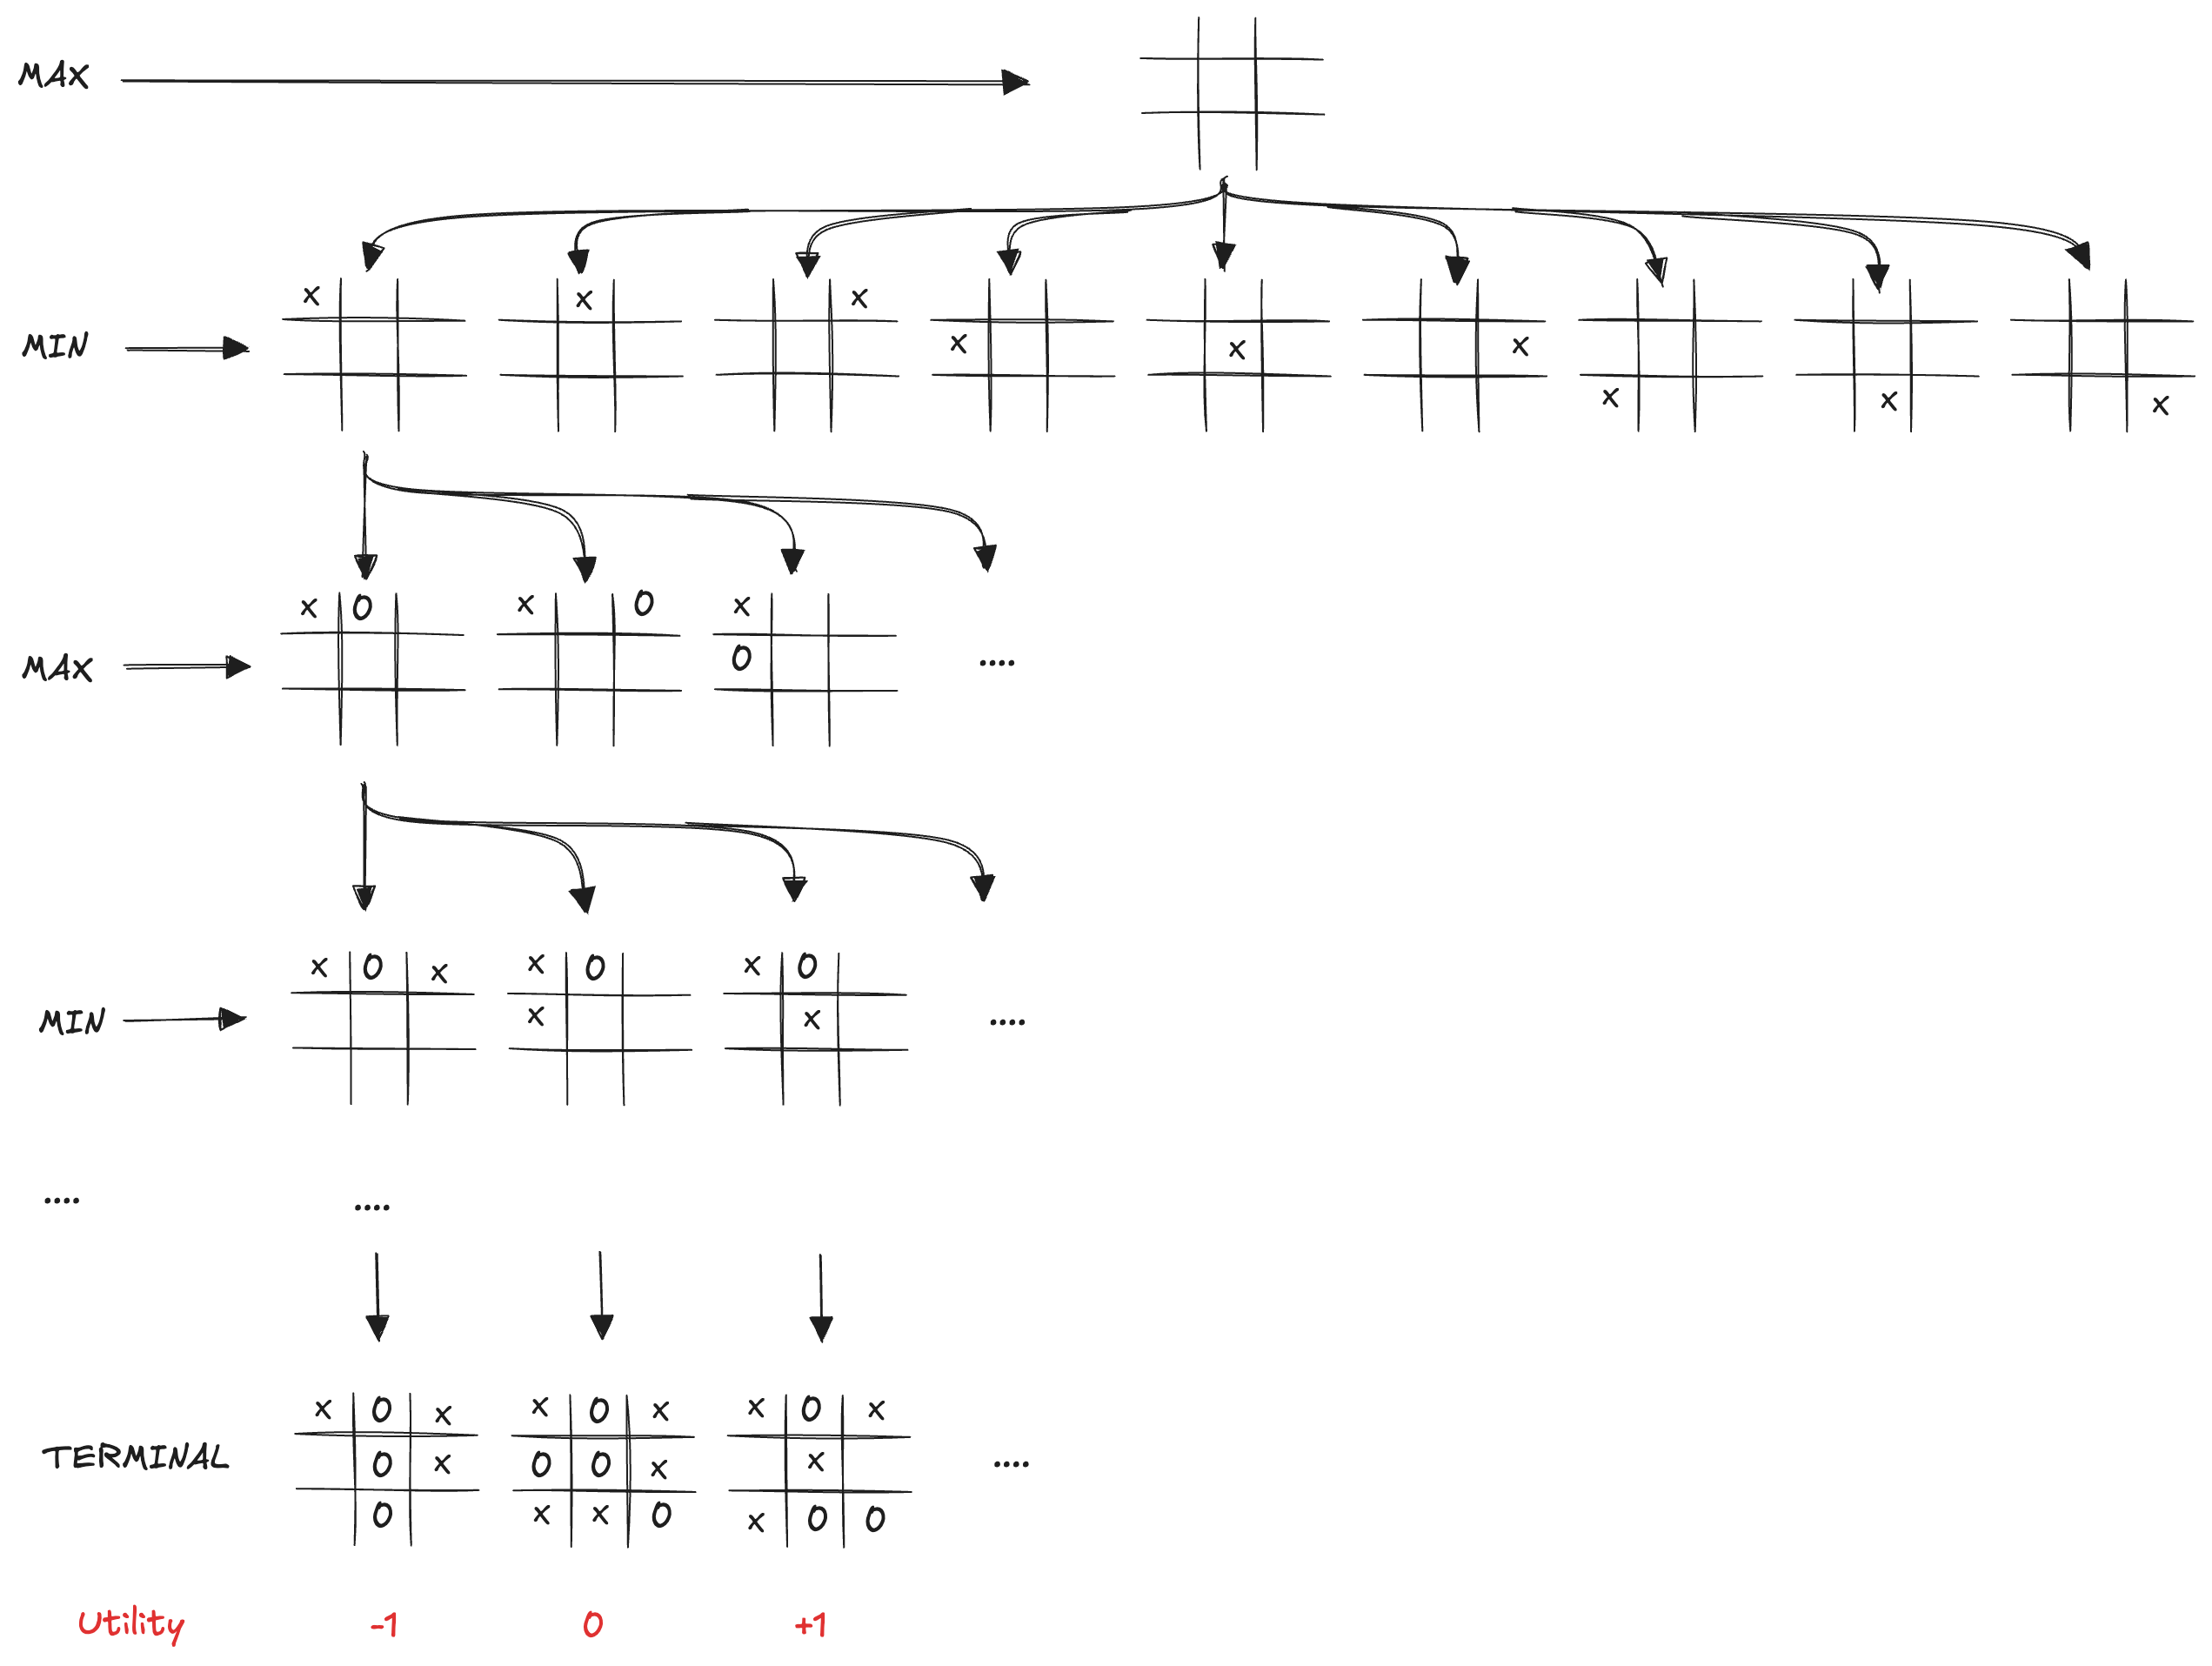

From the initial state, MAX has nine possible moves. Players alternate turns, with MAX placing X and MIN placing O, until reaching a terminal state where a player wins or the board is full. Each terminal state's utility value reflects MAX perspective (higher values favor MAX, lower ones favor MIN). We can implement a function to create an entire graph for a  game:


In [9]:
def create_state_space_graph(game):
    graph = {}
    initial_state = game.initial
    queue = [initial_state]
    visited = {initial_state}

    while queue:
        current_state = queue.pop(0)
        graph[current_state] = {}

        if game.terminal_test(current_state):
            continue

        for action in game.actions(current_state):
            next_state = game.result(current_state, action)
            graph[current_state][action] = next_state

            if next_state not in visited:
                visited.add(next_state)
                queue.append(next_state)

    return graph

We can create the graph for Tic-Tac-Toe in order to count the number of states:

In [10]:
state_space = create_state_space_graph(tictactoe)
print(f"Number of states: {len(state_space)}")

Number of states: 5478


Tic-tac-toe is small, with only 5.478 distinct states and the game tree can be fully explored with 9!=362.880 terminal nodes. In contrast, chess has over 10^40 nodes, making the possibility to create a game tree **purely theoretical** and **impossible to fully compute**. 

## Expert Approach

To address the problem, one initial approach is to **leverage expert knowledge**. We manually define a set of strategic rules that guide the agent's decisions. In the case of Tic-Tac-Toe, we can act as the experts since the game is simple enough:

1. Win if possible: if there is a move that results in an immediate victory, take it.  
2. Block the opponent from winning*: if the opponent has a move that would lead to victory on their next turn, counter it by placing a piece in that position.  
3. Choose the best available position based on priority:
   3.a place a piece in the center if it is available. The center is the strongest position because it provides the most opportunities to form a winning line.  
   3.b Choose a corner adjacent to one of our existing pieces. Corners offer multiple pathways to victory and are strategically valuable.  
   3.c If neither of the above is available, pick a side position as a last resort.  

We can implement the agent in Python:

In [316]:
import random

def expert_player(game, state):

    opponent = 'O' if state.to_move == 'X' else 'X'
    
    # Check for a winning move
    for move in state.moves:
        new_state = game.result(state, move)
        if game.utility(new_state, state.to_move) == 1:
            return move
    
    # Check for a blocking move
    for move in state.moves:
        new_state = game.result(state, move)
        if game.utility(new_state, opponent) == 1:
            return move
    
    # Define priority positions
    center = (2, 2)
    corners = [(1, 1), (1, 3), (3, 1), (3, 3)]
    sides = [(1, 2), (2, 1), (2, 3), (3, 2)]
    
    # Choose center if available
    if center in state.moves:
        return center
    
    # Choose a corner adjacent to an existing piece of the player
    player_positions = {pos for pos, mark in state.board if mark == state.to_move}
    random.shuffle(corners)
    for corner in corners:
        if corner in state.moves and any(abs(corner[0] - p[0]) <= 1 and abs(corner[1] - p[1]) <= 1 for p in player_positions):
            return corner
    
    # Choose a side position as a last resort
    random.shuffle(sides)
    for side in sides:
        if side in state.moves:
            return side
    
    # If none of the above strategies are possible, pick a random move
    return random.choice(state.moves)

We can try our expert agent against a random player:

In [317]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, play, expert_player, random_player, num_games=10000)

# Print the results
print(f"Proportion of Wins for MAX Expert player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Expert player: 0.9178
Proportion of Wins for MIN Random player: 0.0553
Proportion of Draws: 0.0269


Using expert knowledge is an **efficient solution**, since the agent can make decisions quickly, without requiring extensive computation. However, our rules are not optimal, as the agent loses to a random player. This is because our knowledge is **incomplete** and the rules we defined are not sufficient. This shows the limitations of the expert approach. First, it requires a **high level of proficiency in the particular problem**. The effectiveness of the solution depends entirely on human expertise, meaning that any gaps in our understanding or strategic errors will directly impact the agent performance. Without deep knowledge of the game, we risk implementing suboptimal or incomplete strategies. Another major limitation is the **lack of generalization**. Since the solution follows predefined rules, it can only handle situations we have explicitly considered, making it **vulnerable to unexpected situations** or **unconventional strategies** from the opponent. Additionally, the expert knowledge approach **lacks flexibility** when applied to different problems. If we want to create an agent for a new problem, we must design a new set of rules from scratch. Even for problems with similar mechanics, the required strategies may differ significantly, making it difficult to reuse or adapt previous work. This limitation becomes even more apparent as problems increase in complexity, where manually defining an effective strategy becomes increasingly impractical, since not all expertise can be easily verbalized or translated into explicit rules. This is known as the **tacit knowledge problem**, where experts intuitively recognize patterns or strategies but struggle to formally describe them. For example, in chess, grandmasters often make strong moves based on intuition rather than explicit reasoning. While they can explain some general principles (e.g., "control the center" or "develop your pieces"), many of their decisions come from experience, subconscious pattern recognition, and years of training. Capturing this kind of expertise in a rule-based approach is difficult because it is not always possible to define why certain moves "feel" right. 

## Optimal decisions

MAX seeks a winning sequence, but MIN actively counters it. Thus, MAX’s strategy must be a **conditional plan**, responding to each of MIN’s moves to guarantee the best outcome **regardless** of MIN actions. In general, there is no sequence of actions that makes a player win independently of the actions of the opponent.

### Minimax

The optimal strategy can be found by computing the **minimax value** of each state, representing the utility **assuming both players play optimally**. Terminal states take their utility as the minimax value. In non-terminal states, MAX chooses the highest-value move, while MIN selects the lowest (which is best for MIN but worst for MAX). Thus, we have:

$\displaystyle \text{minimax}( s) = \begin{cases} \text{utility}( s) & \text{if } \text{is-terminal}( s) \\ \max_{a} \text{minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MAX} \\ \min_{a} \text{minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MIN} \end{cases}$

Consider the following trivial game:

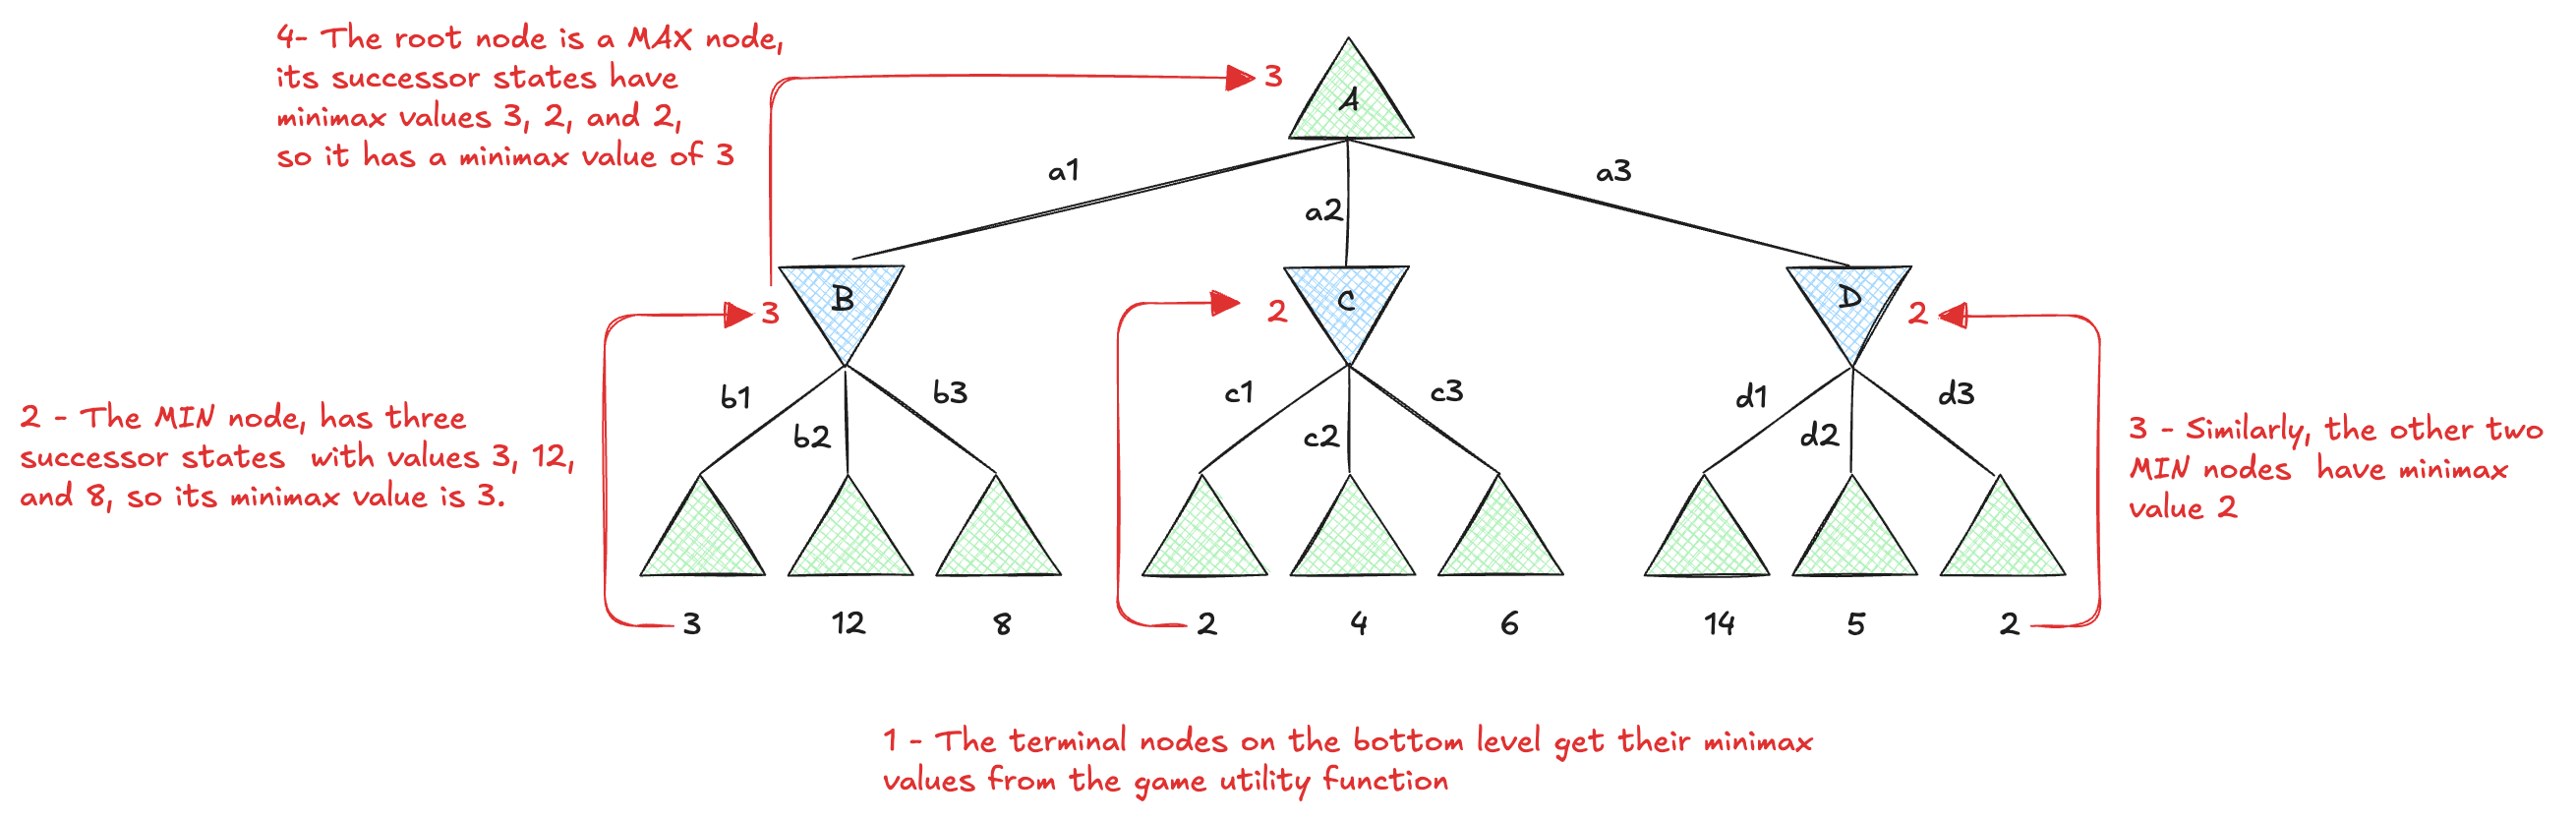

By propagating **minimax values** from terminal states to the root, we determine the **minimax decision**: in this example, MAX should choose a1, as it leads to the highest minimax value. This definition of optimal play for MAX assumes that MIN also plays optimally. If MIN plays suboptimally, MAX will do at least as well, possibly better. However, playing the minimax-optimal move isn’t always best against a weaker opponent. For instance, if perfect play leads to a draw, but a **risky move** gives MIN multiple reasonable responses, most leading to a loss but one to a win, MAX might want to try the risky move, betting on MIN limited ability, on the grounds that a lot of chance of a win is better than a certain draw. First, we can implement a recursive function to compute the minimax value for all states in the tree, starting from a given state (e.g. the initial state):

In [ ]:
import numpy as np

def minimax(game, state, MAX='X', MIN='O'):

    # A dictionary to hold the minimax values of states
    minimax_values = {}

    # Determine which player is to move
    player = game.to_move(state)

    # A function to return the maximum utility value of a state for the maximizing player
    def max_value(state):

        # If state has already been evaluated, return its value
        if state in minimax_values:
            return minimax_values[state]

        # If game is over, return its utility
        if game.terminal_test(state):
            result = game.utility(state, player)
            minimax_values[state] = result
            return result

        # Otherwise, initialize value to negative infinity
        v = -np.inf
        
        # Iterate over all possible actions
        for a in game.actions(state):
            # Compute the best achievable value
            # considering the opponent plays optimally
            v = max(v, min_value(game.result(state, a)))

        # Return the best achievable value
        minimax_values[state] = v
        return v

    # A function to return the minimum utility value of a state for the minimizing player
    def min_value(state):

        # If state has already been evaluated, return its value
        if state in minimax_values:
            return minimax_values[state]

        # If game is over, return its utility
        if game.terminal_test(state):
            result = game.utility(state, player)
            minimax_values[state] = result
            return result

        # Otherwise, initialize value to positive infinity    
        v = np.inf

        # Iterate over all possible actions
        for a in game.actions(state):
            # Compute the best achievable value
            # considering the opponent plays optimally
            v = min(v, max_value(game.result(state, a)))
        
        # Return the best achievable value
        minimax_values[state] = v
        return v
    
    # Start the minimax recursion from the given state
    # taking into account whether the player is maximizing or minimizing
    if player == MAX:
        max_value(state)
    else:
        min_value(state)
    
    # Return the dictionary of minimax values
    return minimax_values

Now that we can compute the minimax, we can turn that into a search algorithm that finds the best move for the player by trying all actions and choosing the one whose resulting state has the highest value:

In [12]:
def minimax_player(game, state, MAX='X', MIN='O'):

    # If the game is over, return None
    if game.terminal_test(state):
        return None

    # The minimax tree, it wis built from the perspective of MAX.
    # So for MAX turn, we need to choose the move that maximizes the value
    # and for MIN turn, we need to choose the move that minimizes that value

    # If the player is MAX, return the action with the highest minimax value
    if state.to_move == MAX:
        # Initialize the best action and value
        best_action = None
        best_value = -float('inf')  

        # Iterate over all possible actions
        for action in game.actions(state):

            # Compute the value of the state resulting from the action
            next_state = game.result(state, action)

            # Get the minimax value of the state
            action_value = minimax_values.get(next_state, -float('inf')) #get value.

            # Update the best action and value
            if action_value > best_value:
                best_value = action_value
                best_action = action

    # If the player is MIN, return the action with the lowest minimax value
    else:
         # Initialize the best action and value
        best_action = None
        best_value = float('inf')  

        # Iterate over all possible actions
        for action in game.actions(state):

            # Compute the value of the state resulting from the action
            next_state = game.result(state, action)

            # Get the minimax value of the state
            action_value = minimax_values.get(next_state, -float('inf')) #get value.

            # Update the best action and value
            if action_value < best_value:
                best_value = action_value
                best_action = action
    
    # Return the best action
    return best_action


Let's test the minimax algorithm in Tic-Tac-Toe against a random player:

In [13]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Build the tree
minimax_values = minimax(tictactoe, tictactoe.initial)  

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, play, minimax_player, random_player, num_games=10000)

# Print the results:
print(f"Proportion of Wins for MAX Minimax player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Minimax player: 0.9951
Proportion of Wins for MIN Random player: 0.0000
Proportion of Draws: 0.0049


The results show that the second player never wins, which is expected since, in Tic-Tac-Toe, a perfectly rational first player can always avoid losing. However, we do observe a certain percentage of draws. These occur when the random player, by chance, makes rational moves and leads the game to a tie. To determine whether this percentage is reasonable, we can formally analyze the probability of the second player randomly selecting the correct moves:

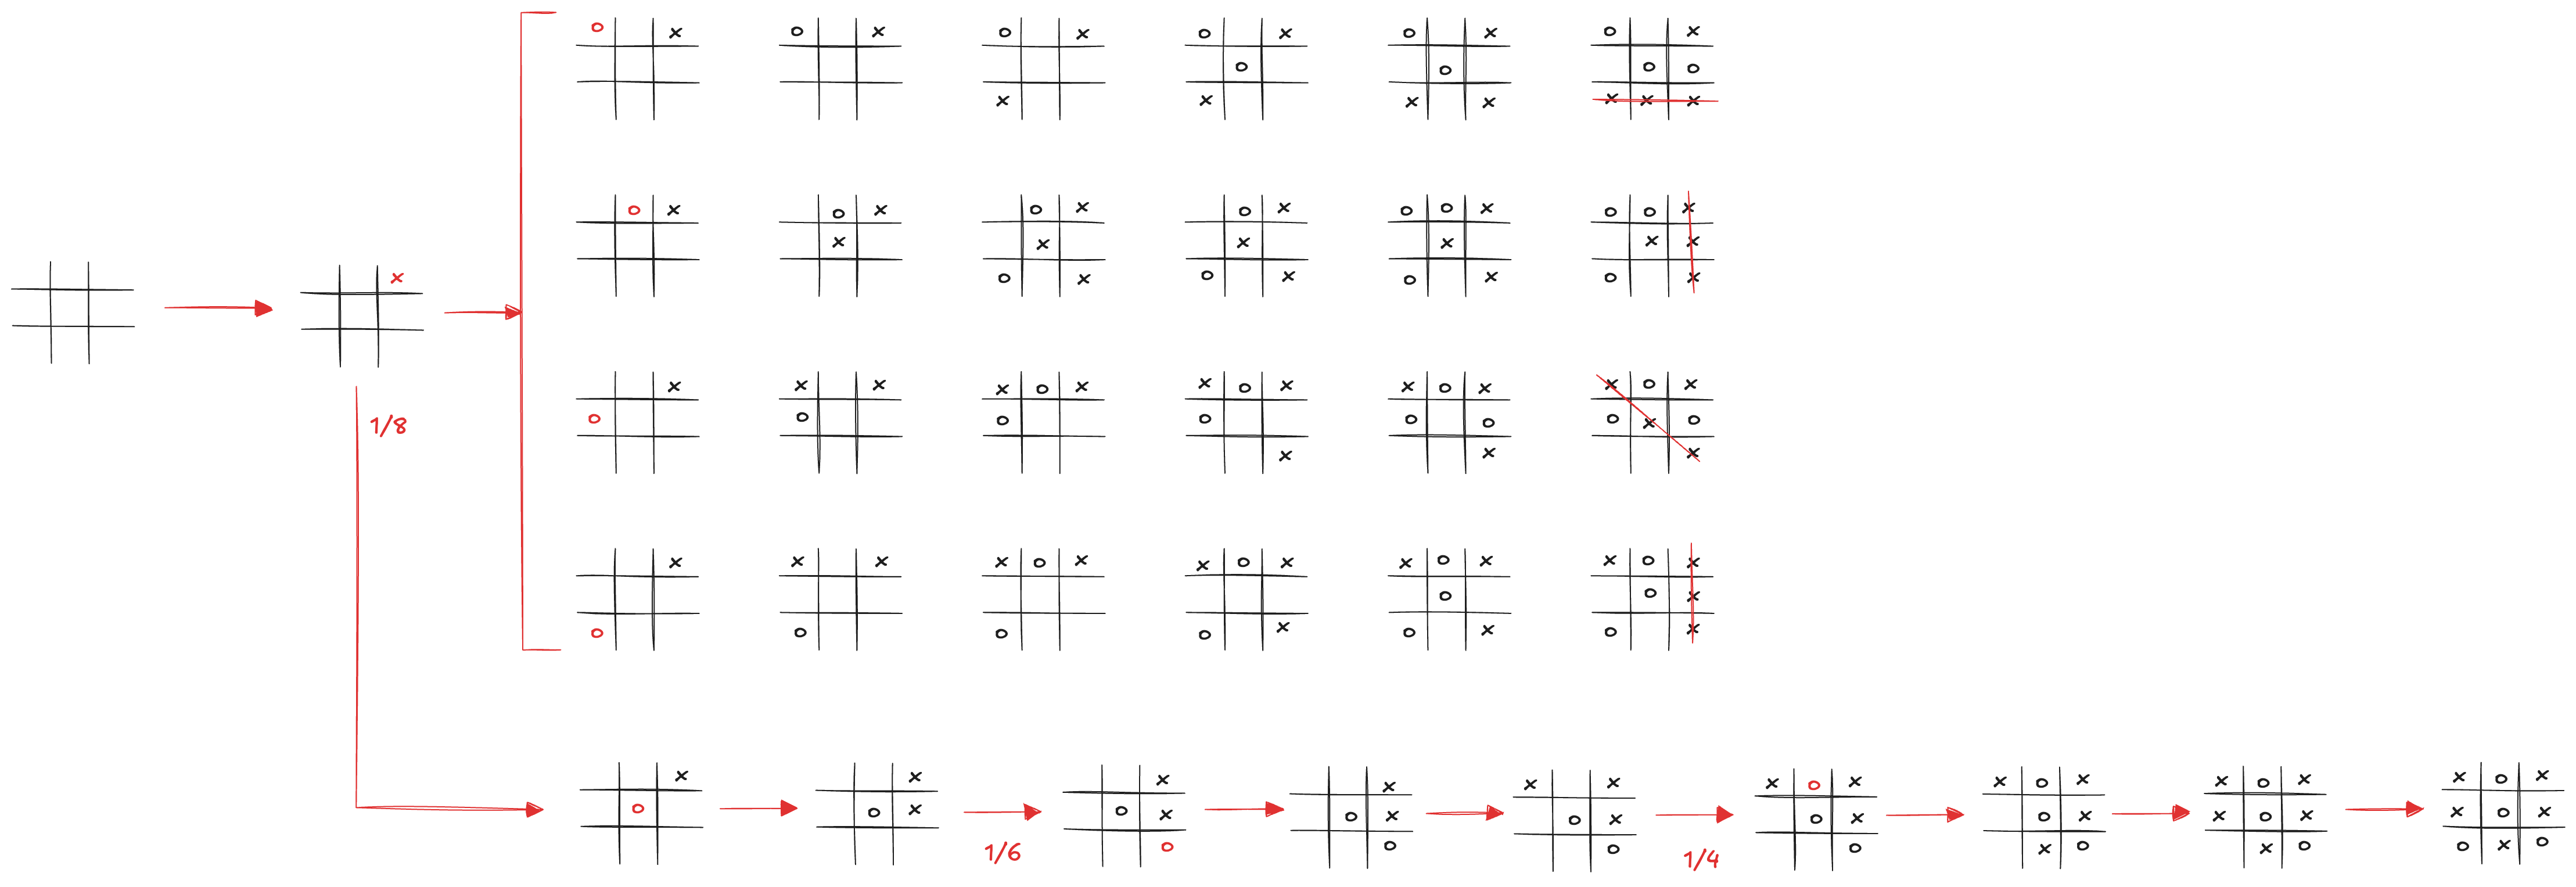

So, the second random player has a probability of drawing of:

$\displaystyle \frac{1}{8} \times \frac{1}{6} \times \frac{1}{4} \approx 0.005$

which is coherent with the observed results from the simulation. We can experiment also the performance of the minimax player when it plays as the second player against a random player:

In [14]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, play, random_player, minimax_player, num_games=10000)

# Print the results:
print(f"Proportion of Wins for MAX Minimax player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Minimax player: 0.0000
Proportion of Wins for MIN Random player: 0.8079
Proportion of Draws: 0.1921


Since the first player has some advantage, the random player has some more chances to draw when it plays first. The minimax algorithm performs a complete depth-first exploration of the game tree. If the maximum depth of the tree is m and there are b legal moves at each point, then the time complexity of the minimax algorithm is:

$\displaystyle O( b^{m})$

and the space complexity is 

$\displaystyle O(bm)$

The exponential complexity makes Minimaz **impractical for complex games**. For example, chess has a branching factor of about 35 and the average game has depth of about 80, and it is not feasible to search 

$\displaystyle 35^{80} \approx 10^{123}$

states. It does, however, serve as **a basis** for the mathematical analysis of games. By approximating the minimax analysis in various ways, we can derive more practical algorithms.

### Alpha–Beta Pruning

The number of game states is exponential in the depth of the tree. No algorithm can completely eliminate the exponent, but we can sometimes cut it in half, computing the correct minimax decision without examining every state by **pruning** large parts of the tree that make no difference to the outcome. Consider again the simple game tree: 

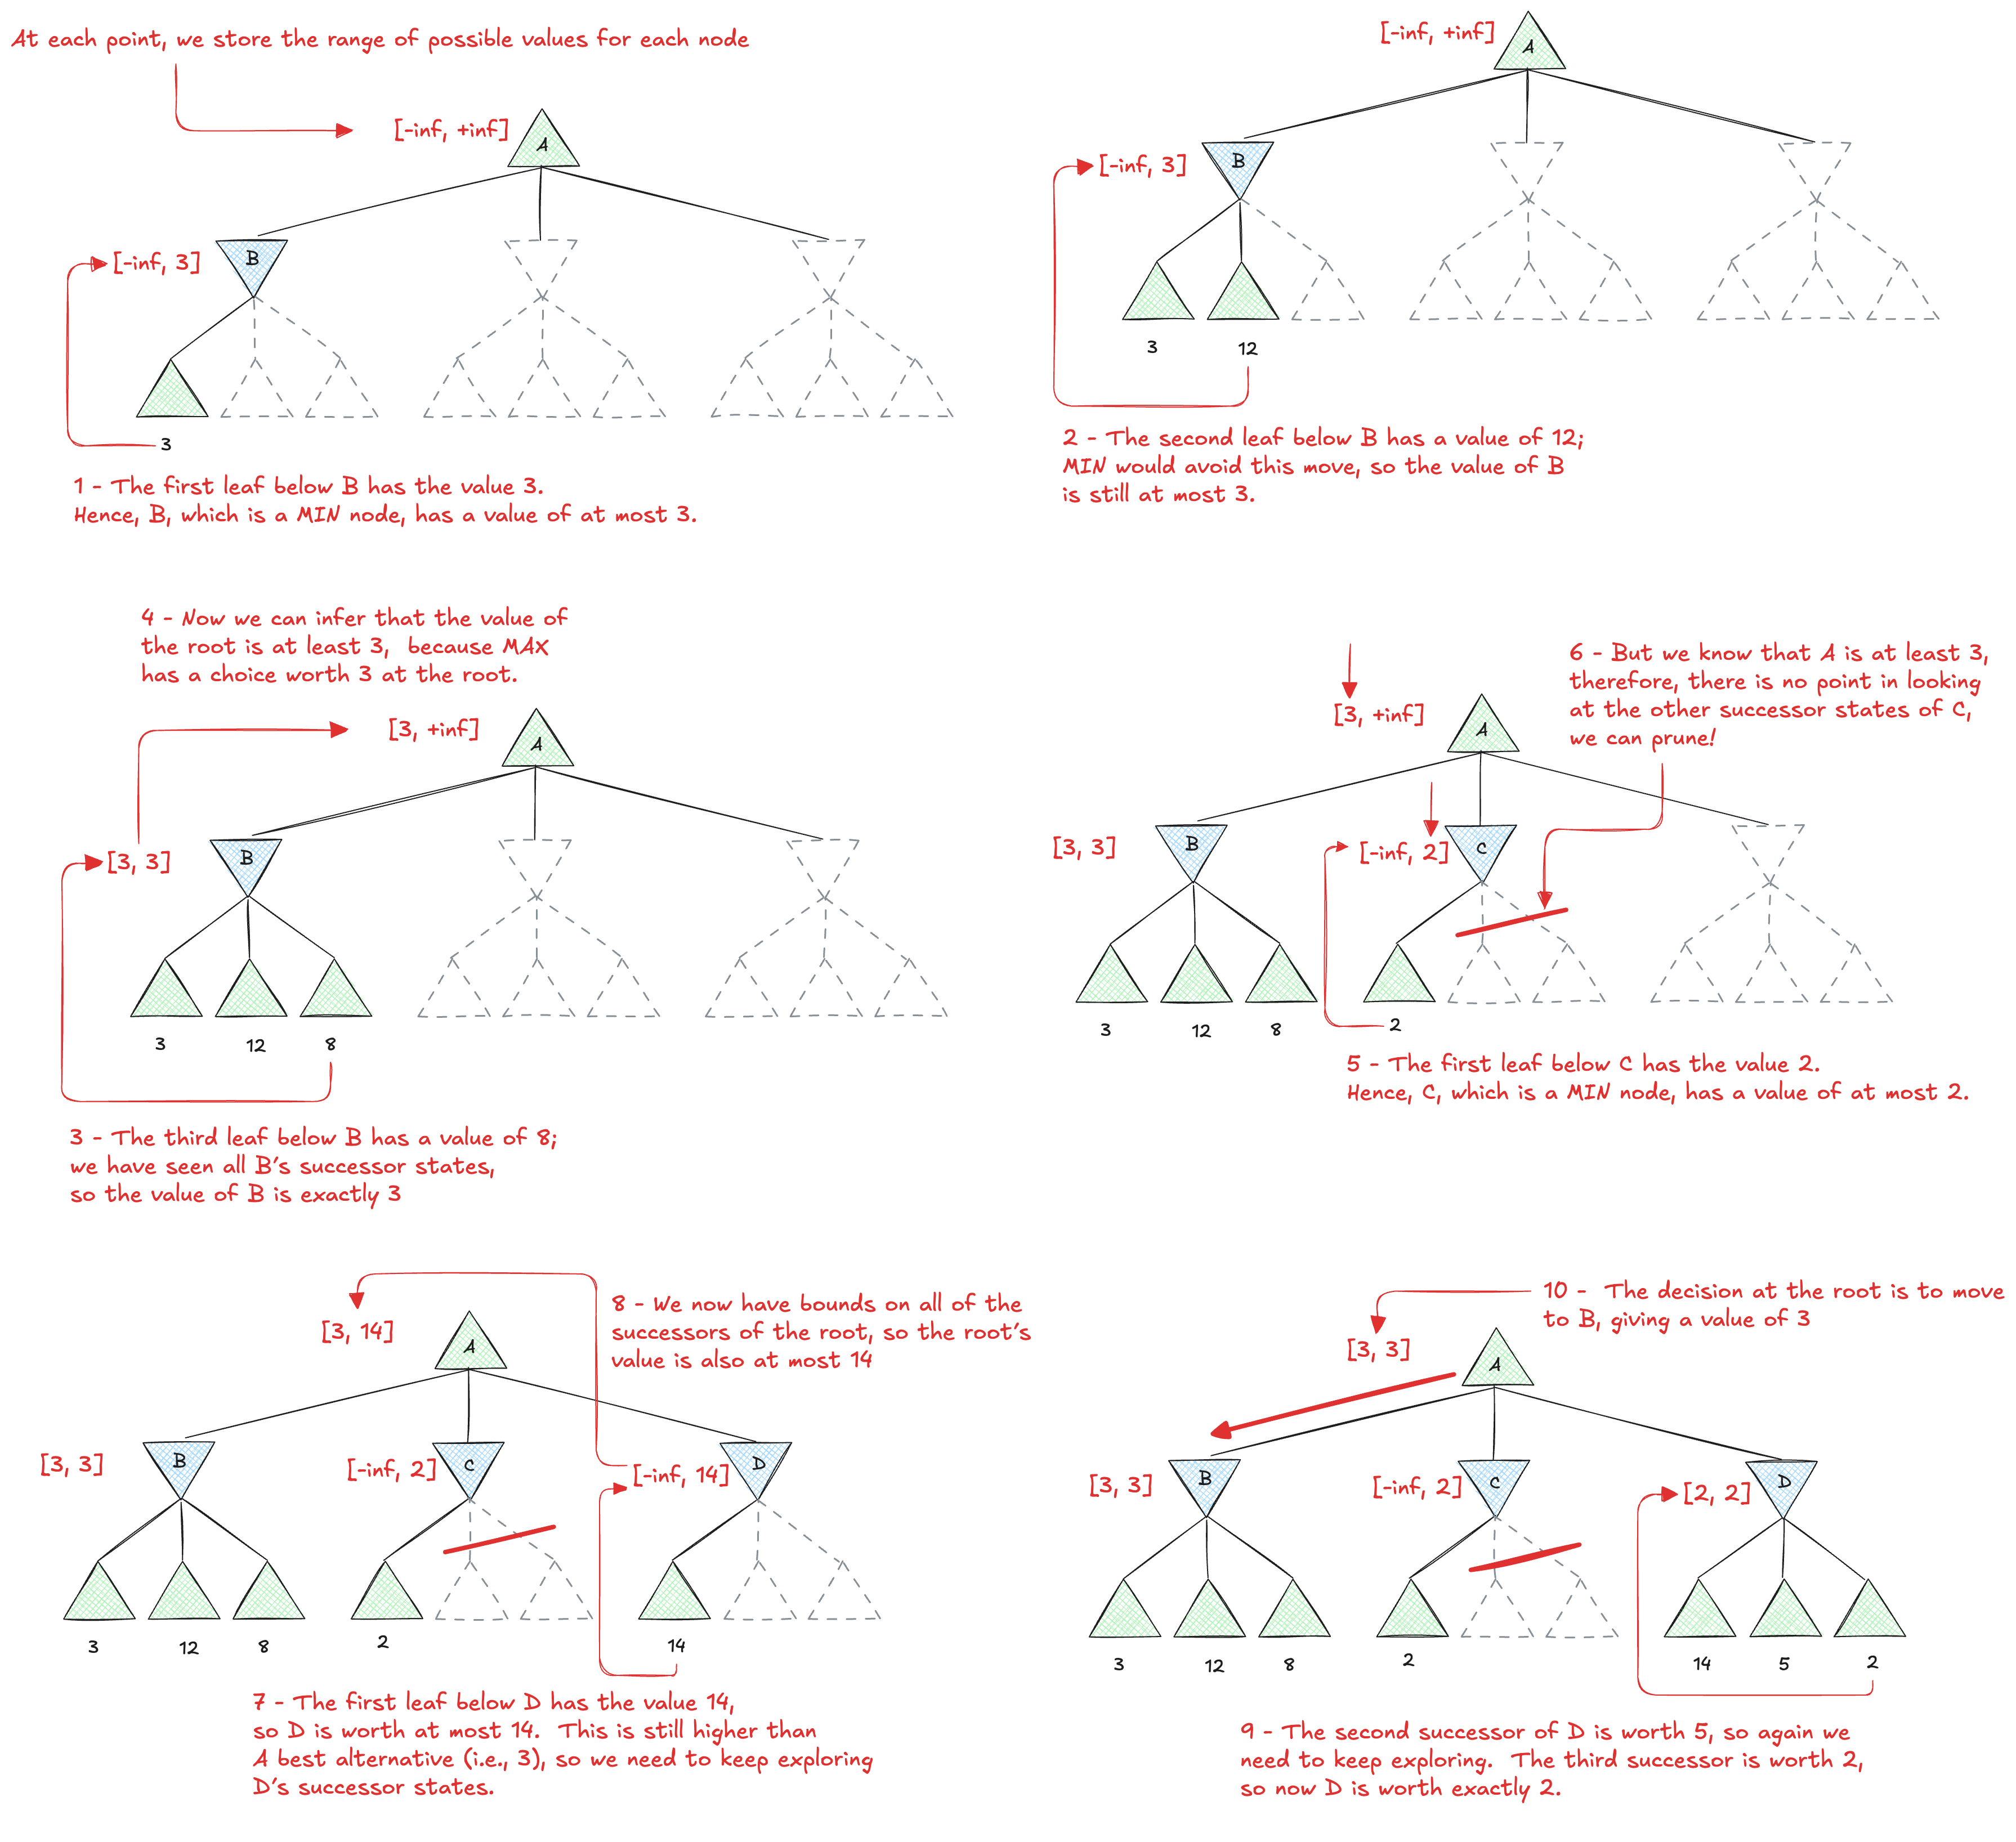

We can express this observation matematicaly:

$\displaystyle \text{Minimax(A)} = \text{max}(\text{min(2, 12, 8)}, \text{min(2, x, y)}, \text{min}(14,5,2)) =$

$\displaystyle = \text{max}(3, \text{min}(2, x, y), 2) = 3$

$\displaystyle = \text{max}(3, < 2, 2) = 3$

In that case, we can identify the minimax decision without ever evaluating some nodes, since the value of A and hence the minimax decision are independent of the values of the leaves x and y of B, and therefore they can be pruned. [**Alpha–beta pruning**](./papers/(1961)%20-%20The%20Alpha-Beta%20Heuristic.pdf) y better move available, he will never choose an inferior option. Once we confirm a branch is irrelevant, we stop exploring it:

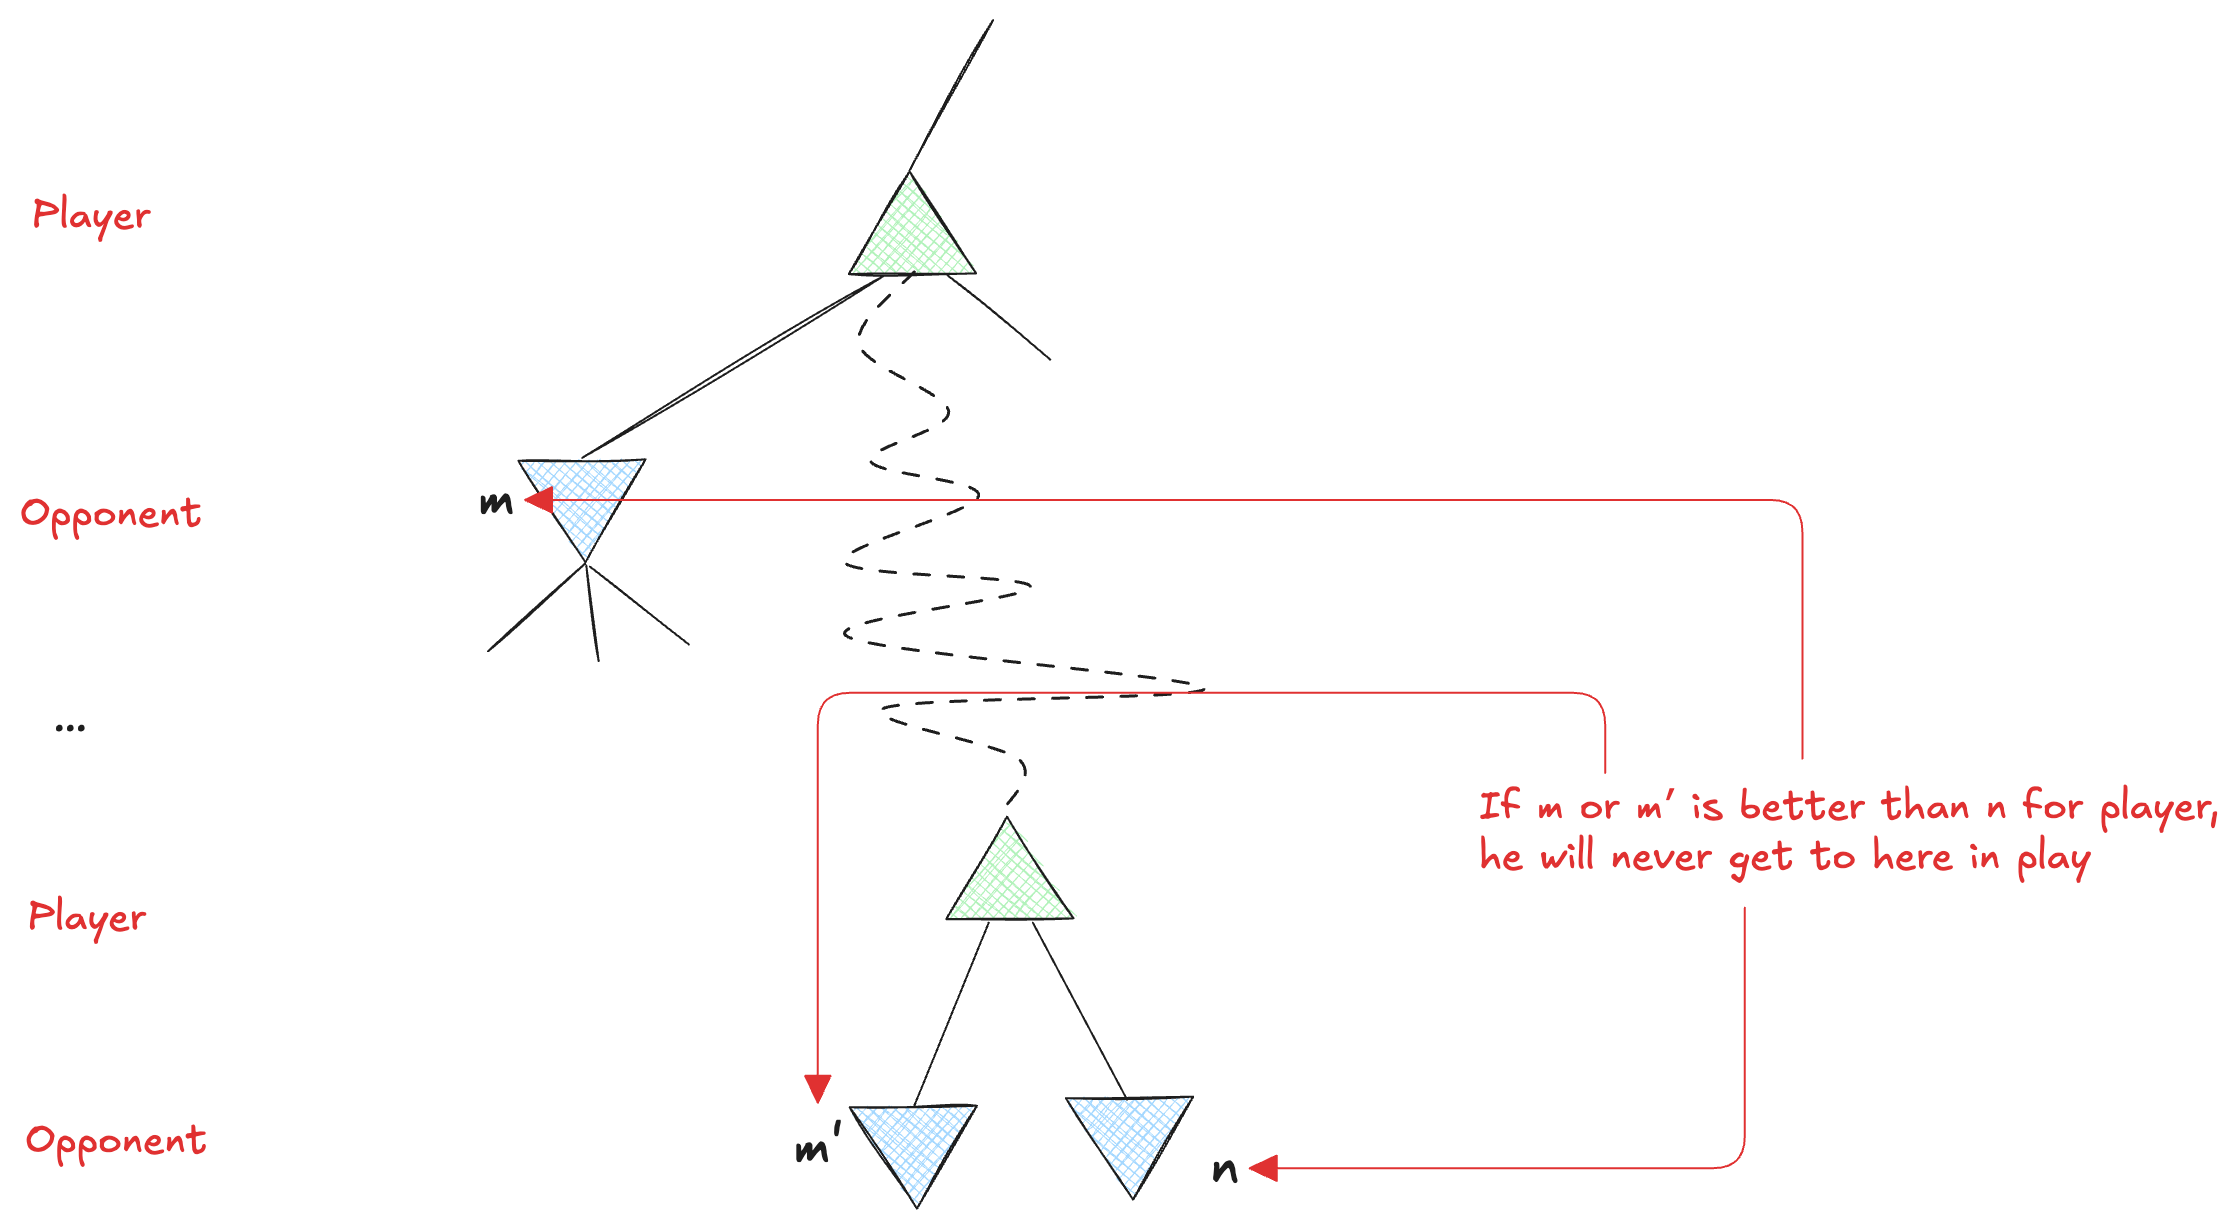

The algorithm maintains two values:

- **alpha** is the value of the best (i.e., highest-value) choice we have found so far at any choice point along the path for MAX
- **beta** is the value of the best (i.e., lowest-value) choice we have found so far at any choice point along the path for MIN

The algorithm updates these values as it goes along and prunes the remaining branches at a node (i.e., terminates the recursive call) as soon as the value of the current node is known to be worse than the current values for MAX or MIN, respectively.

In [15]:
import numpy as np

def pruning_minimax(game, state, MAX='X', MIN='O'):

    # A dictionary to hold the minimax values of states
    minimax_values = {}

     # Determine which player is to move
    player = game.to_move(state)

    # A function to return the maximum utility value of a state for the maximizing player
    def max_value(state, alpha, beta):

        # If state has already been evaluated, return its value
        if state in minimax_values:
            return minimax_values[state]
        
        # If game is over, return its utility
        if game.terminal_test(state):
            result = game.utility(state, player)
            minimax_values[state] = result
            return result

        # Otherwise, initialize value to negative infinity
        v = -np.inf

        # Iterate over all possible actions
        for a in game.actions(state):
            
            # Compute the best achievable value
            # considering the opponent plays optimally
            v = max(v, min_value(game.result(state, a), alpha, beta))
            
            # If v is greater than or equal to beta, 
            # we can prune (return immediately) 
            # because MIN will avoid this branch. 
            if v >= beta:
                minimax_values[state] = v
                return v

            # update alpha    
            alpha = max(alpha, v)
        
        # Return the best achievable value
        minimax_values[state] = v
        return v

    def min_value(state, alpha, beta):

        # If state has already been evaluated, return its value
        if state in minimax_values:
            return minimax_values[state]

        # If game is over, return its utility
        if game.terminal_test(state):
            result = game.utility(state, player)
            minimax_values[state] = result
            return result

        # Otherwise, initialize value to positive infinity 
        v = np.inf

        # Iterate over all possible actions
        for a in game.actions(state):

            # Compute the best achievable value
            # considering the opponent plays optimally
            v = min(v, max_value(game.result(state, a), alpha, beta))

            # If v is less than or equal to alpha, 
            # the branch is pruned since MAX would avoid it
            if v <= alpha:
                minimax_values[state] = v
                return v
            
            # update beta
            beta = min(beta, v)

        # Return the best achievable value
        minimax_values[state] = v
        return v

    # Start the recursion with initial alpha and beta values
    if player == MAX:
        max_value(state, -np.inf, np.inf)
    else:
        min_value(state, -np.inf, np.inf)

    return minimax_values

We can compare the number of nodes considered by the minimax and alpha-beta pruning algorithms:

In [16]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Build the tre
minimax_values = minimax(tictactoe, tictactoe.initial)  

# Build the tree using alpha-beta pruning
pruned_minimax_values = pruning_minimax(tictactoe, tictactoe.initial)  

print("Minimax nodes: ", len(minimax_values))
print("Minimax pruned nodes: ", len(pruned_minimax_values))

Minimax nodes:  5478
Minimax pruned nodes:  2592


The effectiveness of alpha–beta pruning is highly dependent on the order in which the states are examined. In the simple example, we could not prune any successors of D at all because the worst successors were generated first. If the third successor of D had been generated first (with value 2), we would have been able to prune the other two successors. This suggests that it might be worthwhile to try to first examine the successors that are likely to be best.
If this could be done perfectly, alpha–beta would need to examine only: 

$\displaystyle O\left(b^{m/2}\right)$

nodes to pick the best move. This mean that we can solve a tree roughly twice as deep as minimax in the same amount of time. With random move ordering, the total number of nodes examined will be roughly:

$\displaystyle O\left(b^{3m/4}\right)$

We cannot achieve perfect ordering, otherwise the ordering function could be used to play a perfect game. However, with several heurstics we can often get fairly close. As a general principle, the **most promising** plays should be expanded first.

## Heuristic-based decisions


In realistic games, we cannot search to leaves since the computation time is limited. In order to overcome this limitation, we can stop the search early and use an [**heuristic evaluation function**](./papers/(1950)%20-%20Programming%20a%20Computer%20for%20Playing%20Chess.pdf) to **estimate state utility**, treating non-terminal nodes as terminal. This means replacing the utility() function with a new eval() function and the terminal test with a **cutoff test**, which stops the search at terminal states or based on depth and other conditions. This approach defines the **heuristic minimax value** as follows:

$\displaystyle \text{heuristic-minimax}( s) = \begin{cases} \text{eval}( s) & \text{if } \text{cutoff-test}( s) \\ \max_{a} \text{heuristic-minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MAX} \\ \min_{a} \text{heuristic-minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MIN} \end{cases}$



### Evaluation function

An heuristic evaluation function **estimates a state expected utility**. For terminal states, it matches utility(), while for non-terminal states, it should produce values within the range from loss to win, in order to ensures consistency with the actual outcome and avoids unrealistic evaluations:

$\displaystyle \text{utility}(\text{loss}, p) \leq \text{eval}(s, p) \leq \text{utility}(\text{win}, p)$

A good evaluation function should be **fast to compute** (since the goal is faster search) and **strongly correlated with actual winning chances**. While games like chess have deterministic outcomes with perfect play, cutting off the search at non-terminal states **introduces uncertainty**. An evaluation function can be built by extracting **features**, quantifiable aspects of a state (e.g., in chess, the number of pawns, knights, queens, or strategic factors like pawn structure and king safety). Each feature contributes a weighted value, and their sum determines the final evaluation. The weights should be normalized so that the sum is always within the range. This approach, used by chess players for centuries, forms a [**weighted linear function**](./papers/(1950)%20-%20Statistics%20for%20the%20chess%20computer%20and%20the%20factor%20of%20mobility.pdf):

$\displaystyle \text{eval}( s) = w_{1} f_{1}( s) + w_{2} f_{2}( s) + \ldots + w_{n} f_{n}( s) = \sum_{i=1}^{n} w_{i} f_{i}( s)$

where the $f_i$ are the features and $w_i$ are the weights (saying how important a feature is). Adding up the values of features seems like a reasonable thing to do, but in fact it involves **a strong assumption**: that the contribution of each feature is independent of the values of the other features. Today, current programs also use **nonlinear combinations of features**. In Tic-Tac-Toe, a simple yet effective approach is to count the number of open (still winnable) rows, columns, and diagonals for both players and compute the difference:

$\displaystyle \text{eval}( s) = \text{count-open-rows}( s, \text{MAX}) - \text{count-open-rows}( s, \text{MIN})$

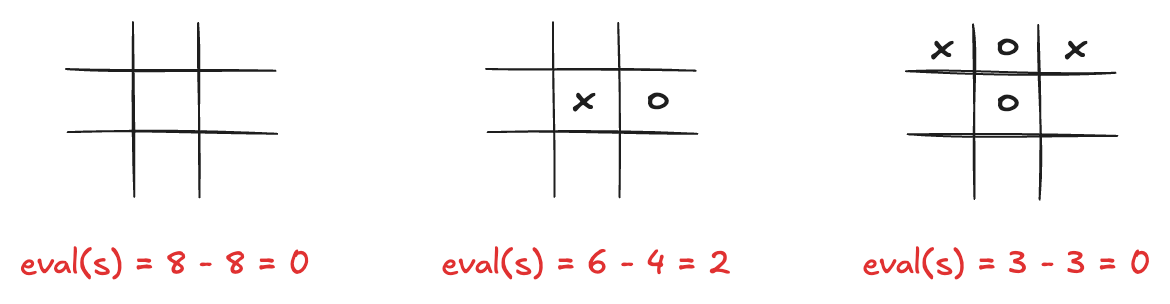


In [17]:
def eval_tictactoe(board, MAX='X', MIN='O'):

    # Convert the state's board (tuple of (position, value) pairs) 
    # into a dictionary
    board_dict = dict(board)

    # Build a 3x3 numpy array from the dictionary. 
    # Default to '.' if a cell is not present.
    board = np.array([[board_dict.get((i, j), '.') for j in range(3)] for i in range(3)])
    
    def count_open_lines(board, player):

        count = 0
        
        # Check rows
        for row in board:
            if np.all((row == player) | (row == '.')):
                count += 1
        
        # Check columns
        for col in board.T:
            if np.all((col == player) | (col == '.')):
                count += 1
        
        # Check diagonals
        diag1 = np.array([board[i, i] for i in range(3)])
        diag2 = np.array([board[i, 2 - i] for i in range(3)])
        if np.all((diag1 == player) | (diag1 == '.')):
            count += 1
        if np.all((diag2 == player) | (diag2 == '.')):
            count += 1
        
        return count

    return count_open_lines(board, MAX) - count_open_lines(board, MIN)

In [18]:
board_1 = {
    (0, 0): '.', (0, 1): '.', (0, 2): '.',
    (1, 0): '.', (1, 1): '.', (1, 2): '.',
    (2, 0): '.', (2, 1): '.', (2, 2): '.'
}

board_2 = {
    (0, 0): '.', (0, 1): '.', (0, 2): '.',
    (1, 0): '.', (1, 1): 'X', (1, 2): 'O',
    (2, 0): '.', (2, 1): '.', (2, 2): '.'
}

board_3 = {
    (0, 0): 'X', (0, 1): 'O', (0, 2): 'X',
    (1, 0): '.', (1, 1): 'O', (1, 2): '.',
    (2, 0): '.', (2, 1): '.', (2, 2): '.'
}

print(f"Evaluation score board 1: ", eval_tictactoe(board_1))
print(f"Evaluation score board 2: ", eval_tictactoe(board_2))
print(f"Evaluation score board 3: ", eval_tictactoe(board_3))

Evaluation score board 1:  0
Evaluation score board 2:  2
Evaluation score board 3:  0


Features and weights are derived from **domain knowledge**, not the game’s rules. In games lacking expert insight, machine learning can estimate evaluation weights. Applied to chess, this approach has validated traditional heuristics, showing that centuries of human expertise can be replicated in hours.

### Cutting off search

The evaluation function is **inherently imperfect**. However, as we go deeper into the tree, the importance of its precision diminishes, as we approach states closer to terminal states, where evaluating the situation becomes easier even with simple heuristics. This creates a tradeoff between the complexity of the heuristic and the depth at which to apply it. To address this, Minimax should be modified to call the heuristic function when it's appropriate to cut off the search. A simple approach to controlling the search depth is to set a **fixed depth limit**. Here's an example from Tic-Tac-Toe with a depth limit of 2:

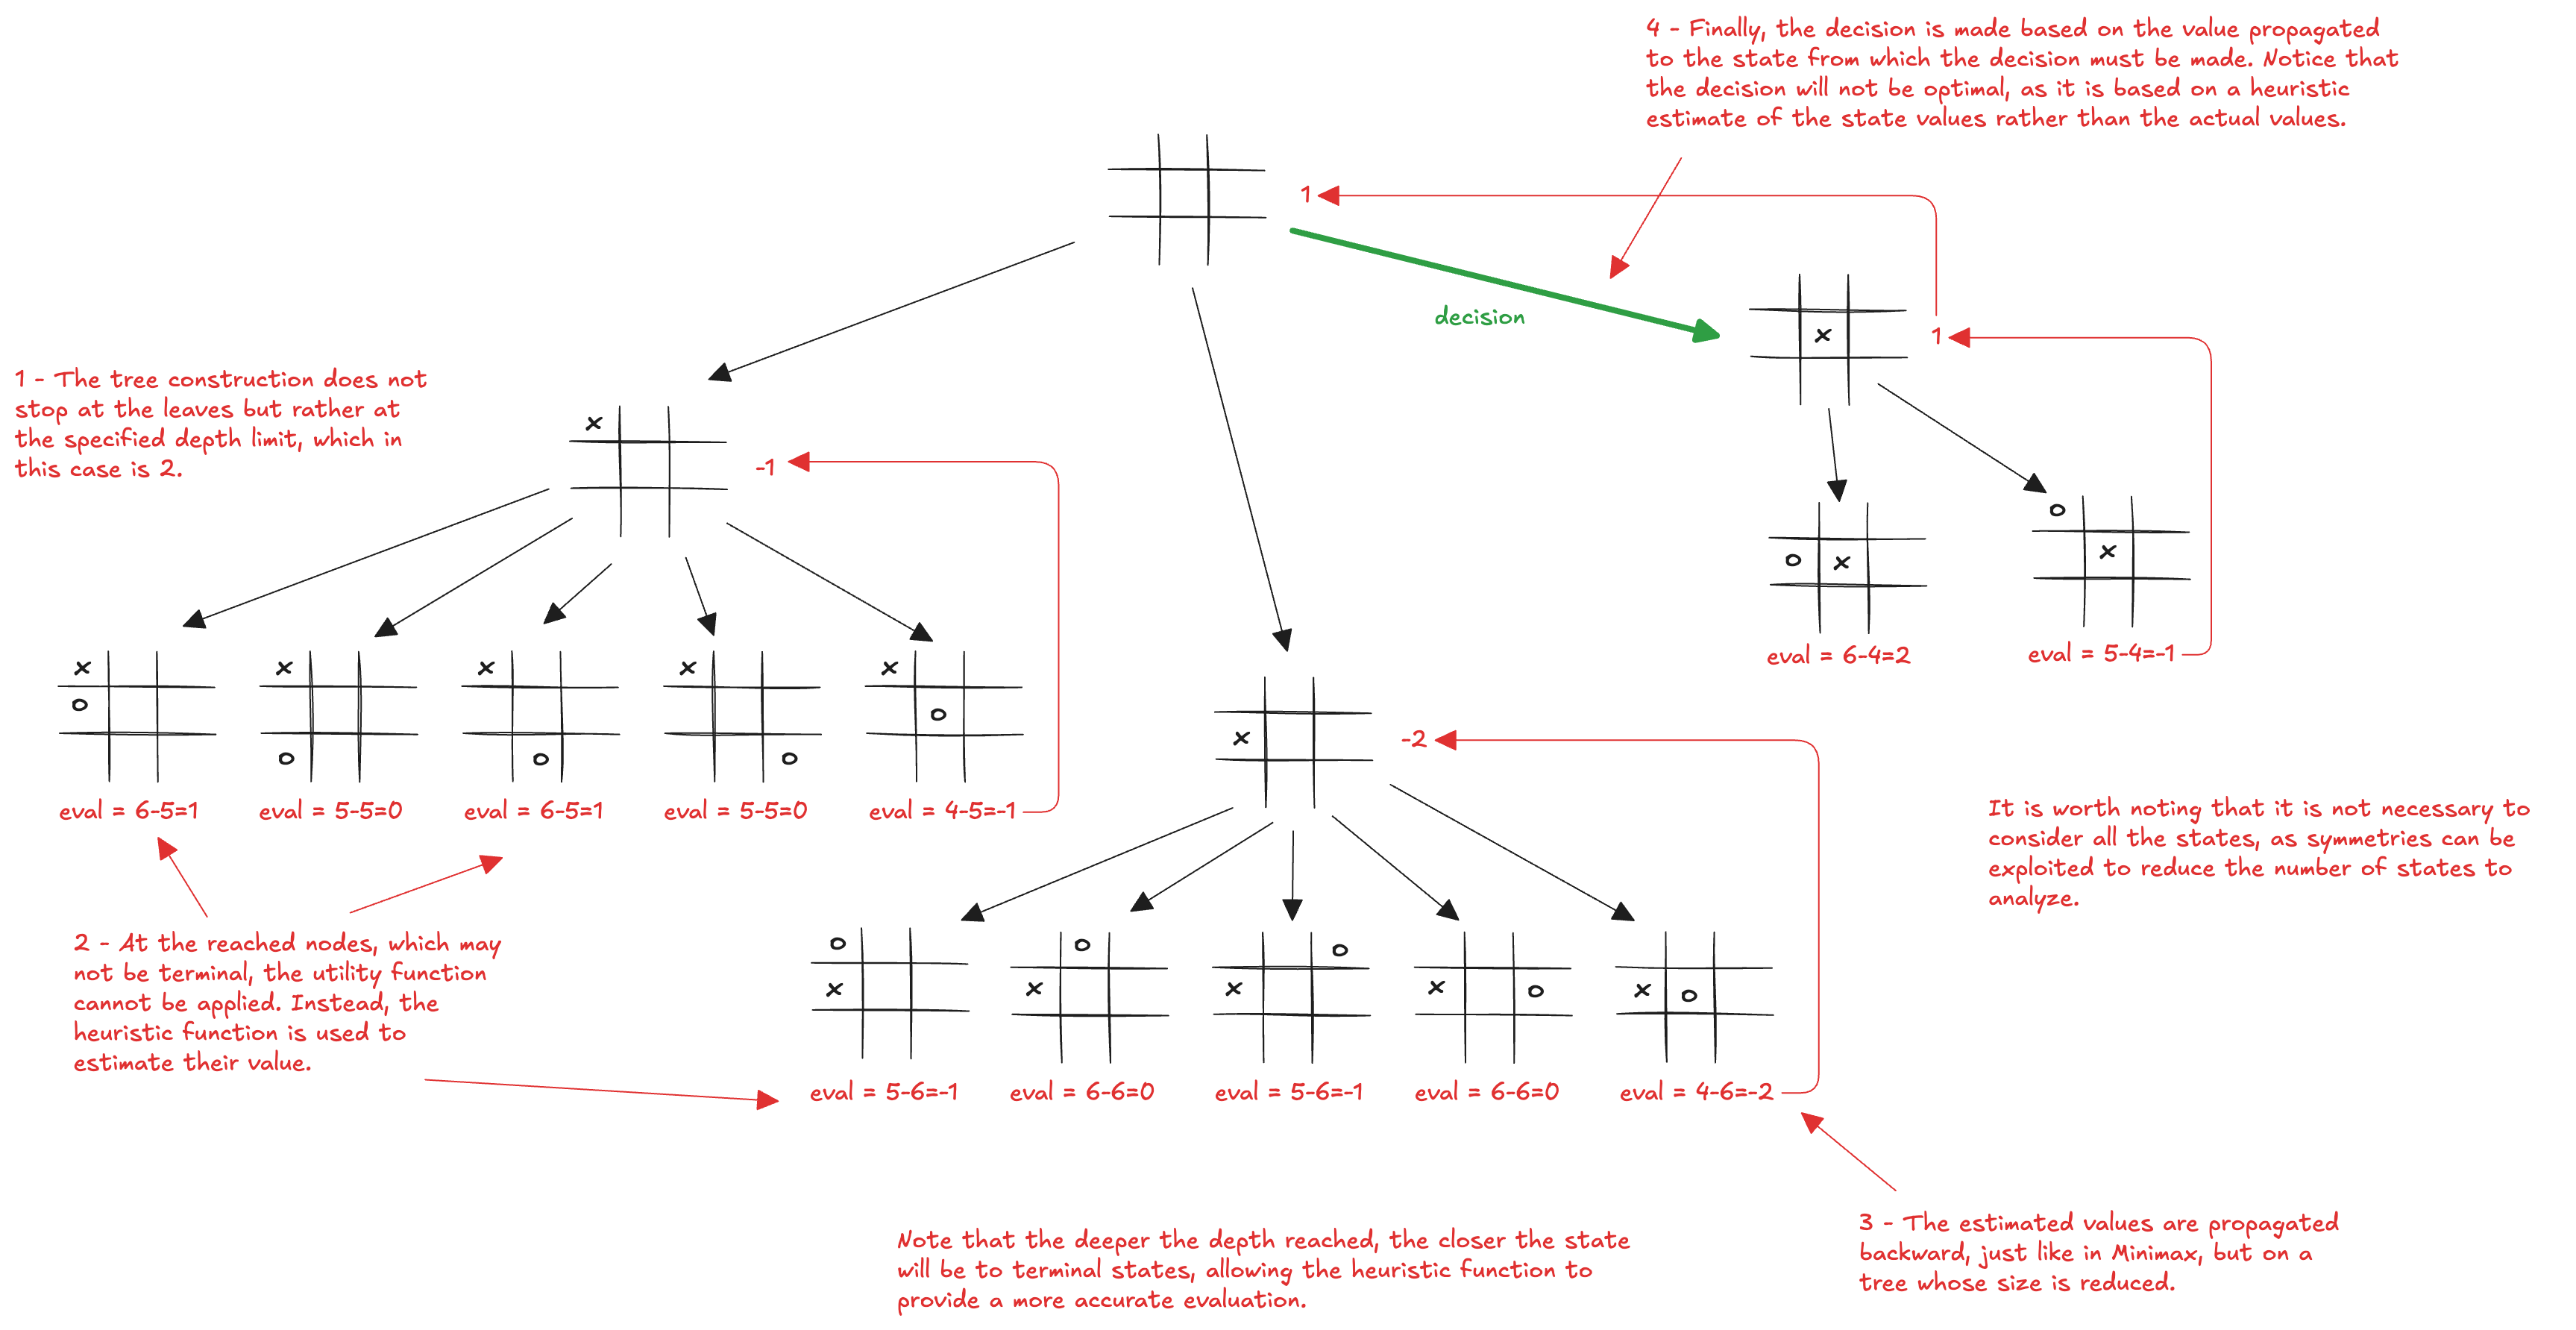

In [ ]:
def cutoff_player(game, state, eval=eval_tictactoe, max_depth=2, MAX='X', MIN='O'):

    player = state.to_move

    def max_value(state, depth):
        if game.terminal_test(state):
            return game.utility(state, game.to_move(game.initial)) 

        # If the maximum depth is reached, 
        # return the heuristic evaluation of the state
        if depth == 0:
            return eval(state.board)

        v = -float('inf')
        for action in game.actions(state):
            v = max(v, min_value(game.result(state, action), depth - 1))
        return v

    def min_value(state, depth):
        if game.terminal_test(state):
            return game.utility(state, game.to_move(game.initial))
        
        # If the maximum depth is reached, 
        # return the heuristic evaluation of the state
        if depth == 0: 
            return eval(state.board)

        v = float('inf')
        for action in game.actions(state):
            v = min(v, max_value(game.result(state, action), depth - 1))
        return v

    best_action = None
    if player == MAX:
        best_value = -float('inf')
        for action in game.actions(state):
            value = min_value(game.result(state, action), max_depth - 1)
            if value > best_value:
                best_value = value
                best_action = action
    else:
        best_value = float('inf')
        for action in game.actions(state):
            value = max_value(game.result(state, action), max_depth - 1)
            if value < best_value:
                best_value = value
                best_action = action

    return best_action

We can run the experiment with the heuristic minimax algorithm and a depth limit of 2:

In [20]:
# Create a new TicTacToe game
tictactoe = TicTacToe(h=3, v=3, k=3)

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, play, cutoff_player, random_player, num_games=100)

# Print the results:
print(f"Proportion of Wins for MAX Minimax player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Minimax player: 0.8000
Proportion of Wins for MIN Random player: 0.0400
Proportion of Draws: 0.1600


We can see that the obtained player is not optimal (sometimes it loses), but it is much faster than the optimal one since it should not explore the entire game tree. The depth limit is a **trade-off** between **speed** and **accuracy**. A more robust approach is to returns the move selected by the deepest completed search **when time runs out**. 

These simple approaches can **lead to errors due to the approximate nature of the evaluation function**. For example, a chess evaluation function based on material advantage might misjudge a position if it ignores imminent threats. Suppose the search stops at a depth limit where Black leads by a knight and two pawns, it may evaluate the position as winning for Black. However, if White's next move captures Black’s queen, the true advantage shifts dramatically. To avoid such errors, evaluation should apply only to **quiescent** positions—those without immediate, drastic changes like major captures. For **non-quiescent** positions, the search should continue until stability is reached. This **quiescence search** often focuses on specific moves, such as captures, to resolve uncertainties efficiently.

## Stochastic Games

Stochastic games introduce an element of **randomness**, like dice rolls, making them more reflective of **real-life unpredictability**. We need to includes uncertain events which influence the moves of players at each state. We can subclass the Game class adding chances and outcome methods:

In [21]:
class StochasticGame(Game):
    def chances(self, state):
        # Return a list of all possible uncertain events at a state
        raise NotImplementedError

    def outcome(self, state, chance):
        # Return the state which is the outcome of a chance trial
        raise NotImplementedError

    def probability(self, chance):
        # Return the probability of occurrence of a chance
        raise NotImplementedError

The function that manages player interactions during a game must be modified to account for random events:

In [22]:
def play_stochastic(game, *players, verbose=False):
    state = game.initial
    while True:
        for player in players:
            
            # Retrieve all possible chance events for the current
            chance_events = game.chances(state)

            if chance_events:
                # Calculate the weights (probabilities) for each chance event
                weights = [game.probability(chance_event) for chance_event in chance_events]
                
                # Select a chance event based on its probability.
                selected_chance_event = random.choices(chance_events, weights=weights, k=1)[0]
                    
                # Update the state based on the outcome of the chance event
                state = game.outcome(state, selected_chance_event)
                
            # Get the action chosen by the current player
            action = player(game, state)

            # If no move is possible, skip turn
            if action is None:  
                continue  

            # Apply the move and update the game state
            state = game.result(state, action)

            # Optionally display the updated game state
            if verbose:
                game.display(state)

            # If the game is over, return the final utility value
            if game.terminal_test(state):
                return game.utility(state, game.to_move(game.initial))

We need to modify the game state to indicate whether chance plays a role:

In [23]:
StochasticGameState = namedtuple('StochasticGameState', 'to_move, utility, board, moves, chance')

### Backgammon

Backgammon is a classic example, blending both luck and skill. Each player starts with 15 checkers, and the board is divided into 24 narrow triangles known as points. The points are grouped into four quadrants, with each player’s home board in the lower right and upper right, and the outer board in the upper left and lower left. For White the home board is composed of points 1 to 6, while for Black it is composed of points 19 to 24. The objective of the game is to move all checkers around the board and ultimately off it, a process called bearing off, before the opponent does. The game begins with each player’s checkers arranged in a specific starting configuration, and players move their checkers in opposite directions around the board. On his turn, the player rolls two dice to determine how many points he can move his checkers, with each die representing a separate move. He may choose to move one checker twice or two different checkers. When he roll doubles, he is granted four moves using the number shown on the dice. A key concept is hitting and entering. If the player lands on a point that is occupied by a single opposing checker, that checker is hit and placed on the bar (the central area of the board). A player with a checker on the bar must first re-enter it into the opponent’s home board before making any other moves. Once all checkers are in his home board, the player can begin bearing them off. Bearing off involves removing checkers from the board by rolling a number that corresponds exactly to the point on which a checker resides. If the player rolls a number higher than any occupied point, he may remove a checker from the highest occupied point. The game concludes when one player has successfully carried off all of his checkers. The victory can be classified differently depending on the situation: a normal win, a gammon if the opponent has not carried off any checkers, or a backgammon if the opponent’s checkers are still on the bar or in the winner’s home board, with each type of win carrying varying stakes. Let's consider a typical board configuration:

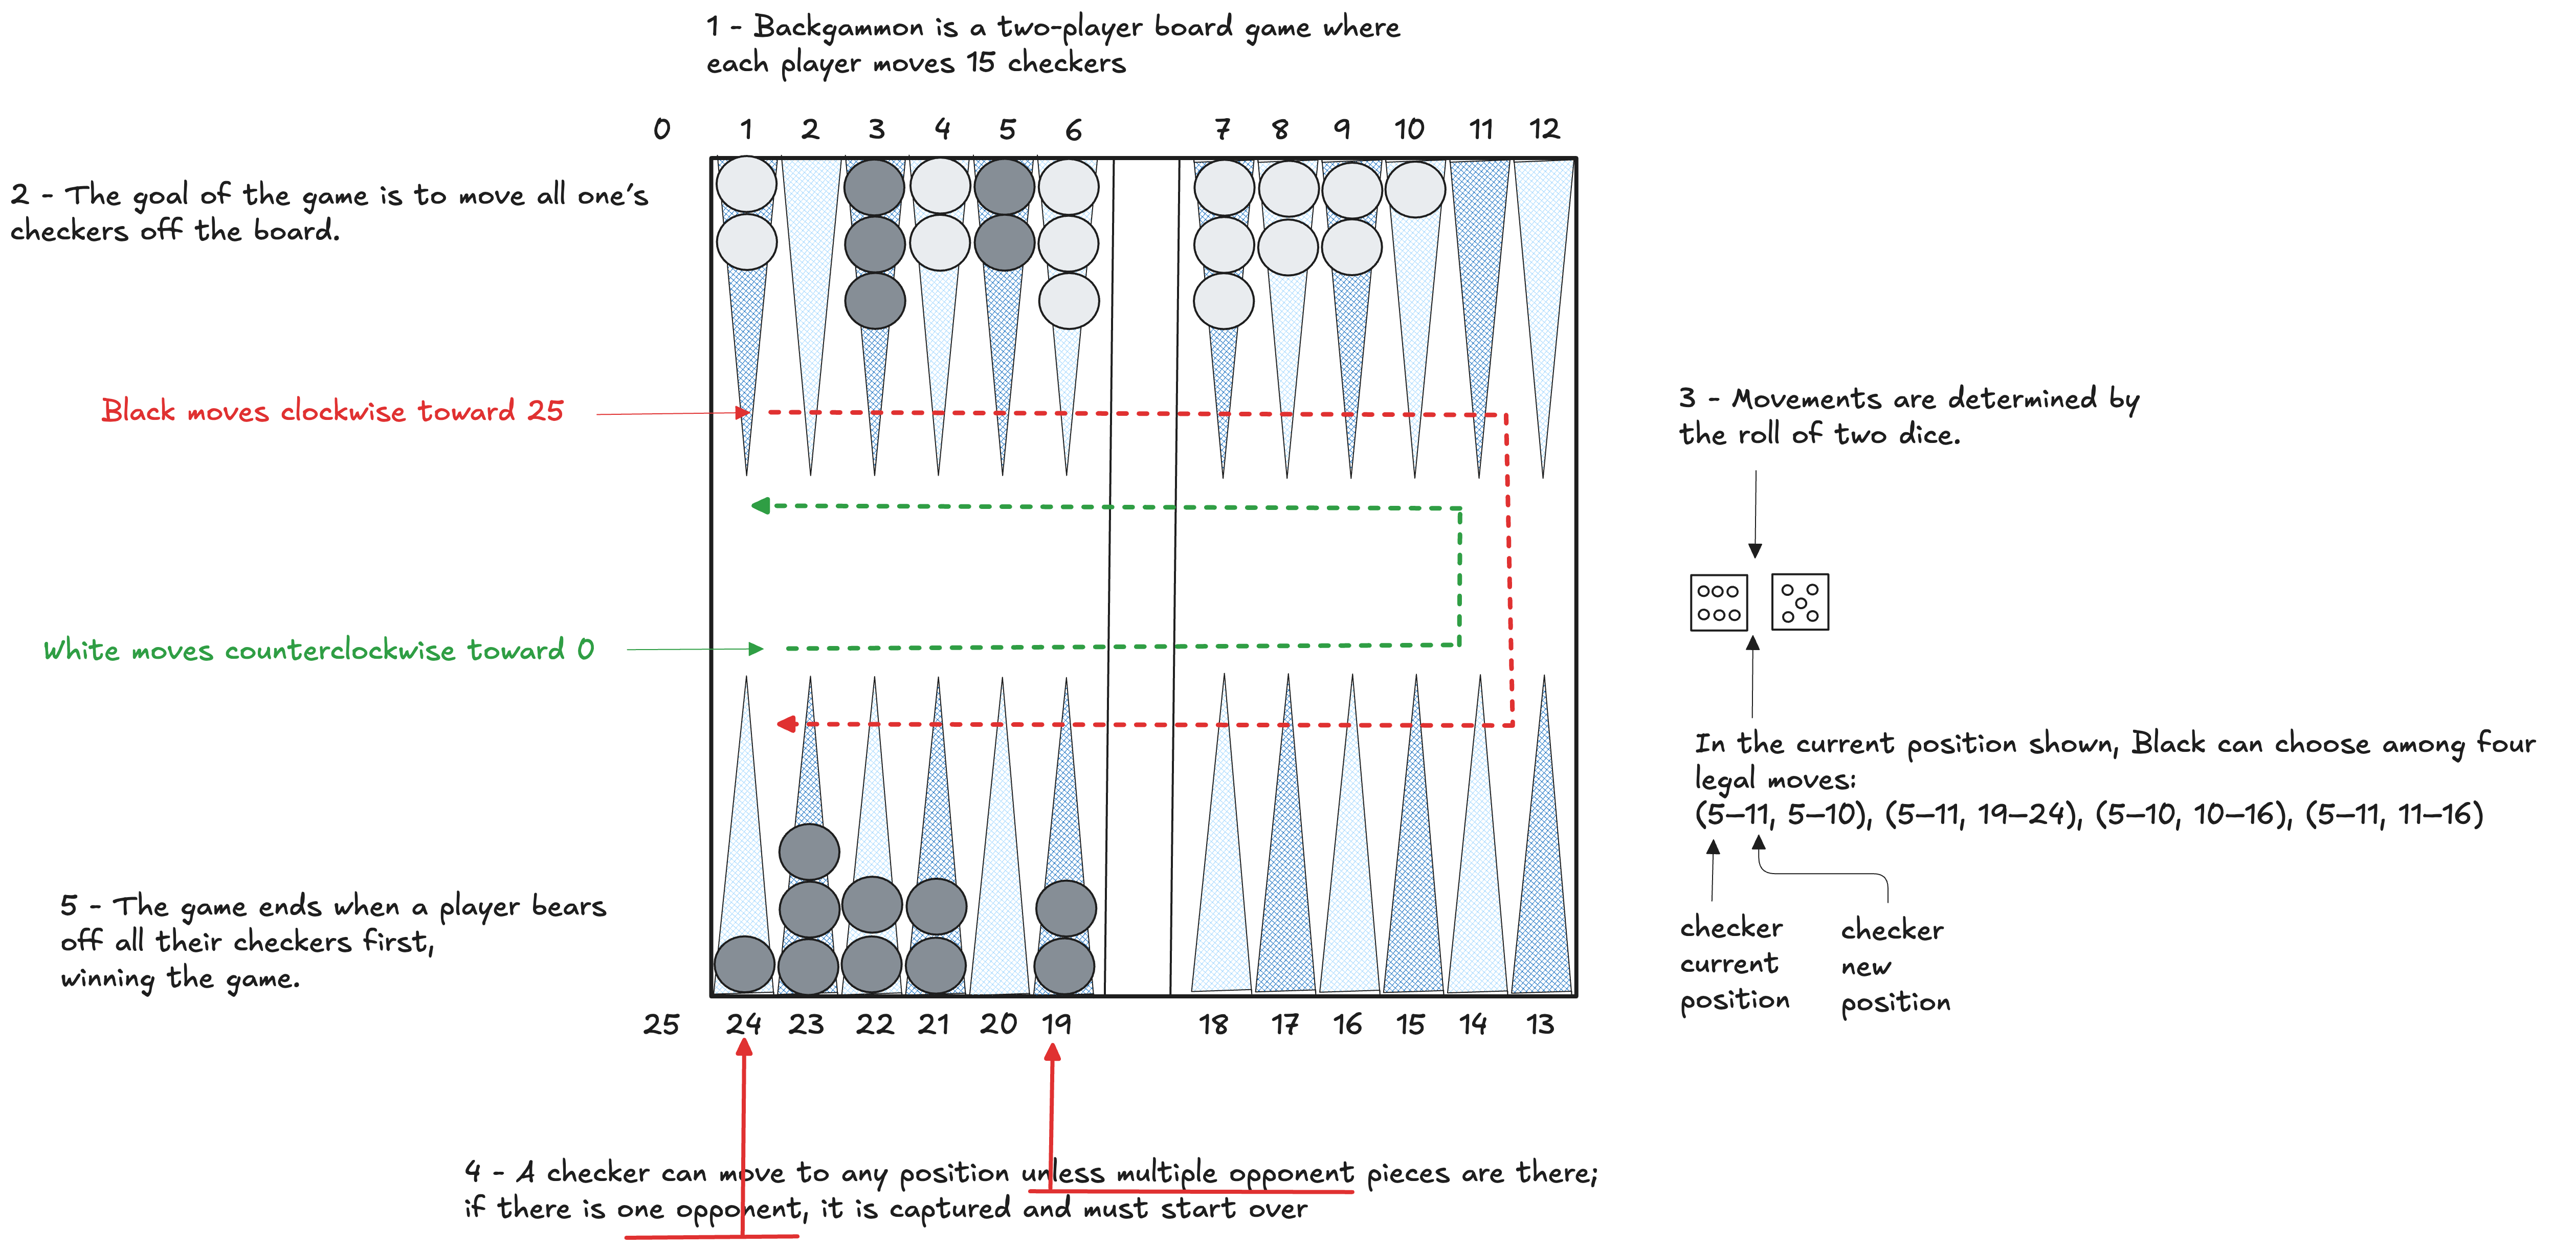

We can implement the logic of Backgammon creating a concrete subclass of StochasticGame:

In [24]:
import itertools
import copy
import operator

class Backgammon(StochasticGame):

    def __init__(self):

        # Initialize the board with 24 points
        point = {'W': 0, 'B': 0}
        board = [point.copy() for index in range(24)]
        
        # Define the initial board configuration
        board[0]['B'] = board[23]['W'] = 2
        board[5]['W'] = board[18]['B'] = 5
        board[7]['W'] = board[16]['B'] = 3
        board[11]['B'] = board[12]['W'] = 5
        
        # Define the directions for each player
        self.direction = {'W': -1, 'B': 1}

        # Create the initial state
        self.initial = StochasticGameState(to_move='W',
                                           utility=0,
                                           board=board,
                                           moves=self.get_all_moves(board, 'W'), chance=None)

    # Utility methods

    def checkers_out_of_home(self, board, player):
        # Return the number of checkers at home for a player
        sum_range = range(8, 24) if player == 'W' else range(0, 16)
        count = 0
        for idx in sum_range:
            count = count + board[idx][player]
        return count 

    def checkers_at_home(self, board, player):
        # Return the number of checkers at home for a player
        sum_range = range(0, 7) if player == 'W' else range(17, 24)
        count = 0
        for idx in sum_range:
            count = count + board[idx][player]
        return count

    def get_all_moves(self, board, player):
        # All possible ways of choosing two checkers of a player 
        # from the board for a move at a given state."""
        all_points = board
        taken_points = [index for index, point in enumerate(all_points) if point[player] > 0]
        if self.checkers_at_home(board, player) == 1:
            return [(taken_points[0],)]
        moves = list(itertools.permutations(taken_points, 2))
        moves = moves + [(index, index) for index, point in enumerate(all_points)
                         if point[player] >= 2]
        return moves
    
    def compute_utility(self, board, move, player):
        # If 'W' wins with this move, return 1; 
        # if 'B' wins return -1; 
        # else return 0."""
        util = {'W': 1, 'B': -1}
        for idx in range(0, 24):
            if board[idx][player] > 0:
                return 0
        return util[player]
    
    def is_legal_move(self, board, start, steps, player):
        # Move is a tuple which contains starting points of checkers to be
        # moved during a player's turn. An move is legal if both the destinations
        # are open. A bear-off move is the one where a checker is moved off-board.
        # It is legal only after a player has moved all his checkers to his home
        dest1, dest2 = tuple(map(operator.add, start, steps))
        dest_range = range(0, 24)
        move1_legal = move2_legal = False
        if dest1 in dest_range:
            if self.is_point_open(player, board[dest1]):
                self.move_checker(board, start[0], steps[0], player)
                move1_legal = True
        else:
            if self.checkers_out_of_home(board, player) ==  0:
                self.move_checker(board, start[0], steps[0], player)
                move1_legal = True
        if not move1_legal:
            return False
        if dest2 in dest_range:
            if self.is_point_open(player, board[dest2]):
                move2_legal = True
        else:
            if self.checkers_out_of_home(board, player) == 0:
                move2_legal = True
        return move1_legal and move2_legal

    def move_checker(self, board, start, steps, player):
        # Move a checker from starting point by a given number of steps
        dest = start + steps
        dest_range = range(0, 24)
        board[start][player] -= 1
        if dest in dest_range:
            board[dest][player] += 1
            
    
    def is_point_open(self, player, point):
        # A point is open for a player if the number of opponent
        # checkers already present on it is 0 or 1.
        opponent = 'B' if player == 'W' else 'W'
        return point[opponent] <= 1

    # Game methods

    def actions(self, state):
        # Return a list of the allowable moves at this state
        player = state.to_move
        moves = state.moves
        if len(moves) == 1 and len(moves[0]) == 1:
            return moves
        legal_moves = []
        for move in moves:
            board = copy.deepcopy(state.board)
            if self.is_legal_move(board, move, state.chance, player):
                legal_moves.append(move)
        return legal_moves

    def result(self, state, move):
        # Return the state that results from making a action from a state
        board = copy.deepcopy(state.board)
        player = state.to_move
        self.move_checker(board, move[0], state.chance[0], player)
        if len(move) == 2:
            self.move_checker(board, move[1], state.chance[1], player)
        to_move = ('W' if player == 'B' else 'B')
        return StochasticGameState(to_move=to_move,
                                   utility=self.compute_utility(board, move, player),
                                   board=board,
                                   moves=self.get_all_moves(board, to_move), chance=None)

    def utility(self, state, player):
        # Return the value of this final state to player
        return state.utility if player == 'W' else -state.utility

    def terminal_test(self, state):
        # Return True if this is a final state for the game
        return state.utility != 0

    def display(self, state):
        # Display the game state
        board = state.board
        player = state.to_move
        print("current state : ")
        for index, point in enumerate(board):
            print("point : ", index, "	W : ", point['W'], "    B : ", point['B'])
        print("to play : ", player)

    # Stochastic Game methods

    def chances(self, state):
        # Return a list of all possible dice rolls at a state
        dice_rolls = list(itertools.combinations_with_replacement([1, 2, 3, 4, 5, 6], 2))
        return dice_rolls

    def outcome(self, state, chance):
        # Return the state which is the outcome of a dice roll
        dice = tuple(map((self.direction[state.to_move]).__mul__, chance))
        return StochasticGameState(to_move=state.to_move,
                                   utility=state.utility,
                                   board=state.board,
                                   moves=state.moves, chance=dice)

    def probability(self, chance):
        # Return the probability of occurrence of a dice roll
        return 1 / 36 if chance[0] == chance[1] else 1 / 18

We can play a game of Backgammon between two random players:

In [27]:
backgammon = Backgammon()

# Print the starting state
backgammon.display(backgammon.initial)

# Play the game
result = play_stochastic(backgammon, random_player, random_player)
print("Game over! Final utility:", result)


current state : 
point :  0 	W :  0     B :  2
point :  1 	W :  0     B :  0
point :  2 	W :  0     B :  0
point :  3 	W :  0     B :  0
point :  4 	W :  0     B :  0
point :  5 	W :  5     B :  0
point :  6 	W :  0     B :  0
point :  7 	W :  3     B :  0
point :  8 	W :  0     B :  0
point :  9 	W :  0     B :  0
point :  10 	W :  0     B :  0
point :  11 	W :  0     B :  5
point :  12 	W :  5     B :  0
point :  13 	W :  0     B :  0
point :  14 	W :  0     B :  0
point :  15 	W :  0     B :  0
point :  16 	W :  0     B :  3
point :  17 	W :  0     B :  0
point :  18 	W :  0     B :  5
point :  19 	W :  0     B :  0
point :  20 	W :  0     B :  0
point :  21 	W :  0     B :  0
point :  22 	W :  0     B :  0
point :  23 	W :  2     B :  0
to play :  W
Game over! Final utility: -1


We can realize some statistics about the probability of winning in backgammon for the random player:

In [31]:
# Create a new Backgammon game
backgammon = Backgammon()

win_max_prop, win_min_prop, _ = run_experiment(backgammon, play_stochastic, random_player, random_player, num_games=100)

# Print the results
print(f"Proportion of Wins for MAX Random player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")

Proportion of Wins for MAX Random player: 0.5700
Proportion of Wins for MIN Random player: 0.4300


### Expected-minimax

Black knows what moves can be made, but does not know what White is going to roll and thus does not know what White legal moves will be. That means Black **cannot construct a standard game tree** of the sort we saw in Tic-Tac-Toe. We need to include **chance nodes** in addition to MAX and MIN nodes:

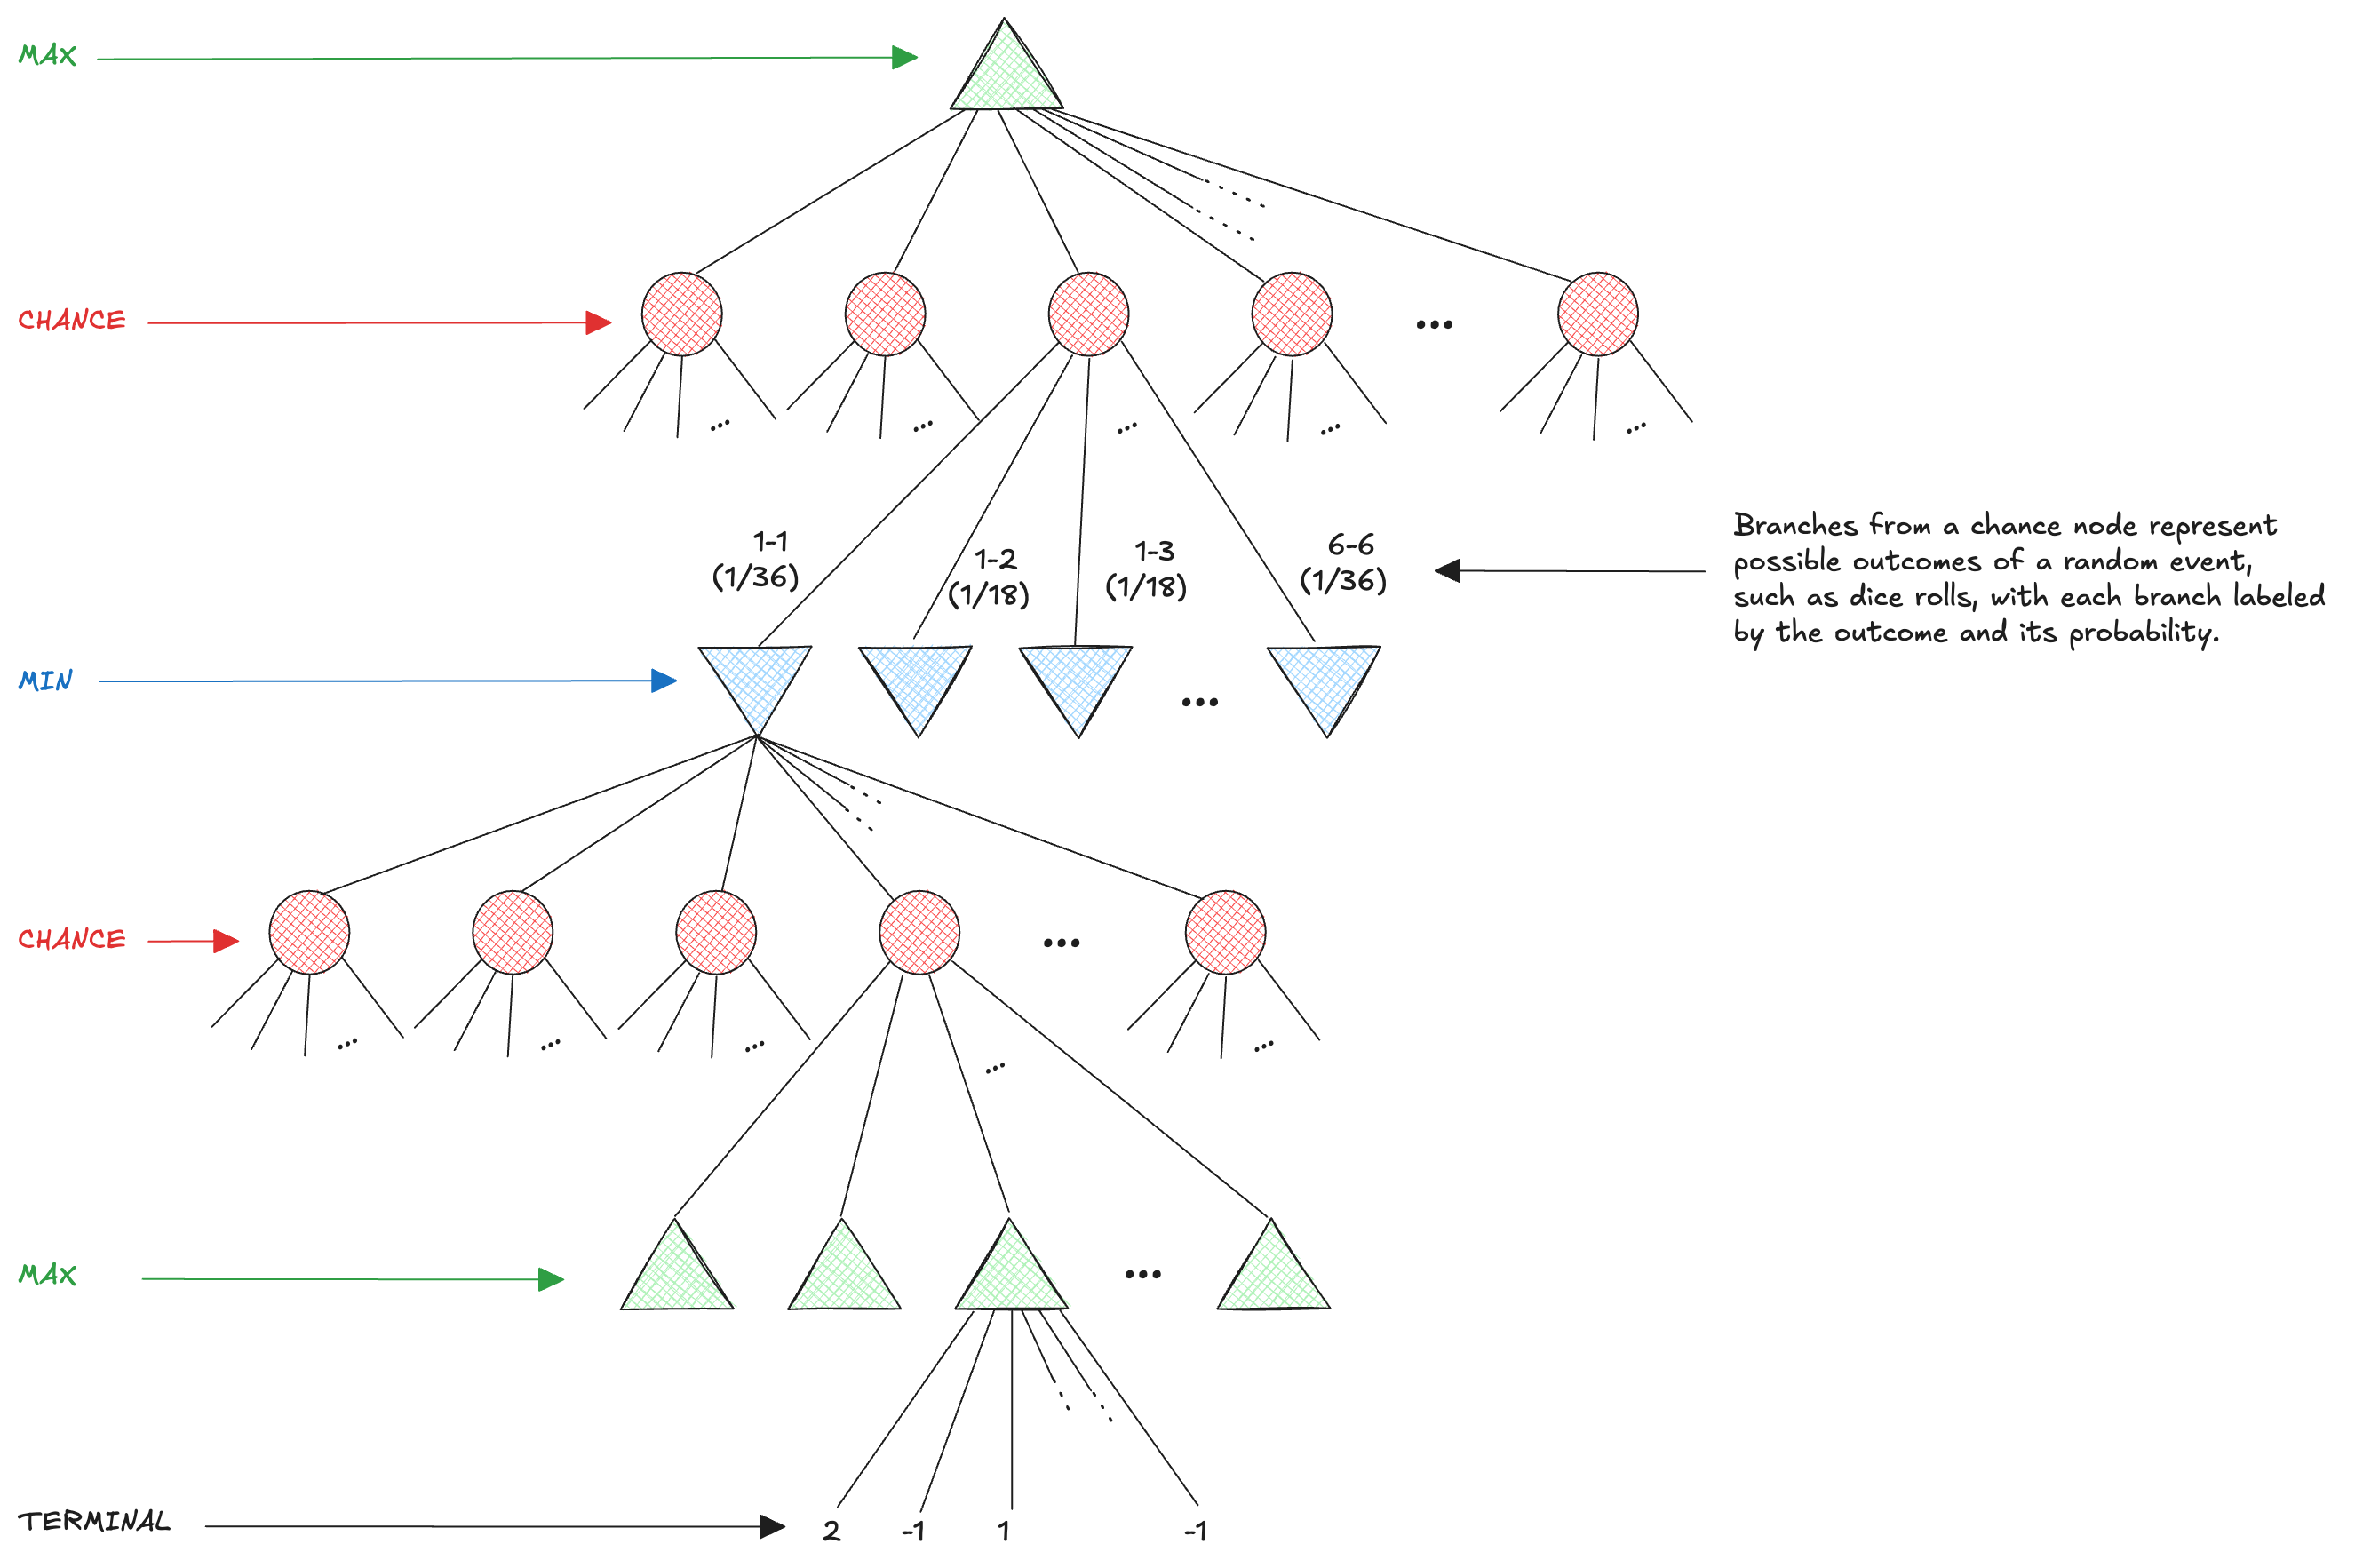

The next step is to understand how to make correct decisions. Obviously, we still want to pick the move that leads to the best position. However, positions do not have definite minimax values. Instead, we can only calculate the **expected value** of a position: the average over all possible outcomes of the chance nodes. This leads us to the **expected-minimax value** for games with chance nodes, a generalization  of the minimax value for deterministic games. Terminal nodes and MAX and MIN nodes work exactly the same way as before (with the caveat that the legal moves for MAX and MIN will depend on the outcome of the dice roll in the previous chance node). For chance nodes we compute the expected value, which is the sum of the value over all outcomes, weighted by
the probability of each chance action:

$\displaystyle \text{expected-minimax}( s) = \begin{cases} \text{utility}( s) & \text{if } \text{is-terminal}( s) \\ \max_{a} \text{expected-minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MAX} \\ \min_{a} \text{expected-minimax}( \text{result}( s, a)) & \text{if } \text{player}( s) = \text{MIN} \\ \sum_{a} \text{p}(r) \text{expecedt-minimax}( \text{result}(s, r)) & \text{if } \text{player}(s) = \text{CHANCE} \end{cases}$

where r represents a possible chance event.

In [35]:
import numpy as np

def expected_minimax_player(game, state):


    player = game.to_move(state)

    def max_value(state):
        if game.terminal_test(state):
            return game.utility(state, player)
        v = -np.inf
        for a in game.actions(state):
            v = max(v, chance_node(state, a, player))
        return v

    def min_value(state):
        if game.terminal_test(state):
            return game.utility(state, player)
        v = np.inf
        for a in game.actions(state):
            v = min(v, chance_node(state, a, player))
        return v

    def chance_node(state, action, current_player): 
        res_state = game.result(state, action)

        if game.terminal_test(res_state):
            return game.utility(res_state, player) 

        sum_chances = 0
        num_chances = len(game.chances(res_state))
        for chance in game.chances(res_state):
            res_state = game.outcome(res_state, chance)
            util = 0
            if game.to_move(res_state) == player: 
                util = max_value(res_state)
            else:
                util = min_value(res_state)
            sum_chances += util * game.probability(chance)
        return sum_chances / num_chances

    # Decide the better move
    best_action = None
    best_value = float('-inf') if player == game.to_move(state) else float('inf') 
    
    for action in game.actions(state):
        value = chance_node(state, action, player)  
        if player == game.to_move(state): 
            if value > best_value:
                best_value = value
                best_action = action
        else: # min player
            if value < best_value:
                best_value = value
                best_action = action

    return best_action

We cannot use this implementation on Backgammon since the number of state is too large, we can try to apply the idea of cutting off the search and using an evaluation function.

### Evaluation functions and cuttin-off with chance

Like minimax, expected-minimax can be approximated by **cutting off** the search and applying an **evaluation function** at the leaves. While backgammon evaluation function, like in chess, assigns higher values to better positions, **chance nodes** require careful interpretation of these values due to randomness. Consider the following example:

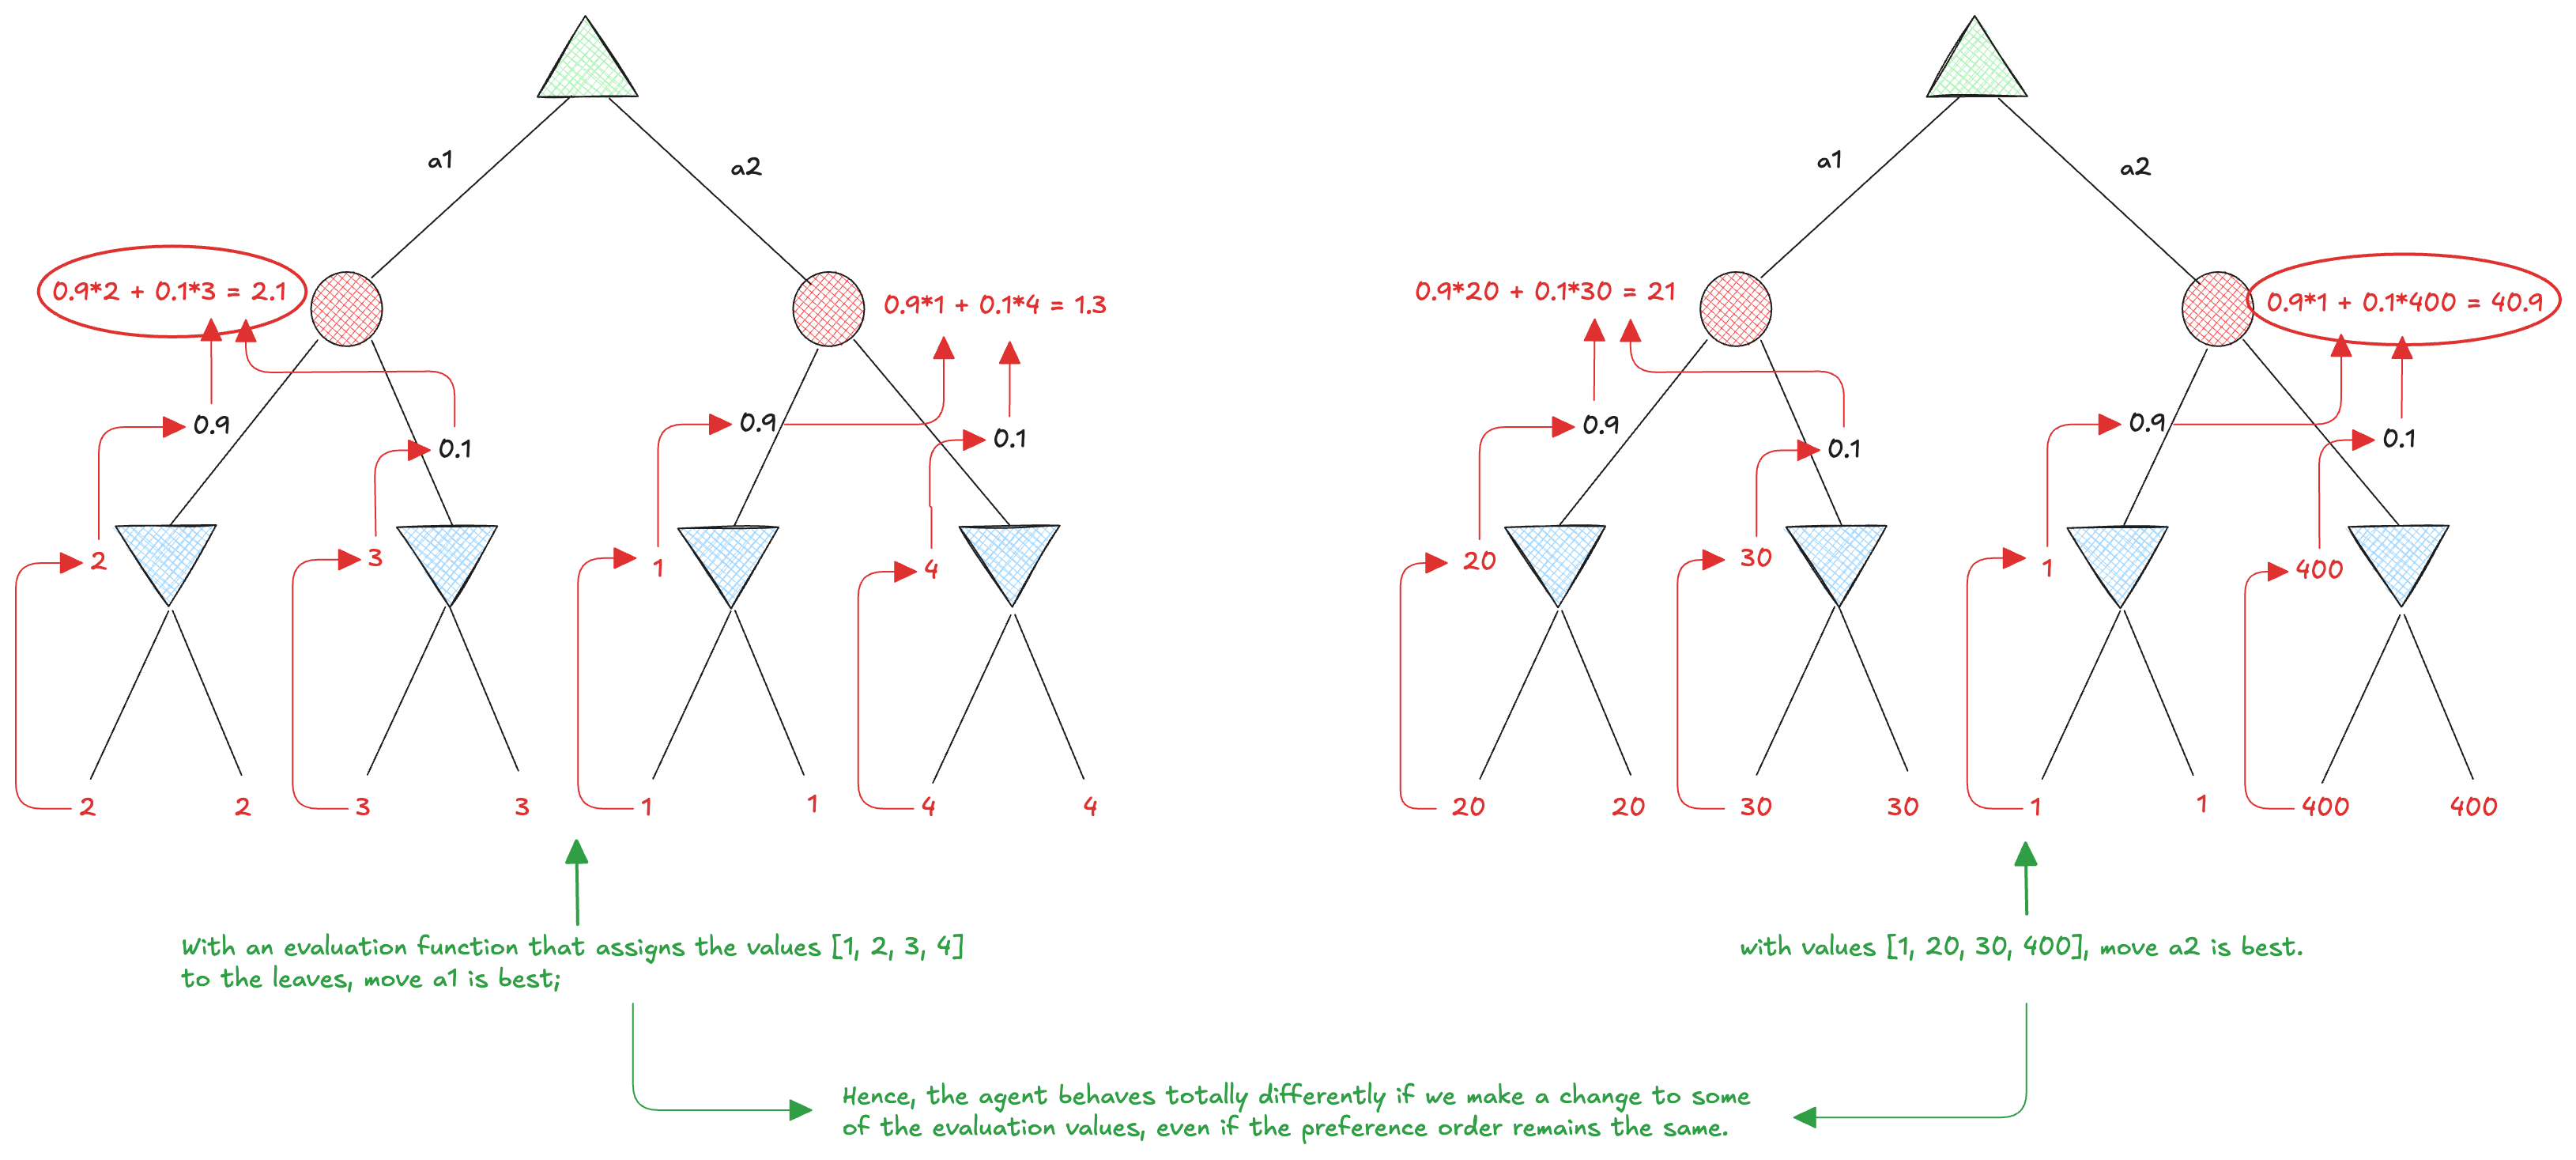

This shows that even if the relative order of outcomes remains the same, scaling the evaluation values can lead to completely different decisions, highlighting the sensitivity of the algorithm to evaluation functions. To avoid this problem, the evaluation function must return values that are a **positive linear transformation of the probability of winning** (or of the expected utility, for games that have outcomes other than win/lose). This relation to probability is an important and general property of situations in which uncertainty is involved.

However, since expected-minimax is considering all the possible actions (the brancing factor b) and all the possible dice-roll sequences (n) until the end (maximum depth m), the time complexity of the algorithm is:

$\displaystyle O(b^m n^m)$

Even with limited search depth, the extra cost compared to minimax makes deep lookahead impractical in most games of chance. Also the alpha-beta pruning is not effective.It works by ignoring unlikely future developments, focusing on probable outcomes. However, in games where dice rolls precede moves, no sequence is truly likely, since each move depends on a specific roll, which occurs at most 2/36 of the time. This is a **general problem** whenever **uncertainty** enters the picture: the **possibilities are multiplied enormously**, and **forming detailed plans of action becomes pointless** because the world probably will not play along. We need to approach the problme in a different way.

## Monte Carlo Tree Search

When the numer of states becomes too large, we encounters two major weaknesses of heuristic alpha–beta tree search: first, if the branching factor is huge, we are limited to only 4 or 5 level of depth. Second, it is often difficult to define a good evaluation function for situation with no strong indicators. In response to these two challenges, we can navigating the complexities of games of chance and large deterministic games by intelligently sampling the game tree, focusing computation on the most promising areas rather than exhaustively exploring all possibilities.

### Go game

Go is an ancient oriental board game with simple rules but rich in strategy. Played by two players, the game involves alternately placing black and white stones on a 19x19 grid. Once placed, the stones cannot be moved. However, they can be surrounded and captured by the opponent's stones. The objective of the game is to control (or surround) a larger portion of the board. Placing stones close together allows them to support each other and avoid capture, while placing them farther apart creates influence across a larger area of the board. Go's strategic difficulty lies in balancing these opposing interests: defensive tactics for protection and offensive maneuvers to expand influence. Players must navigate between tactical urgency and long-term strategic planning:

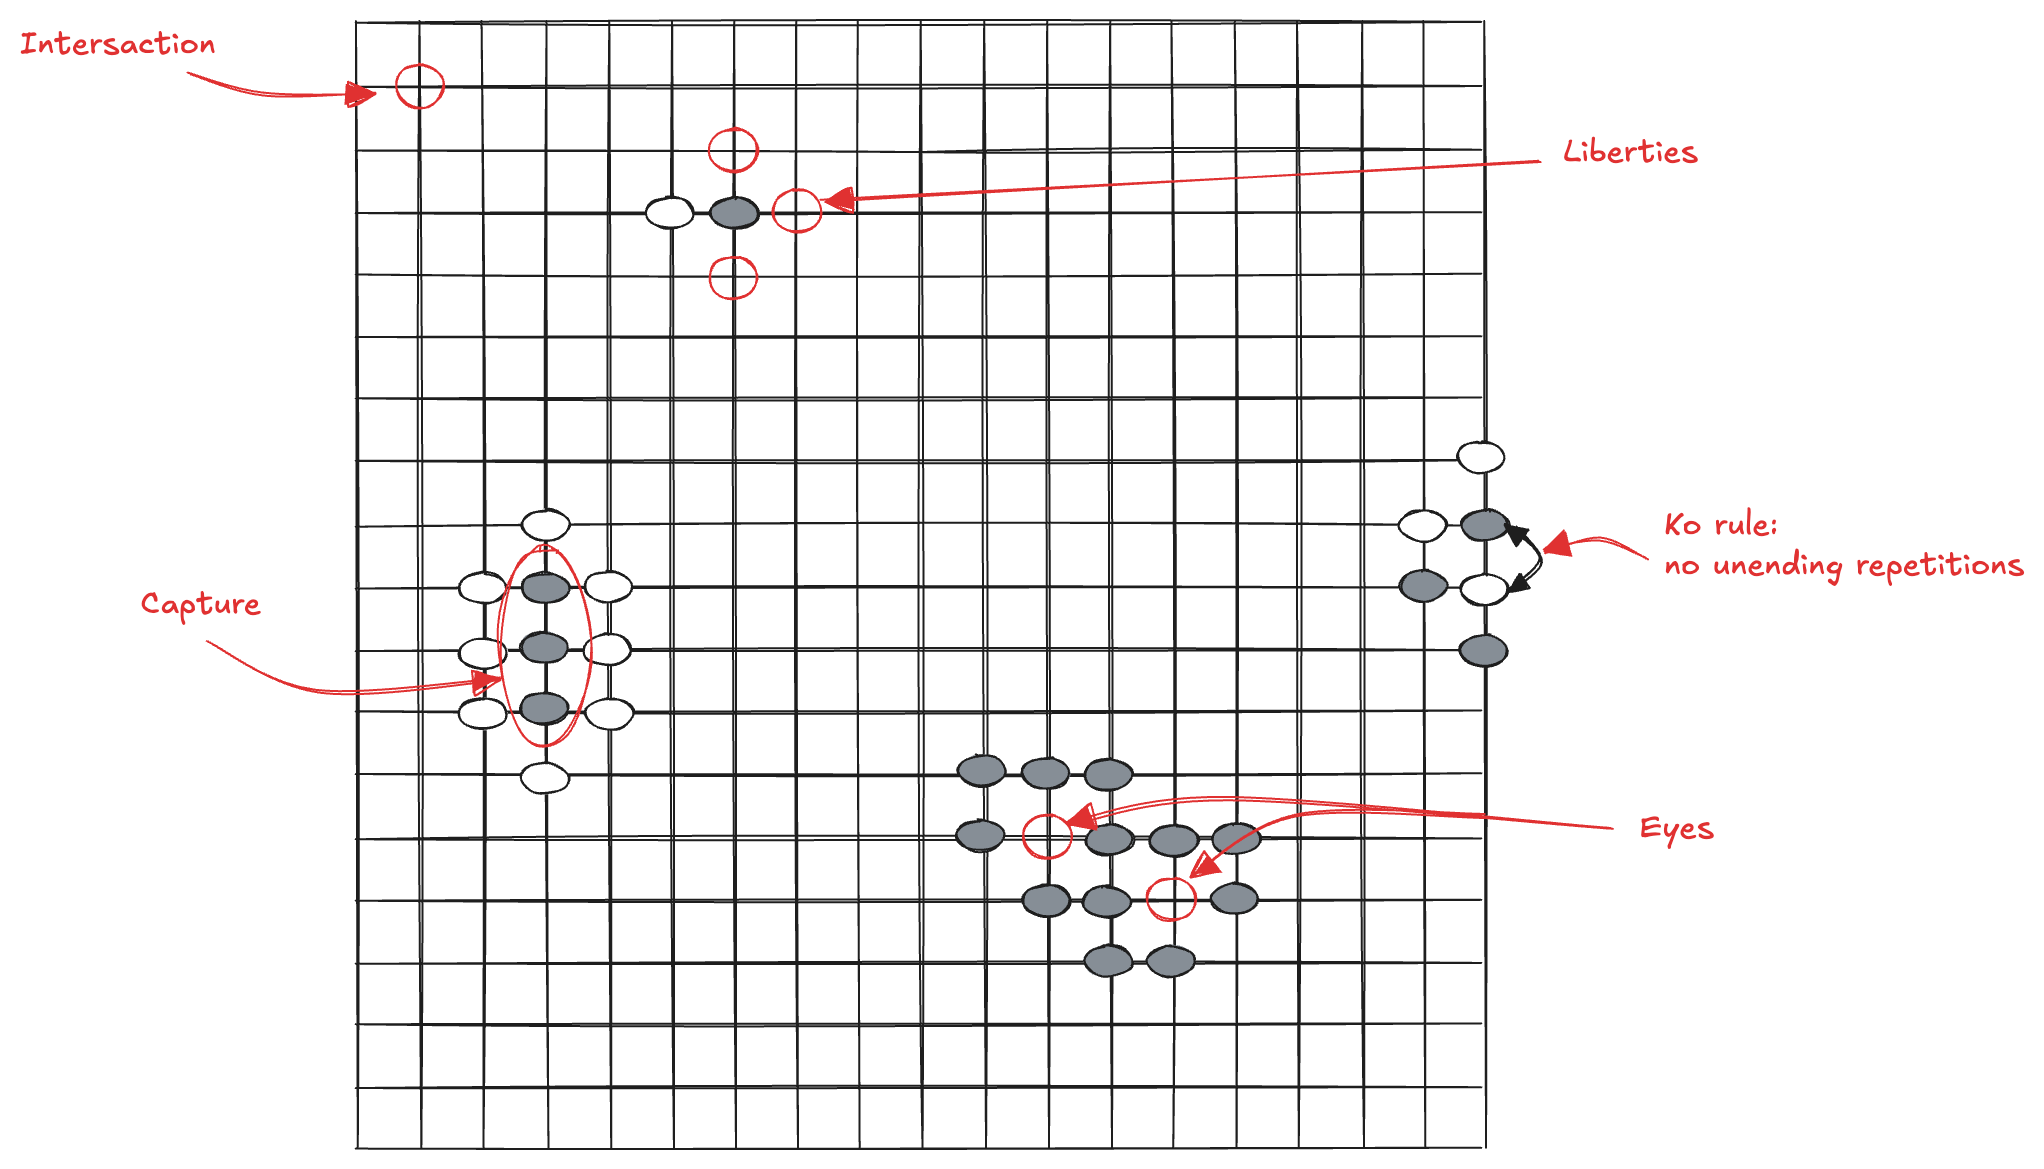

The game of Go illustrates the two major weaknesses. It has an **enormous branching factor**. In chess, the average number of legal moves per turn is around 35, while in Go, it can exceed 200. This makes search impractical, even with cutting-off and alpha-beta pruning optimizations. The complexity also arises from the **challenge of evaluating positions**. In chess, material count provides clear heuristics, but in Go, there is no straightforward way to measure territory, influence, or potential future gains. Go involves **long-term strategic interactions** where the value of a move may only **become apparent many turns later**. Heuristic minimax struggles in such situations because it relies on good heuristics to prune unpromising moves, but Go positional advantages are often too subtle for evaluation functions. Another difficulty comes from the **need for deep search**. In chess, strong play is possible at moderate search depths, but in Go, deep lookahead is essential because small local battles can have consequences across the entire board. Because of these factors, traditional alpha-beta cutting off heuristic minimax algorithms perform poorly in Go, requiring alternative approaches.

### Monte Carlo approach

The **Monte Carlo method** is a family of statistical techniques that uses **random sampling** to **estimate numerical results**. By repeatedly generating experimental conditions according to a known probability distribution, these methods estimate the probability of an event by calculating the relative frequency of its occurrence. As the number of simulations increases, this estimate converges towards the true probability. The name "Monte Carlo" is a reference to the Monte Carlo Casino in Monaco, known for its games of chance. As a simple example, a classic approach to estimate $\pi$ involves the **hit-and-miss algorithm**. Consider a square with a circle inside:

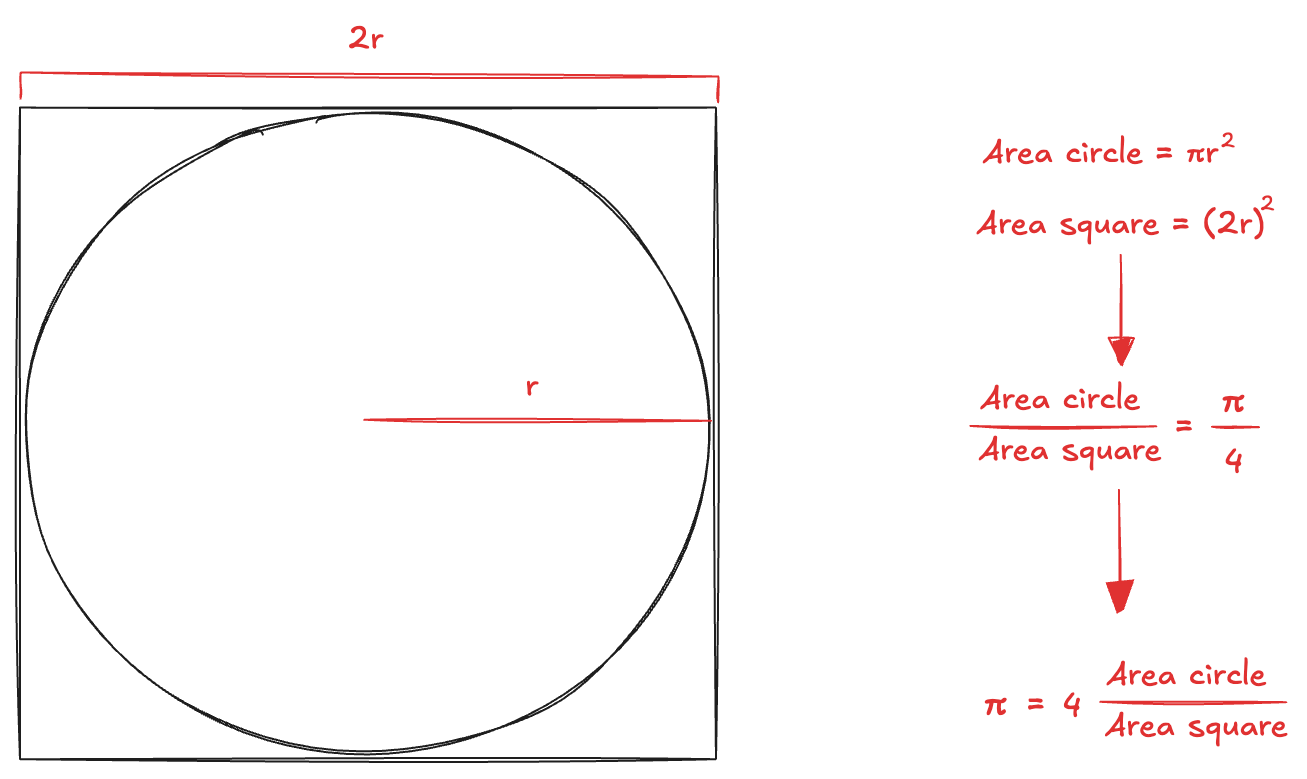

To approximate this ratio, random points can be generated inside the square. The number of points that fall inside the circle is counted, and $\pi$ is estimated as 

$\displaystyle \pi \approx 4 \times \frac{\text{\# of points inside the circle}}{\text{Total \# of points}}$

With a large number of points, the estimate becomes more accurate:

In [37]:
def estimate_pi(num_points):
    inside_circle = 0
    
    for _ in range(num_points):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        
        # Check if the point is inside the unit circle
        if x**2 + y**2 <= 1:
            inside_circle += 1
    
    pi_estimate = 4 * inside_circle / num_points
    return pi_estimate

In [46]:
# Example usage
num_points = 1000000
print(f"Estimated value of Pi: {estimate_pi(num_points)}")

Estimated value of Pi: 3.138736


Another example is the **Monte Carlo integration** using again the hit-and-miss method. Suppose we need to compute the integral of a function:

$\displaystyle I = \int_{a}^{b} f( x) dx$

We randomly sample points within a rectangular region that contains the area under the function:

$\displaystyle (x_1, y_1), (x_2, y_2), \ldots, (x_n, y_n)$

For each random point, check if the point lies below the curve

$\displaystyle y_i < f(x_i)$

The estimate of the integral is proportional to the fraction of points that fall below the curve: 

$\displaystyle I \approx \frac{\text{\# of points below the curve}}{n} \times \text{area of the rectangle}$

In [48]:
def monte_carlo_integration(func, a, b, M, n):

    # Count the number of points under the curve
    points_under_curve = 0

    for _ in range(n):
        
        # Randomly sample x from [a, b]
        x = random.uniform(a, b)
        
        # Randomly sample y from [0, M]
        y = random.uniform(0, M)

        # Check if the point is under the curve
        if y <= func(x):
            points_under_curve += 1

    # Estimate the integral
    integral_estimate = (b - a) * M * (points_under_curve / n)

    return integral_estimate

In [56]:
# Example function f(x)
def f(x):
    return x**2  # Example: f(x) = x^2

# Parameters
a = 0  # Lower bound of the interval
b = 1  # Upper bound of the interval
M = 1  # Maximum value of the function f(x) in the interval [a, b]
n = 1000000  # Number of random samples

# Run the Monte Carlo integration
estimated_integral = monte_carlo_integration(f, a, b, M, n)

print(f"Estimated integral: {estimated_integral}")

Estimated integral: 0.333834


### Combining Monte Carlo with tree search

The key idea is to estimate a state value as the **average utility over multiple simulated games**, instead of using a heuristic evaluation function. Each simulation (**playout** or **rollout**) alternates moves between players until reaching a terminal position, where the game's rules determine the winner and score: 

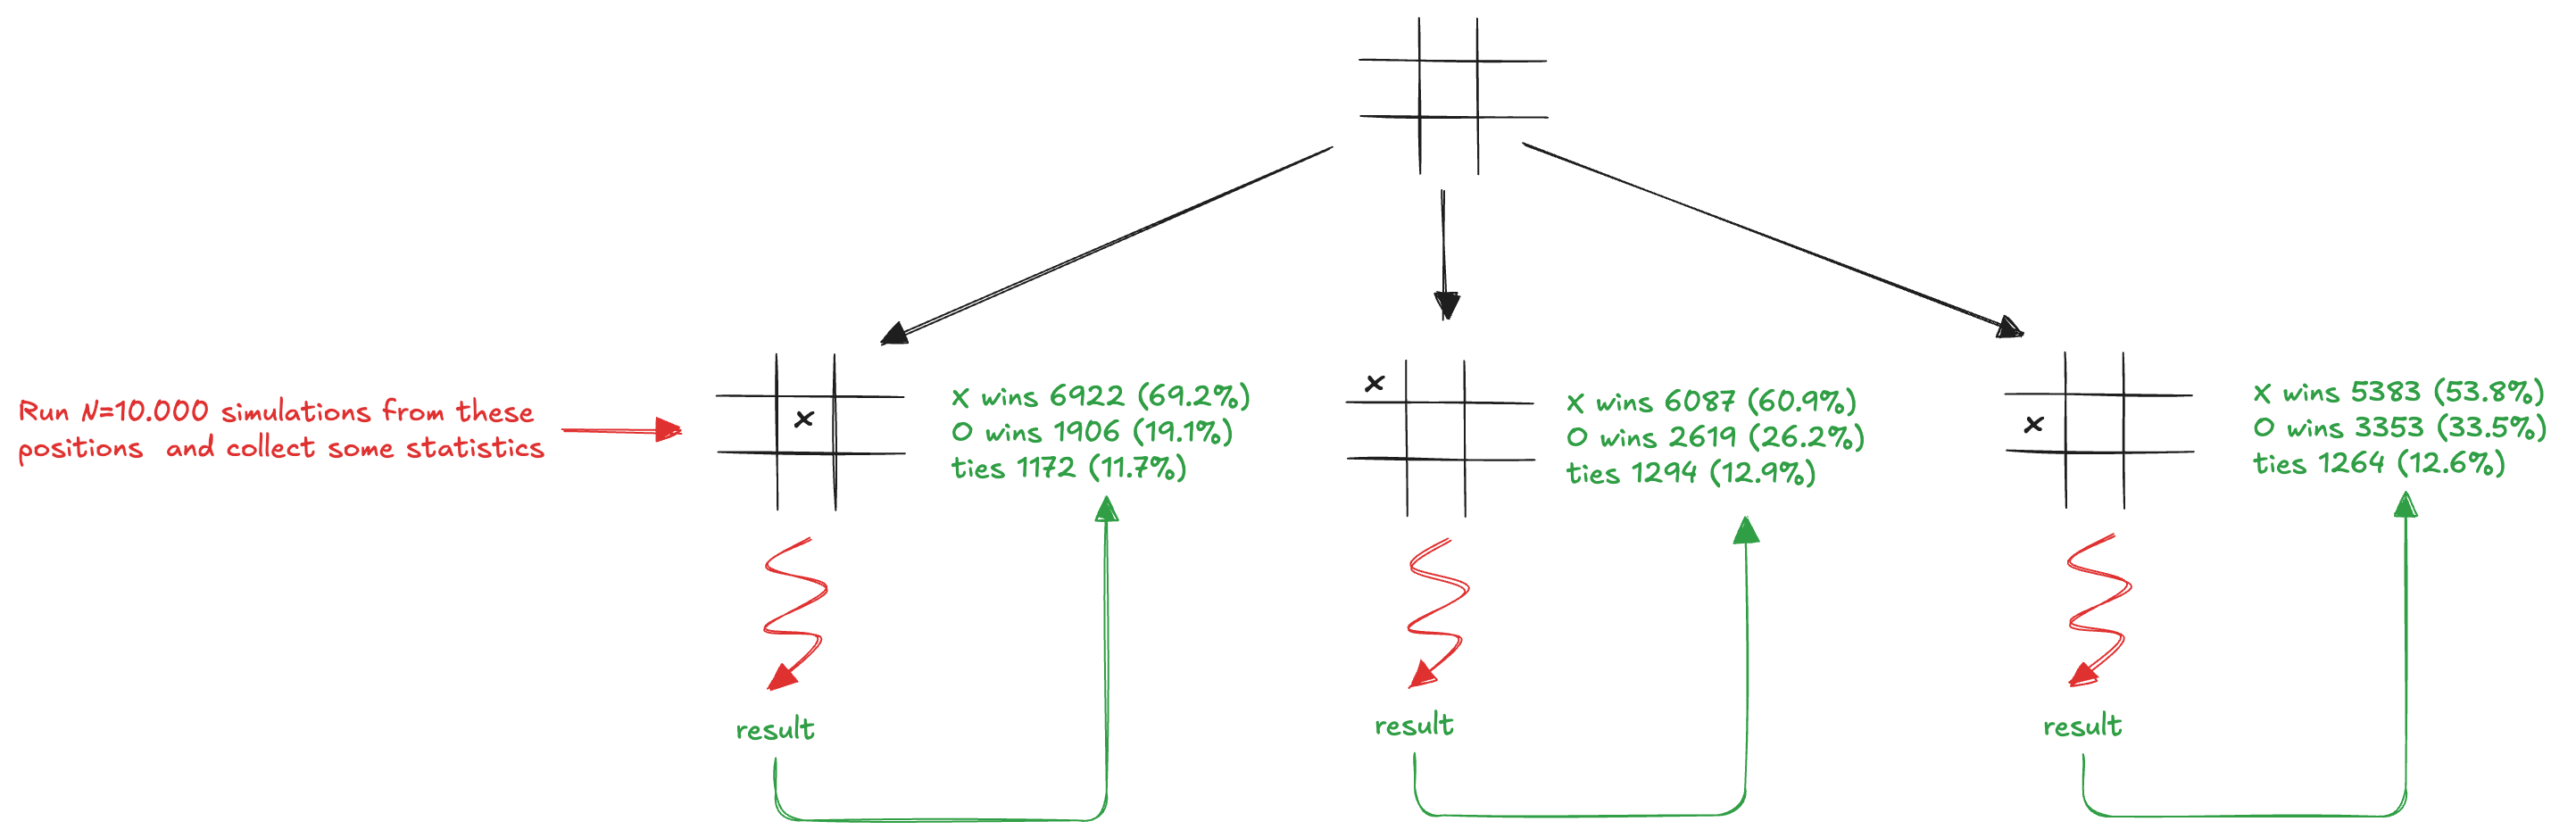

How should moves be chosen during a playout? Random moves answer only *"What is the best move if both players play randomly?", which rarely aligns with optimal play. To extract useful insights, a **playout policy** should bias moves toward better ones. In games like Go, such policies can be learned via self-play with neural networks, while some games use heuristics (e.g. "prioritizing capture moves" in chess). With a playout policy in place, we must decide where to start playouts and how many to allocate per position. **Pure Monte Carlo search** runs simulations from the current game state, selecting moves with the highest win rate. 

In [69]:
def pure_monte_carlo_player(game, state, num_simulations=100):
    
    # Function to plays a random game from the given state 
    # to a terminal state and returns the winner
    def random_playout(game, state):
        while not game.terminal_test(state):
            move = random.choice(game.actions(state))
            state = game.result(state, move)
        return 'X' if game.utility(state, 'X') > 0 else ('O' if game.utility(state, 'O') > 0 else None)
    
    best_move = None
    best_win_rate = -float('inf')
    
    for move in game.actions(state):
        wins = sum(1 for _ in range(num_simulations) if random_playout(game, game.result(state, move)) == state.to_move)
        win_rate = wins / num_simulations
        
        if win_rate > best_win_rate:
            best_win_rate = win_rate
            best_move = move
    
    return best_move

We can make an experiment with the Tic-Tac-Toe game versus the random player:

In [76]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, play, pure_monte_carlo_player, random_player, num_games=100)

# Print the results
print(f"Proportion of Wins for MAX Pure Monte Carlo player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX Pure Monte Carlo player: 0.9900
Proportion of Wins for MIN Random player: 0.0000
Proportion of Draws: 0.0100


The results show that the Pure Monte Carlo player is highly effective against the Random player, but **not optimal**. It relies on **random playouts**, meaning it evaluates moves based on their performance in randomly played games. In some situations where securing a draw would be the best strategy, the algorithm chooses to take risks in pursuit of a win. Since the Random player only occasionally makes the right move by chance, this approach can sometimes backfire, leading to unnecessary losses. While this can works on simple game, it is often insufficient. A **selection policy** is needed to focus computation on key parts of the game tree, balancing **exploration** (testing less-visited states) and **exploitation** (favoring successful states). **Monte Carlo Tree Search (MCTS)** achieves this by iteratively expanding a search tree through four steps:

- (A) **Selection**: starting at the root of the search tree, we choose a move (guided by the selection policy), leading to a successor node, and repeat that process, moving down the tree to a leaf.
- (B) **Expansion**: we grow the search tree by generating a new child of the selected node.
- (C) **Simulation**: we perform a playout from the newly generated child node, choosing moves for both players according to the playout policy. These moves are not recorded in the search tree. 
- (D) **Back-propagation**: we now use the result of the simulation to update all the search tree nodes going up to the root.

We repeat these four steps either for a set number of iterations, or until the allotted time has expired. For example, consider the following game with a search tree with the root representing a state where MAX has just moved several times:

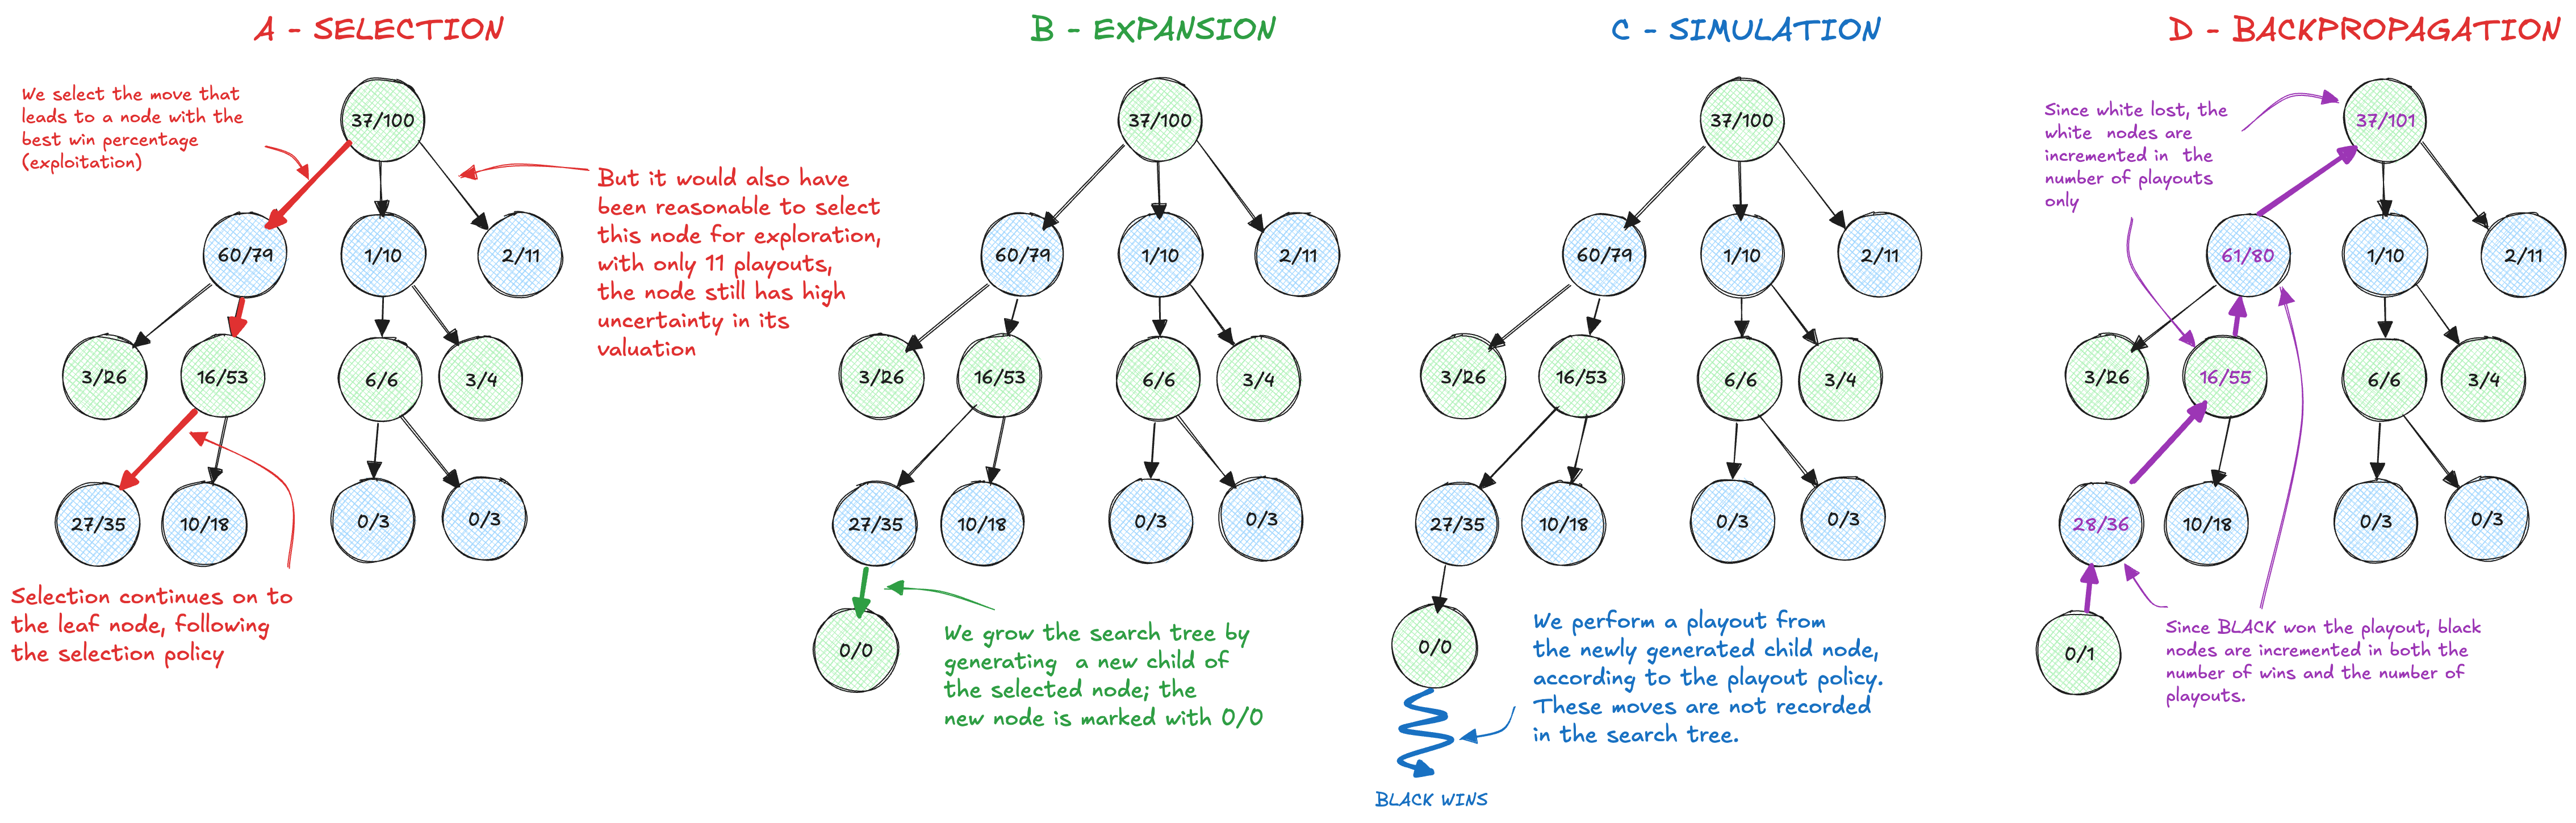

In the end, we choose the move with the **highest visit count** because it reflects the **most extensively explored branch** of the game tree. This extensive sampling minimizes the influence of random fluctuations and ensures a more reliable evaluation. Although metrics like win ratio can indicate promise, they may be volatile when based on few simulations, making the visit count a more stable indicator of the best move. We can implement a simple container for storing the state of a node in the MCTS tree:

In [105]:
class MCTSNode:
    def __init__(self, state, parent=None, move=None):

        # The game state in that node
        self.state = state

        # The parent note in the tree
        self.parent = parent

        # The move that led from the parent to this node
        self.move = move

        # The children nodes of this node
        self.children = []
        
        # Moves that have not been expanded yet
        self.untried_moves = []

        # MCTS statistics of the node
        self.wins = 0
        self.visits = 0

Now we can implement a function to perform the four steps of the MCTS algorithm:

In [106]:
def mcts_select(node, game, selection_function):
    # Starting from a node, descend the tree until    
    # reaching a node that is either terminal or not fully expanded
    while not game.terminal_test(node.state):
        if not len(node.untried_moves) == 0:
            # We found a node that can be expanded, so return it
            return node
        else:
            # Otherwise, descend to the best child
            # using a selection function 
            scores = [selection_function(node, c) for c in node.children]
            best_index = max(range(len(node.children)), key=lambda i: scores[i])
            node = node.children[best_index]
    return node

In [107]:
def mcts_expand(node, game):
    # Take one untried move from node, generate its child, 
    # and add that child to node.children. Return the new child
    move = node.untried_moves.pop()
    next_state = game.result(node.state, move)
    child_node = MCTSNode(state=next_state, parent=node, move=move)
    child_node.untried_moves = list(game.actions(next_state))
    node.children.append(child_node)
    return child_node

In [108]:
def mcts_simulate(game, state, MAX='X', MIN='O'):
    # From state, play random moves until reaching a terminal state  
    current_state = state
    while not game.terminal_test(current_state):
        moves = game.actions(current_state)
        move = random.choice(moves)
        current_state = game.result(current_state, move)
    final_utility_x = game.utility(current_state, MAX)
    if final_utility_x > 0:
        return 1   # MAX wins
    elif final_utility_x < 0:
        return -1  # MIN wins
    else:
        return 0   # draw

In [109]:
def mcts_backpropagate(node, result, root_player, MAX='X', MIN='O'):
    # Update the 'visits' and 'wins' of each node on
    # the path back to the root
    node.visits += 1
    if root_player == MAX:
        node.wins += 1 if result == 1 else 0
    else:
        node.wins += 1 if result == -1 else 0
    if node.parent is not None:
        mcts_backpropagate(node.parent, result, root_player)

The selection policy is crucial to the success of MCTS. We will discuss this topic later, but for now, we can use a simple policy that selects the child node with the highest win ratio, with a bonus for unvisited nodes:

In [114]:
def simple_selection_function(parent, child):
    if child.visits == 0:
        return float('inf')
    return child.wins / child.visits

Now, we can implement an agent that returns the best move for the current state using the complete MCTS algorithm. The selection function is injected as a parameter:

In [116]:
def MCTS_player(game, state, num_iterations=1000, selection_function=simple_selection_function):

    # Create the root node
    root_node = MCTSNode(state=state, parent=None, move=None)
    root_node.untried_moves = list(game.actions(state))

    # Identify who the root player
    root_player = state.to_move

    # Start creating the tree, in that case until a number of iterations
    # however, it can be modified to stop when a certain time limit is reached
    for _ in range(num_iterations):

        # 1) SELECTION
        leaf = mcts_select(root_node, game, selection_function)

        # 2) EXPANSION (if leaf is not terminal)
        if not game.terminal_test(leaf.state):
            child = mcts_expand(leaf, game)
        else:
            child = leaf

        # 3) SIMULATION
        result = mcts_simulate(game, child.state)

        # 4) BACKPROPAGATION
        mcts_backpropagate(child, result, root_player)

    # Finally, pick the move leading to the chi
    best_child_node = max(root_node.children, key=lambda c: c.visits)
    return best_child_node.move

We can apply MTCS to the experiment on Tic-Tac-Toe versus the random player:

In [118]:
# Create a TicTacToe game instance
tictactoe = TicTacToe(h=3, v=3, k=3)

# Run the experiment
win_max_prop, win_min_prop, draw_prop = run_experiment(tictactoe, play, MCTS_player, random_player, num_games=100)

# Print the results
print(f"Proportion of Wins for MAX MTCS player: {win_max_prop:.4f}")
print(f"Proportion of Wins for MIN Random player: {win_min_prop:.4f}")
print(f"Proportion of Draws: {draw_prop:.4f}")

Proportion of Wins for MAX MTCS player: 0.9600
Proportion of Wins for MIN Random player: 0.0400
Proportion of Draws: 0.0000


In general, MCTS outperforms heuristic Minimax in high-branching problems where deep search is impractical or a reliable evaluation function is hard to define. Minimax selects moves based on the highest achievable evaluation score, assuming an optimal opponent. If the evaluation function is flawed, a single miscalculation can lead to poor decisions. In contrast, MCTS averages results over many playouts, **reducing sensitivity to individual error**s. Hybrid approaches exist, such as truncating playouts and applying an evaluation function (**early playout termination**) to handle long games by stopping excessive playouts and either evaluating heuristically or declaring a draw. Monte Carlo search is ideal for **new problems** with **no prior knowledge** for defining an evaluation function. It requires only the game rules and no additional data. While expert knowledge can enhance selection and playout policies, effective strategies can also be learned through self-play with neural networks. MCTS has been successfully applied to a variety of games, including Go, chess, and poker. The general idea of simulating moves into the future, observing the outcome, and using
the outcome to determine which moves are good ones is one kind of **reinforcement learning**, which we wil covered later.

## Exploration vs Exploitation

The problem of selecting the next move to select during the selection phase is a crucial one. Let's consider the following situation: 

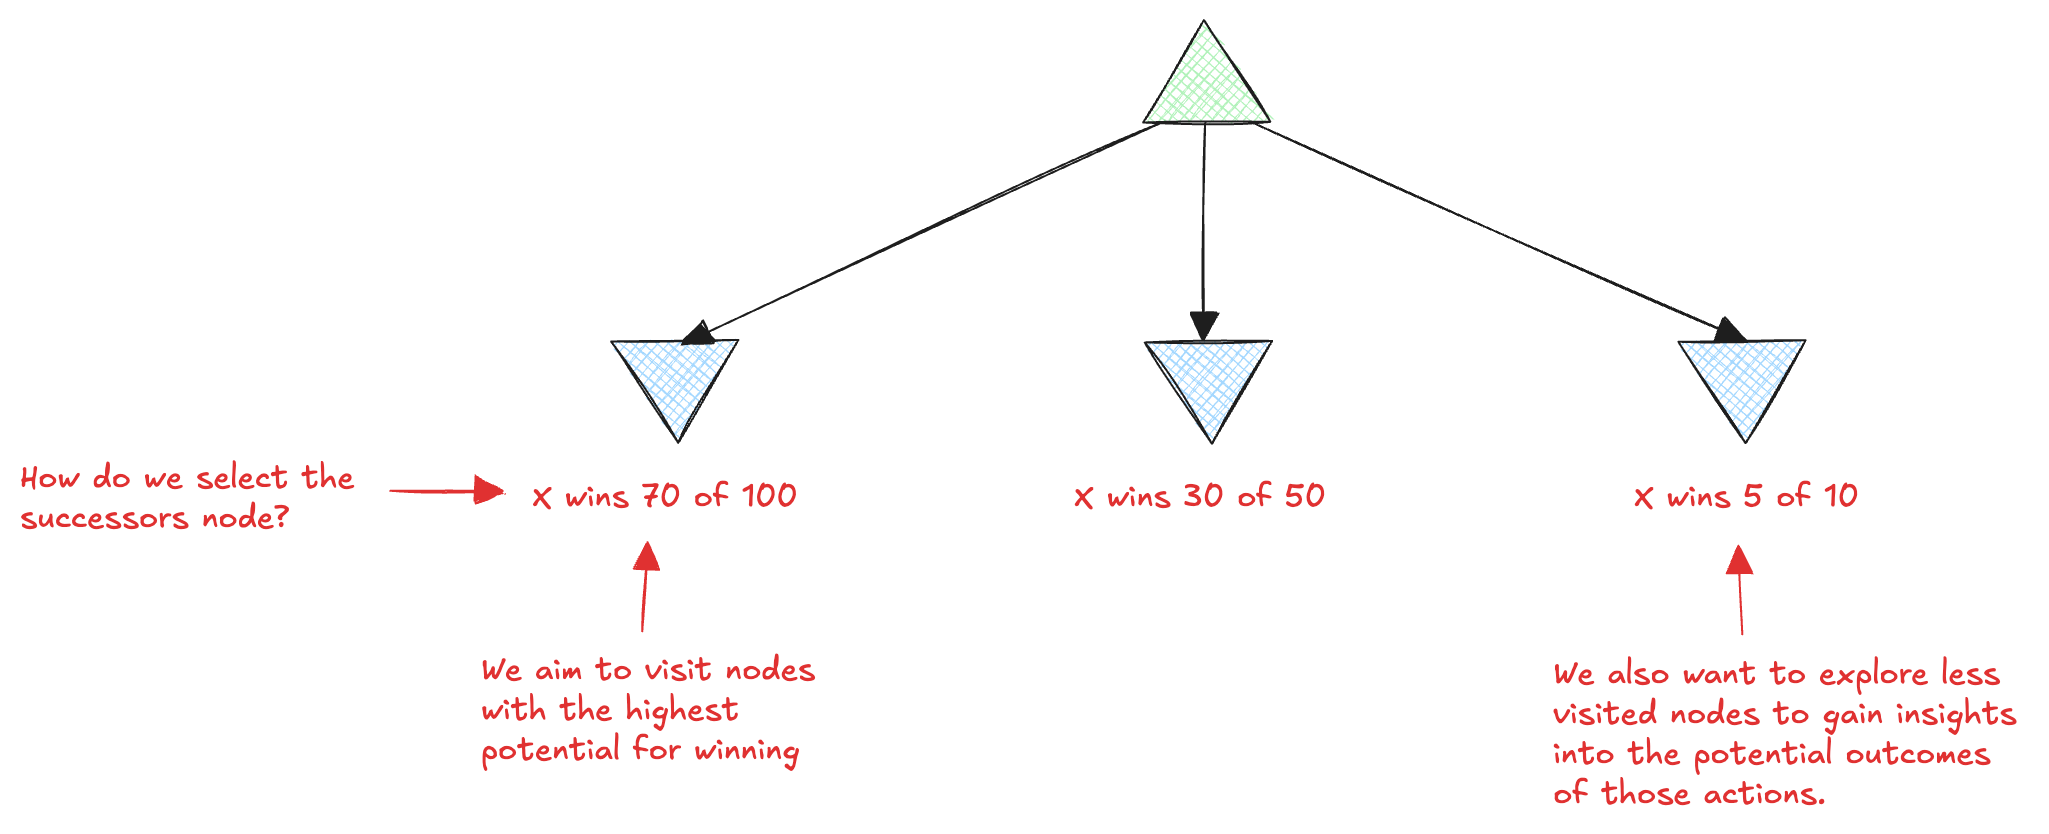

For an agent in an **uncertain environment**, where the environment is unknown, **exploration is crucial**. The agent must **learn from experience**, balancing **gathering new information** and **exploiting what it already knows**, this is konwn as the **exploration-exploitation dilemma**. For instance, should we order our favorite dish again or try something new? We need to decide **when to seek new knowledge** and **when to use past experience**. To explore this problem, we can use a  simplified, one-shot setting: the **k-armed bandit problem**.

### The k-armed bandit

The **k-armed bandit** problem models an agent choosing among **k actions**, each yielding a reward from a **stationary probability distribution**:

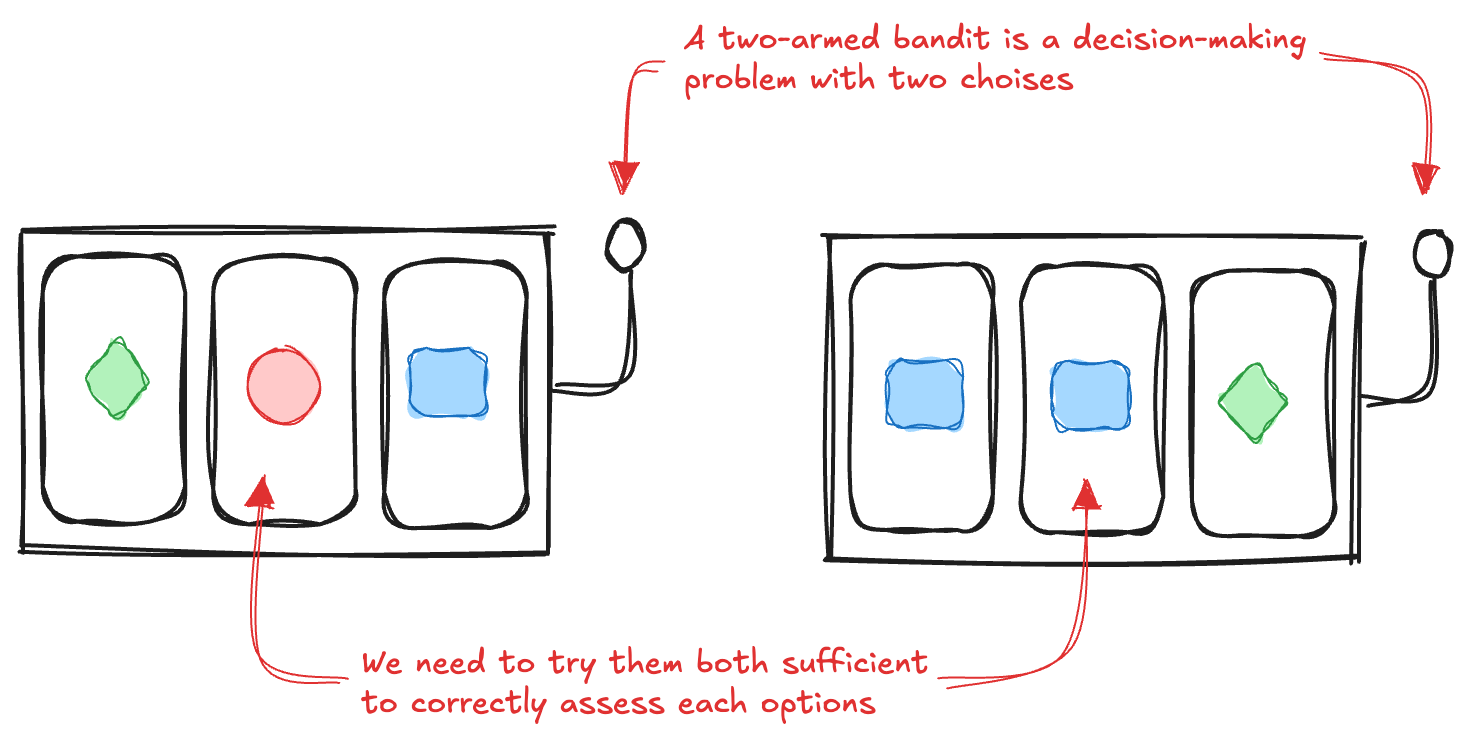

The goal is to **maximize the cumulative rewarda G** over time. This is a **"many-options, single-choice"** problem, akin to a slot machine. Formally, at time $t$, the agent selects action $a_t$, receives reward $R_t$, and aims to maximize:  

$\displaystyle G = \sum_{t=1}^{T} R_t$

The agent must estimate the **expected reward** for each action, known as the **action-value function**.

$Q^*(a)= E[R_t|A_t=a]$

We simulate a 10-armed bandit problem where each action's true value follows a normal distribution (mean = 0, variance = 1). Rewards are then drawn from a normal distribution centered at the action's value with unit variance.

In [233]:
import numpy as np

class BanditEnv:
    def __init__(self, size=10, true_Q=None):
        self.size = size                   
        if true_Q is None:
            self.means = np.random.randn(self.size)
        else:
            self.means = true_Q  
    def step(self, action):
        return np.random.normal(self.means[action])

We can visualizes the reward distributions for the 10-armed bandit problem using a violin plot:

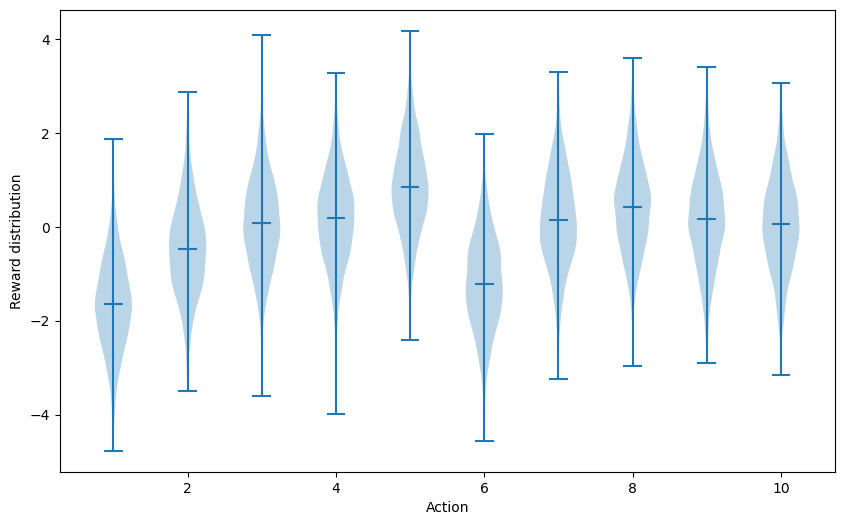

In [234]:
import matplotlib.pyplot as plt

# Create a BanditEnv instance
env = BanditEnv()

# Generates 2000 samples for each of the 10 actions, 
# assuming rewards follow a normal distribution centered around
dist = np.random.randn(2000, 10) + env.means

# Plot the reward distribution for each action
plt.figure(figsize=(10,6))
plt.violinplot(dist, showmeans=True)
plt.xlabel("Action")
plt.ylabel("Reward distribution")
plt.show()

### Estimation of the action value

Estimating the action-value function is simple: it is the average reward obtained from selecting an action. Specifically, the action value estimate is the total reward from the action divided by the number of times it has been selected:

$\displaystyle Q_t(a) = \frac{\sum\limits_{i=1}^{t-1}{R_i\cdot 1_{A_i=a}} }{\sum\limits_{i=1}^{t-1}{1_{A_i=a}} }$

A straightforward implementation would involve recording all rewards and computing the average when needed. However, this approach grows in memory and computational cost as more rewards are observed. Instead, we can use an **incremental formula** to update averages with minimal computation for each new reward. For simplicity of mathematical notation, we'll focus on a single action:

$\displaystyle Q_{t+1}=\frac{R_1+R_2+...+R_t}{t}=\frac{1}{t}\sum\limits_{i=1}^{t}{R_i} = \frac{1}{t}\left(R_t+\sum\limits_{i=1}^{t-1}{R_i}\right)=\frac{1}{t}\left(R_t+(t-1)\frac{1}{t-1}\sum\limits_{i=1}^{t-1}{R_i}\right)=$

$\displaystyle = \frac{1}{t}\left(R_t+(t-1)q_t\right)=\frac{1}{t}\left(R_t+tq_t-q_t\right)= Q_t+\frac{1}{t}(R_t-Q_t)$

This implementation requires memory only for $Q_t$ and t, and only a small computation for each new reward. This update is of a form of the general rule:

**NewEstimate <-- OldEstimate + StepSize (Target - OldEstimate)**

"Target−OldEstimate" represents the error in the estimate, which is reduced by taking a step toward the "Target," assumed to indicate a desirable direction, though it may be noisy. In this case, the target is the reward, and the step-size parameter is 1/t for action a at time t. This averaging method works well for **stationary** bandit problems, where reward probabilities remain constant. However, for **non-stationary** problems, it's useful to give more weight to recent rewards. A common approach is to use a constant step-size parameter.

$\displaystyle Q_{t+1}=Q_t+\alpha(R_t-Q_t)$

where the step-size parameter $\alpha \in (0, 1]$ is constant. This results in $Q_t$ being a weighted average of past rewards and the initial estimate $Q_1$:

$\displaystyle Q_{t+1}=Q_t+\alpha(R_t-Q_t)=\alpha R_t + (1-\alpha)Q_t =$

$\displaystyle =\alpha R_t + (1-\alpha)(\alpha R_{t-1}+(1-\alpha)Q_{t-1})=$

$\displaystyle =\alpha R_t + (1-\alpha)\alpha R_{t-1}+(1-\alpha)^2 Q_{t-1}=$

$\displaystyle =\alpha R_t + (1-\alpha)\alpha R_{t-1}+(1-\alpha)^2\alpha R_{t-2} + ... + (1-\alpha)^{t-1} \alpha R_1 + (1-\alpha)^t Q_1$

$\displaystyle =(1-\alpha)^t Q_1 + \sum\limits_{i=1}^{t}{\alpha(1-\alpha)^{t-1}R_i}$

Sometimes it is convenient to vary the step-size parameter from step to step. Let $\alpha_t(a)$ denote the step-size parameter used to process the reward received after the t selection of action a. In that case the weighting on each prior reward is:

$\displaystyle Q_{t+1} = Q_n + \alpha_n(R_t - Q_t)=\alpha_t R_t + (1-\alpha_t)Q_t =$

$\displaystyle =\alpha_t R_t + (1-\alpha_t)(\alpha_{t-1} R_{t-1}+(1-\alpha_{t-1})Q_{t-1})=$

$\displaystyle =\alpha_t R_t + (1-\alpha_t)\alpha_{t-1} R_{t-1}+(1-\alpha_t)(1-\alpha_{t-1})Q_{t-1}=$

$\displaystyle =\alpha_t R_t + (1-\alpha_t)\alpha_{t-1} R_{t-1}+(1-\alpha_t)(1-\alpha_{t-1})\alpha_{t-2} R_{t-2} + ... + (1-\alpha_t)(1-\alpha_{t-1})...(1-\alpha_1)Q_1=$

$\displaystyle =\prod\limits_{i=1}^{t}{(1-\alpha_i)}Q_1+\sum\limits_{i=1}^{t}{\alpha_i\prod\limits_{j=i+1}^{t}{(1-\alpha_j)R_i} }$

The choice $\alpha_t(a)=1/n$ results in the sample-average method, which is guaranteed to converge to the true action values by the law of large numbers. But of course convergence is not guaranteed for all choices of $\alpha_t(a)$. A result in stochastic approximation theory gives us the **conditions required to assure convergence**:

$\displaystyle
\sum\limits_{t=1}^{\infty }{\alpha_t(a)}=\infty \hspace{30 pt} \sum\limits_{t=1}^{\infty }{\alpha_t^2(a)}<\infty $

The first condition is required to guarantee that the **steps are large enough** to eventually overcome any initial conditions or random fluctuations. The second condition guarantees that eventually the **steps become small enough** to assure convergence. Note that both convergence conditions are met for the sample-average case,  but not for the case of constant step-size parameter. In the latter case, the second condition is not met, indicating that the estimates never completely converge, but continue to vary in response to the most recently received rewards. **This is actually desirable in a non-stationary environment**. All the methods we have discussed so far are biased (dependent to some extent) by their initial estimates. For the sample-average methods, the bias disappears once all actions have been selected at least once, but for methods with constant $\alpha$, the bias is permanent, though decreasing over time. In practice, this kind of bias is usually not a problem and can sometimes be very helpful to supply some **prior knowledge** about what level of rewards can be expected. 

Which action should we select based on current estimates? Should we opt for the best (greedy) choice, select randomly, or mix the two? The key challenge is finding the right balance between exploration and exploitation.

### Basic exploration strategies

At each time step, there is at least one action with the highest estimated value, known as the **greedy action**. Choosing this action means we are **exploiting our current knowledge** of the action values. If multiple actions are greedy, one is selected arbitrarily, often randomly:

$\displaystyle A_t=\underset{a}{\text{argmax }}Q_t(a)$

Greedy action selection **exploits** current knowledge to maximize immediate reward, without considering potentially better actions. Selecting a non-greedy action means **exploring**, which improves estimates of other actions' values. **Exploitation** maximizes immediate reward, but **exploration** may yield greater long-term benefits. The challenge in reinforcement learning is balancing these two, often referred to as the **exploration-exploitation conflict**. If only one episode remains, greedily maximizing reward is optimal (like doing what you enjoy most if you only have one day to live). However, with more time, trading immediate satisfaction for information can lead to better long-term outcomes. While exploiting is straightforward, **exploration** is more complex. It involves gathering information in various ways: supporting current beliefs, testing them, or exploring based on confidence or uncertainty. The **greedy strategy** (always exploit) and the **pure random strategy** (always explore) are baselines, not true strategies:

In [235]:
def pure_exploitation(env, n_episodes=1000):
    
    # Initialize the estimated Q values and the counts
    # for each action to zero
    Q = np.zeros((env.size), dtype=float)
    N = np.zeros((env.size), dtype=int)

    # Keep track of the reward obtained at each step
    rewards = np.zeros(n_episodes)

    # Here we enter the main loop and interact with the environment
    for e in range(n_episodes):
        
        # Select the action that maximizes the estimated Q-values
        action = np.argmax(Q)

        # Pass it to the environment and receive a new reward
        reward = env.step(action)

        # Store the reward
        rewards[e] = reward
        
        # Update the counts and the Q values
        N[action] += 1
        Q[action] = Q[action] + (reward - Q[action])/N[action]
        
    return Q, rewards

In [236]:
def pure_exploration(env, n_episodes=1000):
    
    Q = np.zeros((env.size), dtype=float)
    N = np.zeros((env.size), dtype=int)
    rewards = np.zeros(n_episodes)
  
    for e in range(n_episodes):
        
        # Always selects an action randomly
        action = np.random.randint(len(Q))
        
        reward = env.step(action)
        rewards[e] = reward
        
        N[action] += 1
        Q[action] = Q[action] + (reward - Q[action])/N[action]
        
    return Q, rewards

### Epsilon greedy

The **epsilon-greedy strategy** combines pure exploitation and exploration, allowing the agent to exploit most of the time while occasionally exploring randomly to gather information for better decisions:

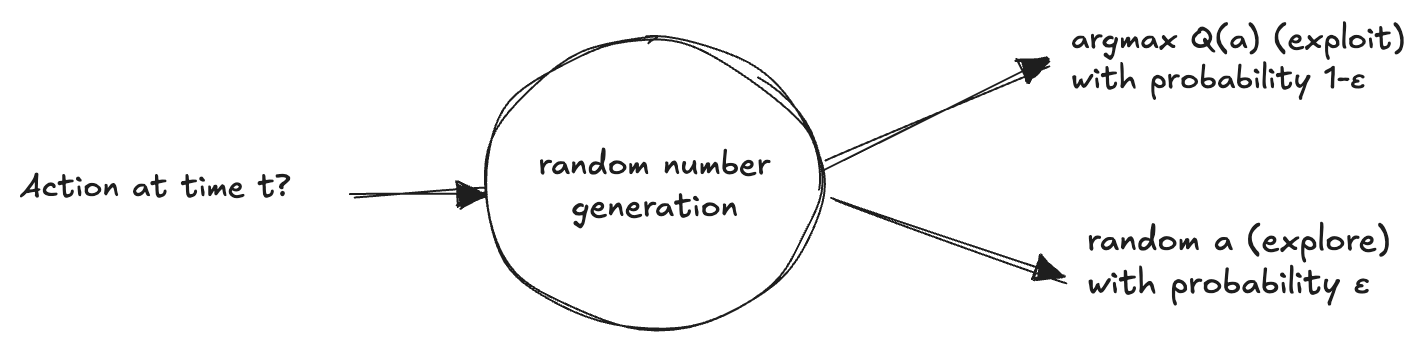

In [237]:
def epsilon_greedy(env, epsilon=0.01, n_episodes=1000):
    
    Q = np.zeros((env.size), dtype=float)
    N = np.zeros((env.size), dtype=int)
    rewards = np.zeros(n_episodes)
    
    for e in range(n_episodes):
        
        # Draw a random number and compare to the 
        # hyperparameter epsilon
        if np.random.uniform() > epsilon:
            # If it is greater than epsilon, exploit:
            action = np.argmax(Q)
        else:
            # otherwise, explore:
            action = np.random.randint(len(Q))

        reward = env.step(action)
        rewards[e] = reward
        
        N[action] += 1
        Q[action] = Q[action] + (reward - Q[action])/N[action]
        
    return Q, rewards

We can plot action values in order to check if they are estimated correctly:

In [238]:
# Create a BanditEnv instance
env = BanditEnv()

# Run epsilon-greedy with epsilon=0.5   
Q, _ = epsilon_greedy(env=env, epsilon=0.5, n_episodes=10000)

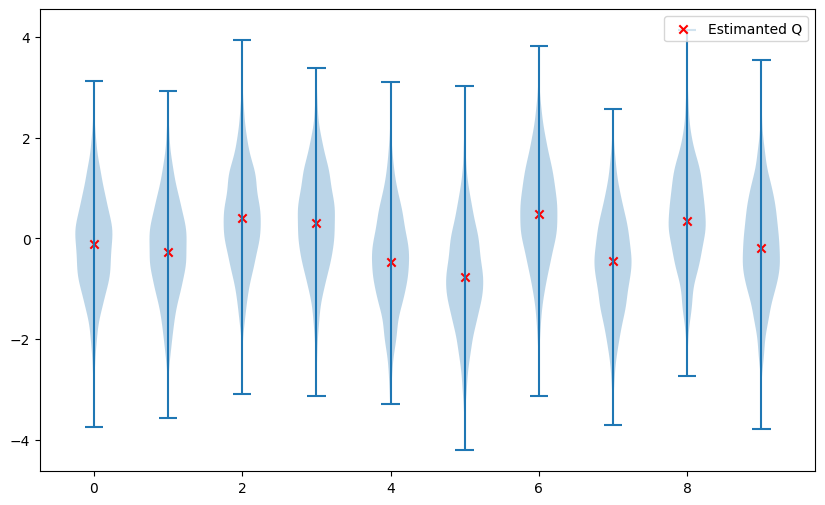

In [239]:
plt.figure(figsize=(10,6))
plt.violinplot(np.random.randn(2000, 10) + env.means, positions=range(env.size))
plt.scatter(range(env.size), Q, color='red', marker='x', label='Estimanted Q')
plt.legend();

To evaluate selection strategies, we can plot the reward that we obtains at each time step. To reduce noise and ensure reliable performance estimates, we average the reward at each step over **several independent runs**, each with a different bandit problem. This prevents bias from any single environment instance:

In [249]:
def exploration_experiment(strategy, env_size=10, n_episodes=1000, n_runs=2000, **kwargs):
    
    # Store rewards for each run
    rewards = np.zeros((n_runs, n_episodes))  
    
    # Run the experiment for each run
    for run in range(n_runs):

        # Create a new bandit problem for each run
        env = BanditEnv(env_size)  

        # Run the strategy and store the cumulative reward
        _, rewards[run] = strategy(env, n_episodes=n_episodes, **kwargs)

    # Average over all runs
    mean_return = np.mean(rewards, axis=0) 

    return mean_return

We can plot the average reward over time for the each strategy:

In [255]:
def plot_results(rewards, labels, colors, n_episodes):
    plt.figure(figsize=(10, 6))
    
    for reward, label, color in zip(rewards, labels, colors):
        plt.plot(reward, label=label, color=color)
        
    plt.xlabel('Episodes')
    plt.ylabel('Average reward')
    plt.title('Comparison of selection strategies')
    plt.legend()
    plt.show()

We can run the experiment to compare the three strategies:

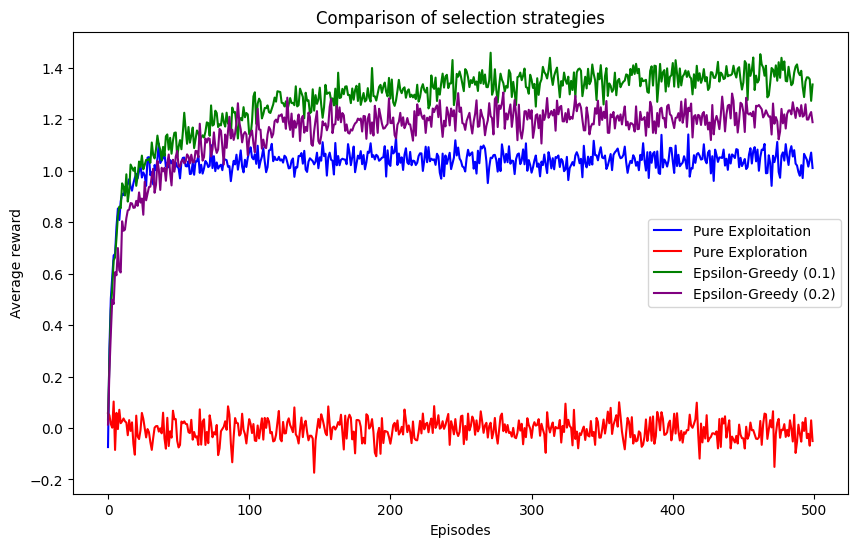

In [259]:
# Experiment parameters
n_episodes = 500
n_runs = 1000
env_size = 10

# Run experiments
mean_rewards_exploit = exploration_experiment(pure_exploitation, env_size, n_episodes, n_runs)
mean_rewards_explore = exploration_experiment(pure_exploration, env_size, n_episodes, n_runs)
mean_rewards_epsilon_01 = exploration_experiment(epsilon_greedy, env_size, n_episodes, n_runs, epsilon=0.1)
mean_rewards_epsilon_02 = exploration_experiment(epsilon_greedy, env_size, n_episodes, n_runs, epsilon=0.2)

# Plot results
plot_results(
    rewards=[mean_rewards_exploit, mean_rewards_explore, mean_rewards_epsilon_01, mean_rewards_epsilon_02],
    labels=["Pure Exploitation", "Pure Exploration", "Epsilon-Greedy (0.1)", "Epsilon-Greedy (0.2)"],
    colors=['blue', 'red', 'green', 'purple'],
    n_episodes=n_episodes
)

The pure exploitation method improved **faster initially** but performed **worse long-term**, getting stuck in suboptimal actions. The greedy method **performed better** by continuing to explore and refining its choice of the optimal action. With epsilon=0.2, it explored more and **found the optimal action earlier**, but never selected it more than 80% of the time. With epsilon=0.1, it **improved more slowly** but performed better in the long run by limiting exploration to 10%. Gradually **reducing epsilon over time** can balance early exploration with long-term exploitation.

### Decaying epsilon-greedy

Initially, **high exploration is needed** when the agent lacks experience, while **later, exploitation increases** as value estimates improve. The decaying method starts with a high epsilon value and gradually reduces it at each step, either **linearly or exponentially**. Precomputing epsilon values allows efficient lookup during execution. Below is an exponential implementation:

In [260]:
def decay_epsilon(init_value, min_value, decay_episodes, max_episodes):

    # calculate the number of the remaining episodes after the decay
    rem_episodes = max_episodes - decay_episodes
    
    # logspace returns numbers spaced evenly on a log scale
    # base^start is the starting value of the sequence,
    # base^stop is the final value of the sequence
    # num is the number of values to generate
    # base is the base of the log space
    values = np.logspace(start=0, stop=-2, num=decay_episodes, base=10)
    
    # because the values may not end exactly at 0, given it’s the log, 
    # we change them to be between 0 and 1 so that the curve looks smooth and nice.
    values = (values - values.min()) / (values.max() - values.min())
    
    # linear transformation and get points between init_value and min_value
    values = (init_value - min_value) * values + min_value
    
    # repeats the rightmost value rem_step number of times
    values = np.pad(values, (0, rem_episodes), 'edge')
    
    return values

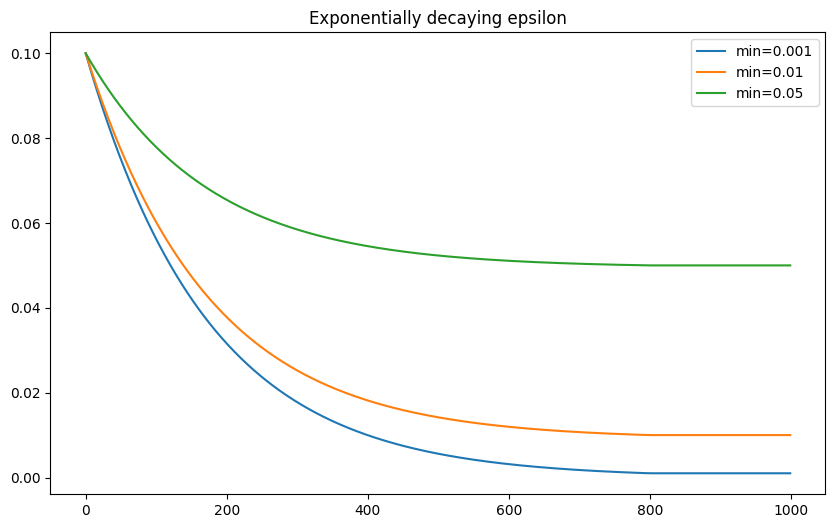

In [261]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(decay_epsilon(0.1, 0.001, 800, 1000), label='min=0.001')
plt.plot(decay_epsilon(0.1, 0.01, 800, 1000), label='min=0.01')
plt.plot(decay_epsilon(0.1, 0.05, 800, 1000), label='min=0.05')
plt.title('Exponentially decaying epsilon')
plt.legend()
plt.show()

In [271]:
def decay_epsilon_greedy(env, init_epsilon=1, min_epsilon=0.001, decay_episodes=100, n_episodes=1000):

    Q = np.zeros((env.size), dtype=float)
    N = np.zeros((env.size), dtype=int)
    rewards = np.zeros(n_episodes)
    
    # Calculate the exponentially decaying epsilons. 
    epsilons = decay_epsilon(init_epsilon, min_epsilon, decay_episodes, n_episodes);
    
    for e in range(n_episodes):
        
        # Use the epsilon value for this episode
        if np.random.uniform() > epsilons[e]:
            action = np.argmax(Q)
        else:
            action = np.random.randint(len(Q))

        reward = env.step(action)
        rewards[e] = reward
        
        N[action] += 1
        Q[action] = Q[action] + (reward - Q[action])/N[action]

    return Q, rewards

We can run the experiment with the decaying epsilon-greedy strategy:

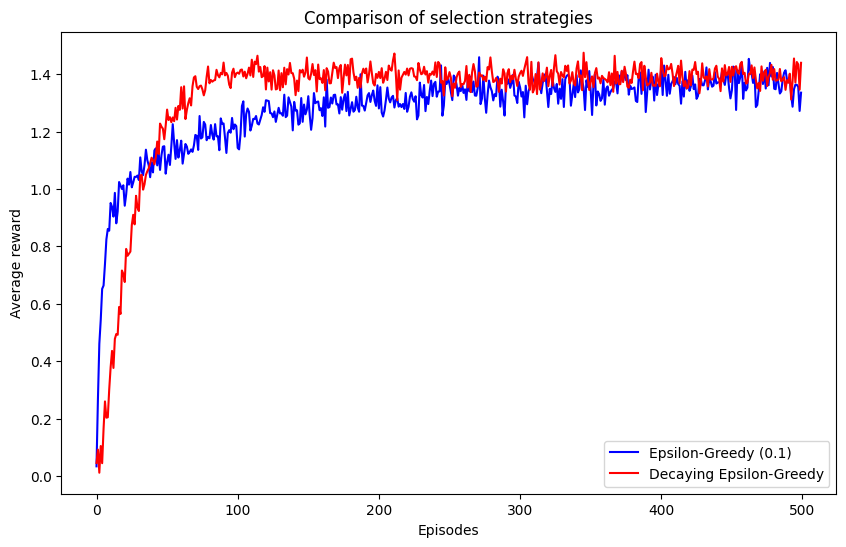

In [272]:
mean_rewards_epsilon_decay = exploration_experiment(decay_epsilon_greedy, env_size, n_episodes, n_runs)

# Plot results
plot_results(
    rewards=[mean_rewards_epsilon_01, mean_rewards_epsilon_decay],
    labels=["Epsilon-Greedy (0.1)", "Decaying Epsilon-Greedy"],
    colors=['blue', 'red'],
    n_episodes=n_episodes
)

The decaying epsilon approach quickly identifies optimal actions and stabilizes at a higher average reward, as shown in the graph. Its reward curve is smoother and consistently exceeds that of fixed epsilon strategies, demonstrating a better balance between exploration and exploitation. Various methods exist for decaying epsilon, but the key idea is that **the agent should explore more early on and exploit more as it gains knowledge**. Initially, value estimates are uncertain, but over time, as the agent learns, the estimates become more accurate, and the agent should shift towards exploitation.

### Optimistic initial values

Initial action values can **encourage exploration** by setting optimistic estimates. When actions are selected based on these high initial values, the rewards will be lower than expected, leading the agent to explore other actions, thus creating a sense of **"disappointment"**. This ensures that **all actions are tried multiple times** before value estimates converge. Even with greedy action selection, the system explores sufficiently. This technique is called **optimistic initial values**, where the action-value function is initialized to a high value, and the agent acts greedily based on these estimates:

In [ ]:
def optimistic_initialization(env, optimistic_estimate=5.0, initial_count=10, n_episodes=1000):
    
    # Start initializing the action-values to an optimistic value
    Q = np.full((env.size), optimistic_estimate, dtype=float)
    N = np.zeros((env.size), dtype=int)
    
    rewards = np.empty(n_episodes, dtype=float)
    
    for e in range(n_episodes):
        
        action = np.argmax(Q)

        reward = env.step(action)
        rewards[e] = reward

        N[action] += 1
        Q[action] = Q[action] + (reward - Q[action])/N[action]

    return Q, rewards

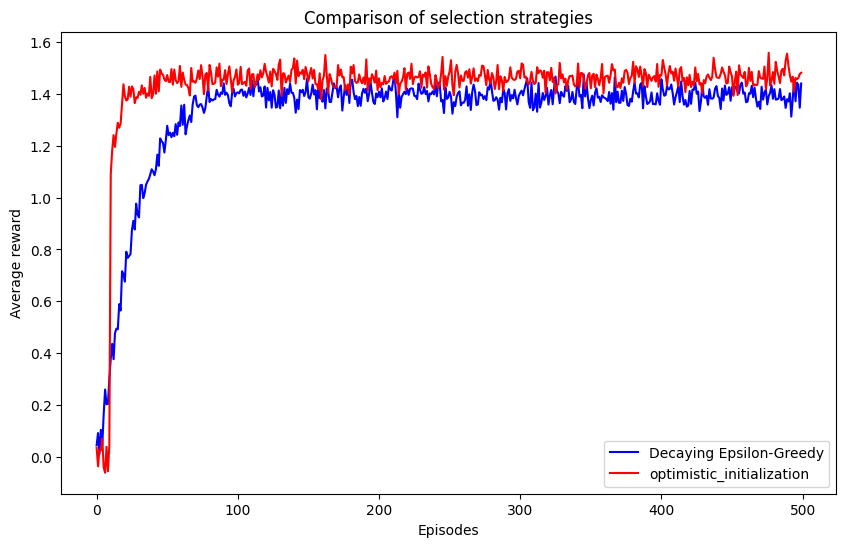

In [283]:
mean_rewards_optimistic = exploration_experiment(optimistic_initialization, env_size, n_episodes, n_runs)

# Plot results
plot_results(
    rewards=[mean_rewards_epsilon_decay, mean_rewards_optimistic],
    labels=["Decaying Epsilon-Greedy", "Optimistic Initialization"],
    colors=['blue', 'red'],
    n_episodes=n_episodes
)

The optimistic method initially performs worse due to increased exploration, causing **oscillations and spikes**. If early actions are good, their estimates inflate, biasing the agent toward them and improving initial performance. Conversely, poor early choices lead to weak initial results. This approach is a simple trick works well in **stationary problems** but struggles in **non-stationary settings** due to its temporary exploration drive. Another key challenge is that **the maximum possible reward is unknown**. If the initial estimates are set too high, the agent takes many episodes to adjust, leading to prolonged suboptimal performance. Even worse, if set too low, the method loses its optimistic effect and fails to work as intended.

### Strategic Exploration: Upper Confidence Bound

While humans explore, they don’t explore randomly, they have a **strategic way of exploring**. Perhaps, our exploration strategies are **a combination of estimates and their uncertainty** (e.g. we might prefer a dish that we’re likely to enjoy, and we haven’t tried, over a dish that we like okay, but we get every weekend), perhaps we explore **based on our curiosity or our prediction error** (e.g. we might be more inclined to try new dishes at a restaurant that we thought would be okay-tasting food, but it resulted in the best food we ever had). That **prediction error** and that **surprise** could be our metric for exploration. The **Upper Confidence Bound** method follows this intuition and uses statistical techniques to calculate the **value estimates uncertainty** and uses that as a **bonus for exploration**. It is optimistic, but in a realistic way. Instead of blindly hoping for the best, it looks at the uncertainty of value estimates: **the more uncertain an estimate, the more critical it is to explore it**:

$\displaystyle A_t=\underset{a}{\text{argmax}} ( Q_t(a) + c * u_t(a) )$ 

the first term **represents the estimated value** of the action, while the second term **accounts for uncertainty**, often influenced by factors like the number of times the action has been selected. This formula embodies the principle that decisions are made by balancing **known value** with an **exploration bonus** based on uncertainty. The parameter c is used to tune the amount of exploration. The uncertainty term can be expressed as:

$\displaystyle u_t(a) = \sqrt{\frac{\ln t}{N_t(a)} }]$ 

The idea is that each time an action is selected the uncertainty is presumably reduced (the count increments and the uncertainty term decreases). On the other hand, each time another action is selected, t increases but the count does not and the uncertainty estimate increases. The use of the logarithm means that the increases get smaller over time, but are unbounded. Composing the two contribution:

$\displaystyle A_t=\underset{a}{\text{argmax}} \left(Q_t(a)+c\sqrt{\frac{\ln t}{N_t(a)} } \right)$

All actions will eventually be selected, but actions with lower value estimates or that have already been selected frequently, will be selected with decreasing frequency over time. We can implement it in Python:

In [305]:
def upper_confidence_bound(env, c=1.5, n_episodes=1000):
    
    Q = np.zeros((env.size), dtype=float)
    N = np.zeros((env.size), dtype=int)
    rewards = np.empty(n_episodes, dtype=float)
    
    for e in range(n_episodes):
        
        # First select all actions once to avoid division by zero
        if e < len(Q):
            action = e

        else: 
            # Calculatie the confidence bounds
            U = np.sqrt(c * np.log(e)/N)

            # Pick the action with the highest value with an 
            # uncertainty bonus
            action = np.argmax(Q + U)

        reward = env.step(action)
        rewards[e] = reward
        
        N[action] += 1
        Q[action] = Q[action] + (reward - Q[action])/N[action]
        
    return Q, rewards

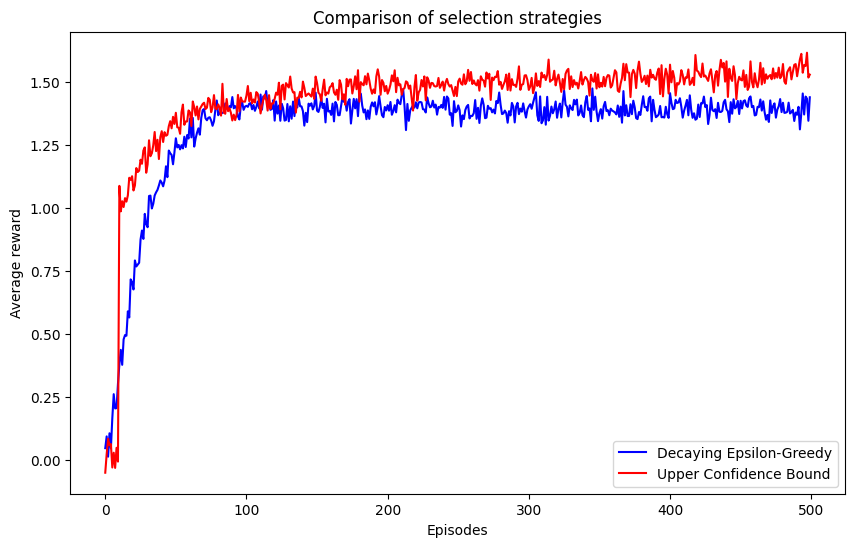

In [306]:
mean_rewards_ucb = exploration_experiment(upper_confidence_bound, env_size, n_episodes, n_runs)

# Plot results
plot_results(
    rewards=[mean_rewards_epsilon_decay, mean_rewards_ucb],
    labels=["Decaying Epsilon-Greedy", "Upper Confidence Bound"],
    colors=['blue', 'red'],
    n_episodes=n_episodes
)

UCB often performs well, but it is more complex and require more tuning than epsilon-greedy and it is difficult to extend beyond bandits to the more general problems. We can apply this method to MCTS, the value for a node n cam be expressed as:

$\displaystyle \text{UCB}(n) = \frac{U(n)}{N(n)} + c \sqrt{\frac{\log N(PARENT(n))}{N(n)}}$

Here, U is the total utility of all playouts through a node, and N is the number of playouts. The **exploitation term** represents the node's average utility, while the **exploration term** is high for rarely visited nodes. The numerator includes the logarithm of the parent node's visit count, ensuring that as a node is selected more frequently, its exploration bonus decreases.

In [308]:
def ucb_selection_function(parent, child, c=1.41):
    # Encourage exploration of unvisited nodes
    if child.visits == 0:
        return float('inf')  

    # Average reward    
    exploitation = child.wins / child.visits

    # UCB term  
    exploration = c * math.sqrt(math.log(parent.visits) / child.visits)

    return exploitation + exploration

## Limitations of Game Search Algorithms

While aversarial search algorithms have greatly advanced the development of agents, they come with inherent limitations that can affect performance and scalability. These limitations arise from the complexity of decision-making processes, the computational resources required, and the challenges associated with generalizing strategies across different games. 

The first approach, based on **expert knowledge**, relies on manually defined rules and strategies developed by experts in the field. Although this method is efficient in terms of computation, it requires a high level of proficiency and fails to generalize across different game scenarios. As the game complexity increases, so too does the difficulty in manually defining all the possible strategies, leading to potential gaps in the AI's decision-making ability.

The second method, based on **strategic knowledge**, takes a more dynamic approach by predicting potential future actions and evaluating outcomes, as seen with the **minimax algorithm**. While this provides a systematic and optimal decision-making framework, it suffers from computational inefficiencies due to the vast number of potential moves, making it impractical for more complex games without additional optimizations like **alpha-beta pruning** or **heuristic evaluation functions**, which has also the drawbacks of requiring domain knowledge.

The third option, based on **simulation**, employs **Monte Carlo Tree Search (MCTS)** to incrementally simulate game outcomes and select the best possible move based on statistical data. While MCTS allows for greater flexibility and doesn't require predefined evaluation functions, it is computationally expensive and the quality of its decisions can be inconsistent, particularly in games with large state spaces and deep strategies.

We can have another possibility, wich is **learning** from the simulation how to evaluate states. This solution leverages **machine learning** and **reinforcement learning** and **self-play** to allow the agent to learn how to evaluate game states. The [**Alpha-zero**](./papers/(2017)%20%20-%20Mastering%20the%20game%20of%20Go%20without%20human%20knowledge.pdf) algorithm learns from scratch by self-play, uses the board as input features to
a neural network that should learn how to evaluate positions. This approach eliminates the need for exhaustive simulations after training, making decisions more efficient. However, it still requires extensive training data and computational power, and while it offers a sophisticated model for evaluating game states, it is not entirely free from limitations in its learning process.